# E1 Clean Analysis Notebook

## 1. Experiment Description

E1 evaluates candidate wires under four evaluation configs and two friction settings. The main goal is to understand how strongly the wire ranking depends on start randomness, policy stochasticity, and trial budget.

Core experiment settings:

- anatomies: `12`
- targets per anatomy: `3`
- configs: `4`
- max episode steps: `1000`
- friction datasets analyzed here:
  - `0.001`: merged result tree
  - `0.1`: real-friction result tree

Config definitions from the experiment code:

- `Cfg 1`: deterministic policy, fixed start, `1` trial
- `Cfg 2`: deterministic policy, random start, `1000` trials
- `Cfg 3`: stochastic policy, fixed start, `1000` trials
- `Cfg 4`: stochastic policy, random start, `1000` trials

That means the full planned E1 grid contains:

- anatomy-target-config jobs: `12 x 3 x 4 = 144`
- planned trials across all jobs: `12 x 3 x (1 + 1000 + 1000 + 1000) = 108036`

Relevant experiment code:

- helper definitions: [experiments/master-thesis/notebook_helpers/e1.py](../experiments/master-thesis/notebook_helpers/e1.py)
- robust result loading and analysis helpers: [experiments/master-thesis/notebook_helpers/e1_analysis.py](../experiments/master-thesis/notebook_helpers/e1_analysis.py)
- anatomy sampling script: [scripts/sample_e1_anatomies.py](../scripts/sample_e1_anatomies.py)
- job generation / validation: [scripts/e1_generate_validate.py](../scripts/e1_generate_validate.py)
- per-job runner: [experiments/master-thesis/run_e1_cell.py](../experiments/master-thesis/run_e1_cell.py)


In [1]:
from pathlib import Path
from typing import Optional
import importlib
import json
import sys

import pandas as pd
from IPython.display import Markdown, display


def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1.py"
        if helper.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")


PROJECT_ROOT = find_project_root()
HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for path in (PROJECT_ROOT, HELPER_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import e1 as e1_module
import e1_analysis as e1_analysis_module
importlib.reload(e1_module)
importlib.reload(e1_analysis_module)

from e1 import CONFIGS, DEFAULT_TARGET_BRANCHES, load_sample_anatomies, sample_target_specs
from e1_analysis import iqm, load_e1_result_rows
from steve_recommender.eval_v2.experimental_prep_scripts.sample_anatomies import sample_anatomies_from_registry
from steve_recommender.eval_v2.service import DefaultEvaluationService

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"HELPER_DIR={HELPER_DIR}")
print(f"pandas={pd.__version__}")


PROJECT_ROOT=/home/hannes-deittert/dev/Uni/master-project
HELPER_DIR=/home/hannes-deittert/dev/Uni/master-project/experiments/master-thesis/notebook_helpers
pandas=2.0.3


## 2. Generation of the Anatomy Set

This reproduces the E1 anatomy sample cleanly in the notebook and writes the canonical input JSON to `results/experimental_prep/sample_12_e1.json`.

Sampling settings:

- sample size: `12`
- seed: `123`
- strata: `none`
- sampling method: `random`
- branch filter: `bct,lcca,lsa`
- workers: `4`


In [2]:
E1_SAMPLE_JSON = PROJECT_ROOT / "results" / "experimental_prep" / "sample_12_e1.json"
POOL = PROJECT_ROOT / "data" / "anatomy_registry"
POOL_INDEX = POOL / "index.json"

sample_payload = sample_anatomies_from_registry(
    pool_path=POOL,
    n=12,
    seed=123,
    strata="none",
    sampling_method="random",
    branches=("bct", "lcca", "lsa"),
    workers=4,
)

E1_SAMPLE_JSON.parent.mkdir(parents=True, exist_ok=True)
E1_SAMPLE_JSON.write_text(json.dumps(sample_payload, indent=2, sort_keys=True) + "\n", encoding="utf-8")

service = DefaultEvaluationService()
anatomy_rows = []
for item in sample_payload["selected_anatomies"]:
    anatomy = service.get_anatomy(record_id=item["record_id"], registry_path=POOL_INDEX)
    branches = service.list_branches(anatomy)
    anatomy_rows.append(
        {
            "record_id": item["record_id"],
            "arch_type": item.get("arch_type"),
            "seed": item.get("seed"),
            "tortuosity": item.get("tortuosity"),
            "available_branches": ", ".join(branch.name for branch in branches),
        }
    )

anatomy_df = pd.DataFrame(anatomy_rows).sort_values("record_id").reset_index(drop=True)
display(Markdown(f"Wrote sample file: `{E1_SAMPLE_JSON}`"))
display(anatomy_df)

target_payload = sample_target_specs(
    sample_json=E1_SAMPLE_JSON,
    target_seed_start=9000,
    target_count_per_anatomy=3,
    target_branches=DEFAULT_TARGET_BRANCHES,
)
target_rows = []
for anatomy in target_payload["selected_anatomies"]:
    for target in anatomy["targets"]:
        target_rows.append(
            {
                "record_id": anatomy["record_id"],
                "target_index": target["target_index"],
                "target_seed": target["target_seed"],
                "selected_branch_hint": target["selected_branch_hint"],
            }
        )
target_rows_df = pd.DataFrame(target_rows).sort_values(["record_id", "target_index"]).reset_index(drop=True)
display(Markdown("### Derived target specification preview"))
display(target_rows_df.head(12))


KeyboardInterrupt: 

## 2.1 E1 Anatomy Mesh Screenshots

Mesh-only screenshots for the sampled E1 anatomies are stored without target overlays in `results/master_thesis/e1_anatomy_mesh_screenshots/`.


E1 mesh screenshots: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_anatomy_mesh_screenshots`

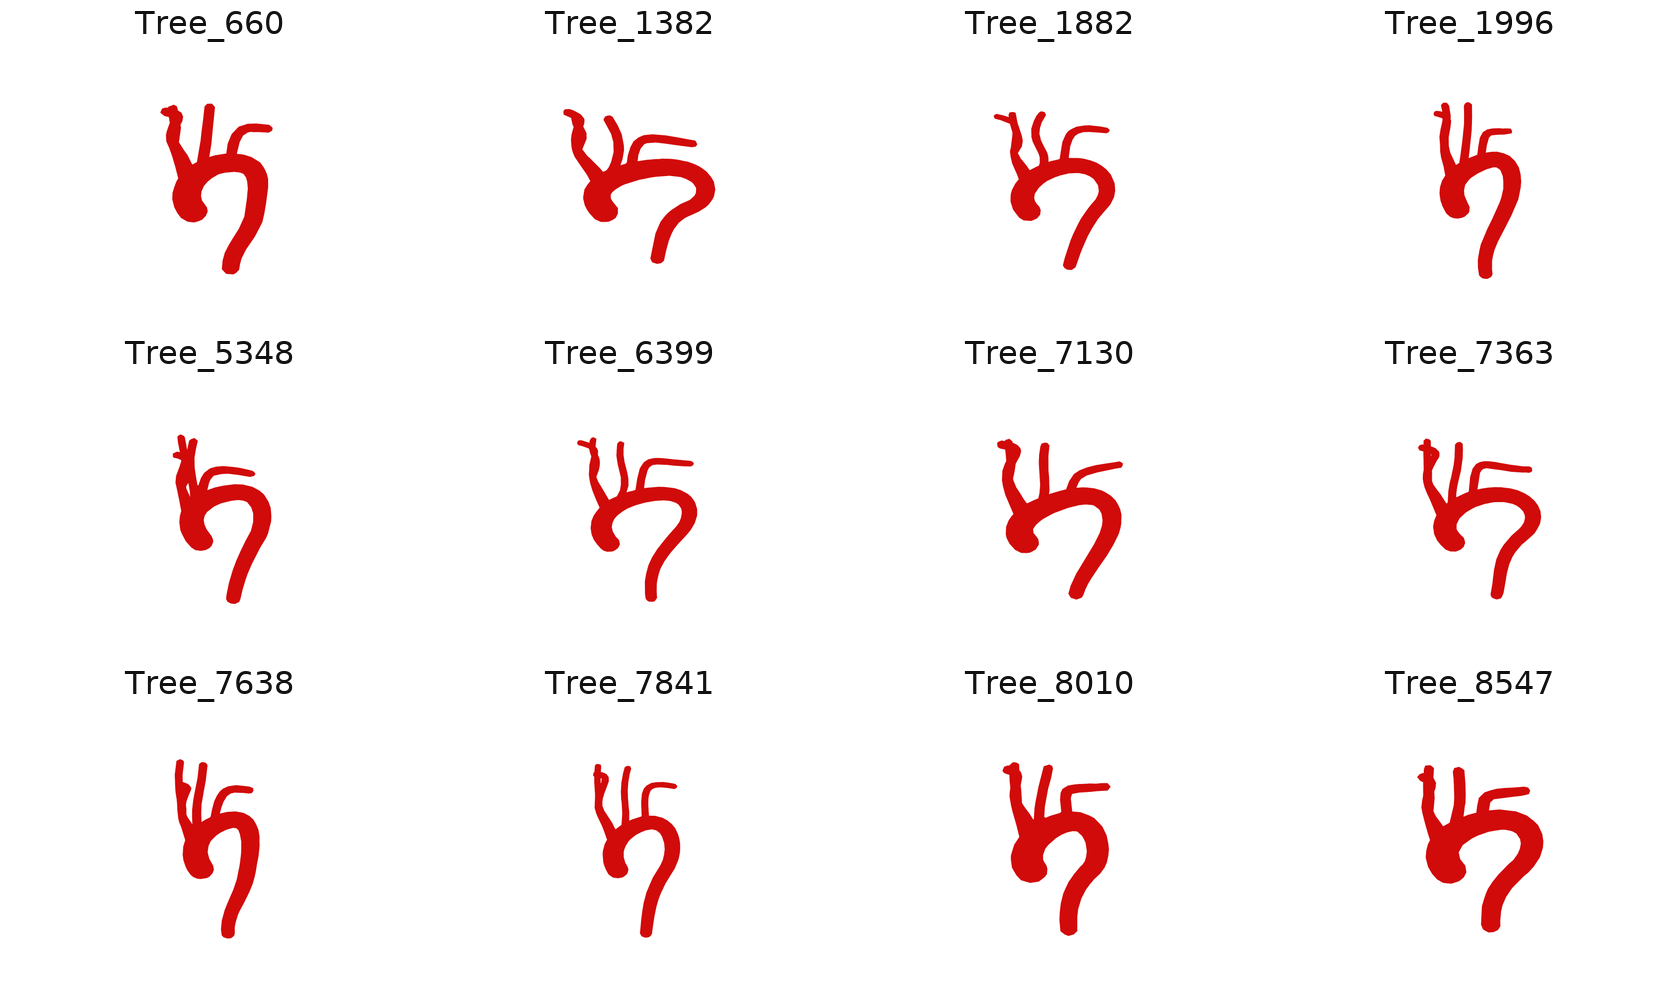

In [4]:
import json
import math

from IPython.display import Image
from PIL import Image as PILImage, ImageDraw, ImageFont

E1_MESH_SCREENSHOT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e1_anatomy_mesh_screenshots"
E1_MESH_CONTACT_SHEET = E1_MESH_SCREENSHOT_DIR / "contact_sheet.png"

def rebuild_e1_mesh_contact_sheet(
    screenshot_dir,
    output_path,
    *,
    columns=4,
    tile_size=(420, 330),
    source_title_crop_px=120,
    label_height=48,
    label_font_size=32,
):
    index_path = screenshot_dir / "index.json"
    if index_path.exists():
        index_rows = json.loads(index_path.read_text(encoding="utf-8"))
        image_paths = [
            screenshot_dir / row["image"]
            for row in index_rows
            if (screenshot_dir / row["image"]).exists()
        ]
    else:
        image_paths = sorted(
            path for path in screenshot_dir.glob("Tree_*.png")
            if path.name != output_path.name
        )
    if not image_paths:
        return None

    rows = math.ceil(len(image_paths) / columns)
    sheet = PILImage.new("RGB", (columns * tile_size[0], rows * tile_size[1]), "white")
    draw = ImageDraw.Draw(sheet)
    try:
        font = ImageFont.truetype("DejaVuSans.ttf", label_font_size)
    except OSError:
        font = ImageFont.load_default()

    for index, image_path in enumerate(image_paths):
        row, col = divmod(index, columns)
        x0 = col * tile_size[0]
        y0 = row * tile_size[1]
        label = image_path.stem
        bbox = draw.textbbox((0, 0), label, font=font)
        draw.text(
            (x0 + (tile_size[0] - (bbox[2] - bbox[0])) / 2, y0 + 4),
            label,
            fill="#111111",
            font=font,
        )

        source = PILImage.open(image_path).convert("RGB")
        source = source.crop((0, source_title_crop_px, source.width, source.height))
        image_area = (tile_size[0], tile_size[1] - label_height)
        source.thumbnail(image_area, PILImage.Resampling.LANCZOS)
        paste_x = x0 + (tile_size[0] - source.width) // 2
        paste_y = y0 + label_height + (image_area[1] - source.height) // 2
        sheet.paste(source, (paste_x, paste_y))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    sheet.save(output_path)
    return output_path

rebuild_e1_mesh_contact_sheet(E1_MESH_SCREENSHOT_DIR, E1_MESH_CONTACT_SHEET)
display(Markdown(f"E1 mesh screenshots: `{E1_MESH_SCREENSHOT_DIR}`"))
if E1_MESH_CONTACT_SHEET.exists():
    display(Image(filename=str(E1_MESH_CONTACT_SHEET)))


## 3. Analysis Plan

The clean analysis flow in this notebook is:

1. Load both E1 result trees once.
2. Normalize them into a canonical set of DataFrames.
3. Use only those DataFrames in later analyses.

The per-config trial DataFrames built below are:

- `trial_cfg1_f0001_df`, `trial_cfg2_f0001_df`, `trial_cfg3_f0001_df`, `trial_cfg4_f0001_df` for friction `0.001`.
- `trial_cfg1_f01_df`, `trial_cfg2_f01_df`, `trial_cfg3_f01_df`, `trial_cfg4_f01_df` for friction `0.1`.
- `config_trial_dfs`: dictionary keyed by `(friction_label, config_id)` with the same tables.

This keeps later analyses simple: filter a canonical table, then summarize or plot. The notebook should not keep reloading files or rebuilding ad hoc groupings in every later section.


## 3.0 Training Data

Read the merged training histories directly from `main.log` in each canonical `merged` agent folder. The result is one event dataframe for the 15 non-force-aware trainings and one event dataframe for the 9 force-aware trainings. Rows are `training_update`, `evaluation_run`, `quality_result`, `heatup`, and `stage_start`.


In [2]:
import re
from pathlib import Path

import pandas as pd

TRAINING_ARCHIVE_ROOT = PROJECT_ROOT / "data" / "archive" / "agents"
NON_FORCE_LOG_ROOT = TRAINING_ARCHIVE_ROOT / "non_force_aware"
FORCE_AWARE_LOG_ROOT = TRAINING_ARCHIVE_ROOT / "force_aware"

LOG_TIME_RE = re.compile(r"^(?P<time>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d{3})")
STAGE_RE = re.compile(r"^===== STAGE (?P<stage>.+) =====$")
HEATUP_RE = re.compile(
    r"heatup\s*:\s*"
    r"(?P<heatup_seconds>[\d.]+)s\s*\|\s*"
    r"(?P<heatup_steps_per_s>[\d.]+)\s*steps/s\s*\|\s*"
    r"(?P<heatup_steps>\d+)\s*steps\s*/\s*(?P<heatup_episodes>\d+)\s*episodes\s*\|\s*"
    r"Total:\s*(?P<total_heatup_steps>\d+)\s*steps\s*/\s*(?P<total_heatup_episodes>\d+)\s*episodes"
)
UPDATE_RE = re.compile(
    r"update / exploration:\s*"
    r"(?P<update_seconds>[\d.]+)\s*/\s*(?P<explore_seconds>[\d.]+)\s*s\s*\|\s*"
    r"(?P<update_steps_per_s>[\d.]+)\s*/\s*(?P<explore_steps_per_s>[\d.]+)\s*steps/s\s*\|\s*"
    r"(?P<update_steps>\d+)\s*/\s*(?P<explore_steps>\d+)\s*steps,\s*(?P<episodes>\d+)\s*episodes\s*\|\s*"
    r"(?P<total_update_steps>\d+)\s*/\s*(?P<total_explore_steps>\d+)\s*steps total,\s*"
    r"(?P<total_episodes>\d+)\s*episodes total"
)
EVAL_RE = re.compile(
    r"evaluation\s*:\s*"
    r"(?P<eval_seconds>[\d.]+)s\s*\|\s*"
    r"(?P<eval_steps_per_s>[\d.]+)\s*steps/s\s*\|\s*"
    r"(?P<eval_steps>\d+)\s*steps\s*/\s*(?P<eval_episodes>\d+)\s*episodes\s*\|\s*"
    r"Total:\s*(?P<total_eval_steps>\d+)\s*steps\s*/\s*(?P<total_eval_episodes>\d+)\s*episodes"
)
QUALITY_RE = re.compile(
    r"Quality:\s*(?P<quality>[-+\deE.]+),\s*"
    r"Reward:\s*(?P<reward>[-+\deE.]+),\s*"
    r"Exploration steps:\s*(?P<exploration_steps>\d+)"
)


def parse_log_time(line):
    match = LOG_TIME_RE.match(line)
    if not match:
        return pd.NaT
    return pd.to_datetime(match.group("time"), format="%Y-%m-%d %H:%M:%S,%f")


def parse_numbers(row, keys):
    for key in keys:
        row[key] = pd.to_numeric(row[key], errors="coerce")
    return row


def iter_merged_log_dirs(root):
    return sorted(path.parent for path in root.glob("*/*/merged/main.log"))


def non_force_metadata(merged_dir):
    return {
        "training_family": "non_force_aware",
        "wire_model": merged_dir.parent.parent.name,
        "wire_variant": merged_dir.parent.name,
        "force_alpha": pd.NA,
        "merged_dir": str(merged_dir.relative_to(PROJECT_ROOT)),
    }


def force_aware_metadata(merged_dir):
    return {
        "training_family": "force_aware",
        "wire_model": merged_dir.parent.parent.name,
        "wire_variant": "standard_j",
        "force_alpha": merged_dir.parent.name,
        "merged_dir": str(merged_dir.relative_to(PROJECT_ROOT)),
    }


def parse_merged_main_log(merged_dir, metadata):
    log_path = merged_dir / "main.log"
    rows = []
    stage = pd.NA
    last_evaluation = None

    for line_number, line in enumerate(log_path.read_text(errors="replace").splitlines(), start=1):
        stage_match = STAGE_RE.match(line)
        if stage_match:
            stage = stage_match.group("stage")
            last_evaluation = None
            rows.append({
                **metadata,
                "event_type": "stage_start",
                "stage": stage,
                "source_file": str(log_path.relative_to(PROJECT_ROOT)),
                "line_number": line_number,
            })
            continue

        timestamp = parse_log_time(line)
        if pd.isna(timestamp):
            continue

        common = {
            **metadata,
            "stage": stage,
            "timestamp": timestamp,
            "source_file": str(log_path.relative_to(PROJECT_ROOT)),
            "line_number": line_number,
        }

        heatup_match = HEATUP_RE.search(line)
        if heatup_match:
            row = {**common, "event_type": "heatup", **heatup_match.groupdict()}
            rows.append(parse_numbers(row, heatup_match.groupdict().keys()))
            continue

        update_match = UPDATE_RE.search(line)
        if update_match:
            row = {**common, "event_type": "training_update", **update_match.groupdict()}
            rows.append(parse_numbers(row, update_match.groupdict().keys()))
            continue

        eval_match = EVAL_RE.search(line)
        if eval_match:
            row = {**common, "event_type": "evaluation_run", **eval_match.groupdict()}
            row = parse_numbers(row, eval_match.groupdict().keys())
            rows.append(row)
            last_evaluation = row
            continue

        quality_match = QUALITY_RE.search(line)
        if quality_match:
            row = {**common, "event_type": "quality_result", **quality_match.groupdict()}
            row = parse_numbers(row, quality_match.groupdict().keys())
            if last_evaluation and last_evaluation.get("stage") == stage:
                row["eval_seconds"] = last_evaluation.get("eval_seconds")
                row["eval_steps_per_s"] = last_evaluation.get("eval_steps_per_s")
                row["eval_steps"] = last_evaluation.get("eval_steps")
                row["eval_episodes"] = last_evaluation.get("eval_episodes")
                row["total_eval_steps"] = last_evaluation.get("total_eval_steps")
                row["total_eval_episodes"] = last_evaluation.get("total_eval_episodes")
                row["evaluation_timestamp"] = last_evaluation.get("timestamp")
            rows.append(row)

    return pd.DataFrame(rows)


def build_training_log_dataframe(root, metadata_builder):
    parts = []
    for merged_dir in iter_merged_log_dirs(root):
        parts.append(parse_merged_main_log(merged_dir, metadata_builder(merged_dir)))
    if not parts:
        return pd.DataFrame()
    return (
        pd.concat(parts, ignore_index=True)
        .sort_values(["training_family", "wire_model", "wire_variant", "force_alpha", "merged_dir", "line_number"], na_position="last")
        .reset_index(drop=True)
    )


non_force_training_df = build_training_log_dataframe(NON_FORCE_LOG_ROOT, non_force_metadata)
force_aware_training_df = build_training_log_dataframe(FORCE_AWARE_LOG_ROOT, force_aware_metadata)

print("non_force_training_df", non_force_training_df.shape)
print(non_force_training_df["event_type"].value_counts().sort_index())
print()
print("force_aware_training_df", force_aware_training_df.shape)
print(force_aware_training_df["event_type"].value_counts().sort_index())


non_force_training_df (25906, 36)
event_type
evaluation_run      1200
heatup                28
quality_result      1200
stage_start           28
training_update    23450
Name: count, dtype: int64

force_aware_training_df (15840, 36)
event_type
evaluation_run       720
heatup                26
quality_result       720
stage_start           26
training_update    14348
Name: count, dtype: int64


### 3.0.1 Per-Episode Reward Data

Read the per-episode reward component CSVs from the canonical `merged` training folders. Each row corresponds to one completed episode from either training exploration or checkpoint evaluation, with metadata identifying the expert unit, wire family, tip shape, force-aware alpha, source stage, and reward split.


In [16]:
# Per-episode reward dataframe for all E1 expert units.
# Each row is one episode from a reward_train_*.csv or reward_eval_*.csv file.
from pathlib import Path
import re
import pandas as pd
from IPython.display import display, Markdown

try:
    TRAINING_ARCHIVE_ROOT
except NameError:
    TRAINING_ARCHIVE_ROOT = PROJECT_ROOT / "data" / "archive" / "agents"
    NON_FORCE_LOG_ROOT = TRAINING_ARCHIVE_ROOT / "non_force_aware"
    FORCE_AWARE_LOG_ROOT = TRAINING_ARCHIVE_ROOT / "force_aware"

E1_CLEAN_ANALYSIS_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
E1_CLEAN_ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)

REWARD_FILE_RE = re.compile(r"reward_(?P<split>train|eval)_(?P<worker_or_seed>\d+)\.csv$")
CHECKPOINT_STEP_RE = re.compile(r"checkpoint(?P<step>\d+)\.everl$")


def stage_from_reward_path(csv_path):
    """Return the training stage for a reward CSV inside a merged folder."""
    parts = csv_path.parts
    if "merged" not in parts:
        return pd.NA
    merged_index = parts.index("merged")
    # In merged folders, copied original-stage files live directly under merged/.
    if len(parts) == merged_index + 2:
        return "original"
    # Merged subprocess logs may include the stage name after logs_subprocesses/.
    if len(parts) > merged_index + 2:
        return parts[merged_index + 1]
    return pd.NA


def checkpoint_steps_in_dir(merged_dir):
    steps = []
    checkpoint_dir = merged_dir / "checkpoints"
    if not checkpoint_dir.exists():
        return steps
    for checkpoint_path in checkpoint_dir.glob("checkpoint*.everl"):
        match = CHECKPOINT_STEP_RE.match(checkpoint_path.name)
        if match:
            steps.append(int(match.group("step")))
    return sorted(steps)


def nearest_checkpoint_step(exploration_step, checkpoint_steps):
    if not checkpoint_steps or pd.isna(exploration_step):
        return pd.NA
    exploration_step = int(exploration_step)
    return min(checkpoint_steps, key=lambda step: abs(step - exploration_step))


def read_reward_csv(csv_path, metadata, checkpoint_steps):
    match = REWARD_FILE_RE.match(csv_path.name)
    if not match:
        return pd.DataFrame()

    df = pd.read_csv(csv_path)
    reward_split = match.group("split")
    worker_or_seed = int(match.group("worker_or_seed"))

    df.insert(0, "training_family", metadata["training_family"])
    df.insert(1, "wire_model", metadata["wire_model"])
    df.insert(2, "wire_variant", metadata["wire_variant"])
    df.insert(3, "force_alpha", metadata["force_alpha"])
    df.insert(4, "expert_unit", metadata["expert_unit"])
    df.insert(5, "reward_split", reward_split)
    df.insert(6, "worker_or_seed", worker_or_seed)
    df.insert(7, "stage", stage_from_reward_path(csv_path))
    df.insert(8, "source_file", str(csv_path.relative_to(PROJECT_ROOT)))
    df.insert(9, "merged_dir", metadata["merged_dir"])

    # File names are the best available link to the training/evaluation point.
    # For force-aware runs these ids are often close to checkpoint/exploration steps.
    df["source_step_id"] = worker_or_seed
    df["nearest_checkpoint_step"] = nearest_checkpoint_step(worker_or_seed, checkpoint_steps)

    numeric_cols = [
        "episode",
        "steps",
        "total",
        "target",
        "path_delta",
        "step",
        "force",
        "force_step_penalty",
        "force_terminal_penalty",
        "wire_force_normal_instant_N",
        "wire_force_normal_trial_max_N",
        "tip_force_normal_instant_N",
        "tip_force_normal_trial_max_N",
        "force_available_for_score",
        "lcp_mapped_wall_row_count_max",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["episode_global_in_file"] = df["episode"]
    df["is_success_episode"] = df["target"].eq(1.0) if "target" in df.columns else pd.NA
    return df


def reward_metadata(metadata):
    alpha = metadata.get("force_alpha")
    alpha_label = "non_force" if pd.isna(alpha) else str(alpha)
    return {
        **metadata,
        "expert_unit": f"{metadata['training_family']}::{metadata['wire_model']}/{metadata['wire_variant']}::{alpha_label}",
    }


def build_episode_reward_dataframe(root, metadata_builder):
    parts = []
    for merged_dir in iter_merged_log_dirs(root):
        metadata = reward_metadata(metadata_builder(merged_dir))
        checkpoint_steps = checkpoint_steps_in_dir(merged_dir)
        for csv_path in sorted(merged_dir.glob("reward_train_*.csv")) + sorted(merged_dir.glob("reward_eval_*.csv")):
            part = read_reward_csv(csv_path, metadata, checkpoint_steps)
            if not part.empty:
                parts.append(part)
    if not parts:
        return pd.DataFrame()
    return (
        pd.concat(parts, ignore_index=True)
        .sort_values([
            "training_family",
            "wire_model",
            "wire_variant",
            "force_alpha",
            "reward_split",
            "source_step_id",
            "episode",
        ], na_position="last")
        .reset_index(drop=True)
    )


non_force_episode_reward_df = build_episode_reward_dataframe(NON_FORCE_LOG_ROOT, non_force_metadata)
force_aware_episode_reward_df = build_episode_reward_dataframe(FORCE_AWARE_LOG_ROOT, force_aware_metadata)
training_episode_reward_df = pd.concat(
    [non_force_episode_reward_df, force_aware_episode_reward_df],
    ignore_index=True,
).reset_index(drop=True)

reward_csv = E1_CLEAN_ANALYSIS_DIR / "e1_training_episode_rewards.csv"
non_force_reward_csv = E1_CLEAN_ANALYSIS_DIR / "e1_non_force_training_episode_rewards.csv"
force_aware_reward_csv = E1_CLEAN_ANALYSIS_DIR / "e1_force_aware_training_episode_rewards.csv"
training_episode_reward_df.to_csv(reward_csv, index=False)
non_force_episode_reward_df.to_csv(non_force_reward_csv, index=False)
force_aware_episode_reward_df.to_csv(force_aware_reward_csv, index=False)

summary_cols = ["training_family", "wire_model", "wire_variant", "force_alpha", "reward_split"]
training_episode_reward_summary_df = (
    training_episode_reward_df
    .groupby(summary_cols, dropna=False)
    .agg(
        n_episode_rows=("episode", "count"),
        n_reward_files=("source_file", "nunique"),
        mean_total_reward=("total", "mean"),
        mean_steps=("steps", "mean"),
        success_episode_rate=("is_success_episode", "mean"),
        mean_force_component=("force", "mean"),
        mean_wire_force_trial_max_N=("wire_force_normal_trial_max_N", "mean"),
        max_wire_force_trial_max_N=("wire_force_normal_trial_max_N", "max"),
    )
    .reset_index()
    .sort_values(summary_cols, na_position="last")
)
summary_csv = E1_CLEAN_ANALYSIS_DIR / "e1_training_episode_reward_summary.csv"
training_episode_reward_summary_df.to_csv(summary_csv, index=False)

print("non_force_episode_reward_df", non_force_episode_reward_df.shape)
print("force_aware_episode_reward_df", force_aware_episode_reward_df.shape)
print("training_episode_reward_df", training_episode_reward_df.shape)
print("saved", reward_csv)

display(Markdown("### Per-episode reward dataframe"))
if non_force_episode_reward_df.empty:
    display(Markdown(
        "No non-force-aware per-episode reward CSVs were found in the merged archive folders. "
        "Those runs currently provide checkpoint-level training CSVs and `main.log` entries, "
        "but not `reward_train_*.csv` / `reward_eval_*.csv` episode files."
    ))
if force_aware_episode_reward_df.empty:
    display(Markdown(
        "No force-aware per-episode reward CSVs were found in the merged archive folders."
    ))

display(Markdown(f"Saved combined dataframe: `{reward_csv}`"))
display(Markdown(f"Saved non-force-aware dataframe: `{non_force_reward_csv}`"))
display(Markdown(f"Saved force-aware dataframe: `{force_aware_reward_csv}`"))
display(Markdown(f"Saved summary table: `{summary_csv}`"))
display(training_episode_reward_df.head(20))
display(training_episode_reward_summary_df.round(4))


non_force_episode_reward_df (0, 0)
force_aware_episode_reward_df (1543518, 33)
training_episode_reward_df (1543518, 33)
saved /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_training_episode_rewards.csv


### Per-episode reward dataframe

No non-force-aware per-episode reward CSVs were found in the merged archive folders. Those runs currently provide checkpoint-level training CSVs and `main.log` entries, but not `reward_train_*.csv` / `reward_eval_*.csv` episode files.

Saved combined dataframe: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_training_episode_rewards.csv`

Saved non-force-aware dataframe: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_non_force_training_episode_rewards.csv`

Saved force-aware dataframe: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_force_aware_training_episode_rewards.csv`

Saved summary table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_training_episode_reward_summary.csv`

,training_family,wire_model,wire_variant,force_alpha,expert_unit,reward_split,worker_or_seed,stage,source_file,merged_dir,...,force_validation_status,force_source,force_channel,force_quality_tier,force_available_for_score,lcp_mapped_wall_row_count_max,source_step_id,nearest_checkpoint_step,episode_global_in_file,is_success_episode
0,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,12,809895,756006,0,False
1,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,6,809895,756006,1,False
2,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,6,809895,756006,2,False
3,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,9,809895,756006,3,False
4,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,90,809895,756006,4,False
5,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,87,809895,756006,5,False
6,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,96,809895,756006,6,False
7,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,156,809895,756006,7,True
8,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,111,809895,756006,8,False
9,force_aware,amplatz_super_stiff,standard_j,a001,force_aware::amplatz_super_stiff/standard_j::a001,eval,809895,original,data/archive/agents/force_aware/amplatz_super_...,data/archive/agents/force_aware/amplatz_super_...,...,ok,passive_monitor_wall_triangles:fallback_lcp_dt...,lcp.constraintForces/dt,validated,1,90,809895,756006,9,False


,training_family,wire_model,wire_variant,force_alpha,reward_split,n_episode_rows,n_reward_files,mean_total_reward,mean_steps,success_episode_rate,mean_force_component,mean_wire_force_trial_max_N,max_wire_force_trial_max_N
0,force_aware,amplatz_super_stiff,standard_j,a001,eval,7739,101,-0.3262,240.8249,0.6642,-0.0006,0.4724,6.1267
1,force_aware,amplatz_super_stiff,standard_j,a001,train,163144,101,-0.0180,126.1975,0.4114,-0.0004,0.3836,9.8479
2,force_aware,amplatz_super_stiff,standard_j,a005,eval,7736,104,-0.1345,212.9434,0.7135,-0.0031,0.4938,5.3683
3,force_aware,amplatz_super_stiff,standard_j,a005,train,175175,105,0.1054,118.4560,0.4815,-0.0025,0.4232,45.3996
4,force_aware,amplatz_super_stiff,standard_j,a05,eval,7735,103,-0.4194,249.5972,0.6346,-0.0223,0.4503,5.7938
5,force_aware,amplatz_super_stiff,standard_j,a05,train,167624,103,-0.0277,124.3055,0.4150,-0.0337,0.3837,97.6399
6,force_aware,steve_default,standard_j,a001,eval,7753,87,-1.9124,388.6200,0.1748,-0.2882,2.2169,53.6953
7,force_aware,steve_default,standard_j,a001,train,145354,87,-0.5637,142.2842,0.1039,-0.1056,1.8593,160.8889
8,force_aware,steve_default,standard_j,a005,eval,7753,87,-2.6834,426.7890,0.0681,-0.7247,1.3523,30.7440
9,force_aware,steve_default,standard_j,a005,train,141200,87,-0.8879,146.5083,0.0450,-0.3075,1.1956,811.5391


In [17]:
quality_columns = [
    "training_family", "wire_model", "wire_variant", "force_alpha", "stage",
    "timestamp", "exploration_steps", "quality", "reward",
    "eval_seconds", "eval_steps_per_s", "eval_steps", "eval_episodes",
]
speed_columns = [
    "training_family", "wire_model", "wire_variant", "force_alpha", "stage",
    "timestamp", "total_explore_steps", "total_update_steps", "total_episodes",
    "explore_seconds", "update_seconds", "explore_steps_per_s", "update_steps_per_s",
]

display(non_force_training_df.loc[non_force_training_df["event_type"].eq("quality_result"), quality_columns].head())
display(force_aware_training_df.loc[force_aware_training_df["event_type"].eq("quality_result"), quality_columns].head())
display(force_aware_training_df.loc[force_aware_training_df["event_type"].eq("training_update"), speed_columns].head())


,training_family,wire_model,wire_variant,force_alpha,stage,timestamp,exploration_steps,quality,reward,eval_seconds,eval_steps_per_s,eval_steps,eval_episodes
20,non_force_aware,amplatz_super_stiff,gentle,<NA>,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,2026-04-25 14:27:01.122,257400.0,0.000000,-2.250000,223.1,197.7,44100.0,98.0
39,non_force_aware,amplatz_super_stiff,gentle,<NA>,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,2026-04-25 14:52:32.044,513900.0,0.000000,-2.250000,219.0,201.3,44100.0,96.0
57,non_force_aware,amplatz_super_stiff,gentle,<NA>,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,2026-04-25 15:18:59.307,756600.0,0.000000,-2.168882,308.4,143.0,44100.0,96.0
76,non_force_aware,amplatz_super_stiff,gentle,<NA>,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,2026-04-25 15:51:14.298,1014750.0,0.000000,-2.187535,298.1,147.9,44100.0,98.0
96,non_force_aware,amplatz_super_stiff,gentle,<NA>,2026-04-25_132714_a100x1_archvar_amplatz_gentl...,2026-04-25 16:26:33.943,1251888.0,0.132653,-1.772688,443.6,90.0,39920.0,95.0


,training_family,wire_model,wire_variant,force_alpha,stage,timestamp,exploration_steps,quality,reward,eval_seconds,eval_steps_per_s,eval_steps,eval_episodes
20,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 14:54:50.832,256050.0,0.000000,-2.226462,278.0,158.6,44100.0,98.0
39,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 15:33:03.669,507224.0,0.255102,-1.378257,506.0,69.0,34926.0,98.0
59,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 16:09:42.091,756006.0,0.071429,-1.904727,472.2,88.9,41955.0,96.0
78,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 16:51:01.877,1005478.0,0.000000,-2.119631,402.5,109.6,44100.0,97.0
101,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 17:37:32.792,1252214.0,0.244898,-1.412345,454.4,79.0,35900.0,97.0


,training_family,wire_model,wire_variant,force_alpha,stage,timestamp,total_explore_steps,total_update_steps,total_episodes,explore_seconds,update_seconds,explore_steps_per_s,update_steps_per_s
2,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 14:24:16.614,15000.0,0.0,100.0,86.3,2.9,173.9,0.0
3,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 14:25:57.368,30000.0,750.0,200.0,96.6,50.7,155.3,14.8
4,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 14:27:36.336,45000.0,1500.0,300.0,95.7,50.7,156.7,14.8
5,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 14:29:11.083,60000.0,2250.0,400.0,91.8,50.7,163.5,14.8
6,force_aware,amplatz_super_stiff,standard_j,a001,original,2026-05-04 14:30:49.934,75000.0,3000.0,500.0,95.9,50.7,156.4,14.8


## 3.1 Training Quality Curves

Plot checkpoint/evaluation quality from the merged `main.log` files. The x-axis is total exploration steps from `0` to `20,000,000`; the y-axis is logged quality.


In [18]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter

MAX_TRAINING_STEPS = 20_000_000
FIGURE_DIR = PROJECT_ROOT / "results" / "master_thesis" / "figures" / "e1_training"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
WIRE_LABELS = {
    "amplatz_super_stiff": "Amplatz Super Stiff",
    "universal_ii": "Universal II",
    "steve_default": "stEVE Default",
}
ALPHA_LABELS = {
    "a001": "force aware alpha=0.01",
    "a005": "force aware alpha=0.05",
    "a05": "force aware alpha=0.5",
}


def million_steps(x, _pos):
    return f"{x / 1_000_000:.0f}M"


def quality_rows(df):
    rows = df[df["event_type"].eq("quality_result")].copy()
    rows["exploration_steps"] = pd.to_numeric(rows["exploration_steps"], errors="coerce")
    rows["quality"] = pd.to_numeric(rows["quality"], errors="coerce")
    return rows.dropna(subset=["exploration_steps", "quality"])


non_force_quality_df = quality_rows(non_force_training_df)
force_aware_quality_df = quality_rows(force_aware_training_df)


def setup_quality_axis(ax, title):
    ax.set_title(title)
    ax.set_xlabel("total exploration steps")
    ax.set_ylabel("checkpoint quality")
    ax.set_xlim(0, MAX_TRAINING_STEPS)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(FuncFormatter(million_steps))
    ax.grid(True, alpha=0.25)


def plot_quality_line(ax, df, label, *, linestyle="-", linewidth=1.8, marker=None):
    df = df.sort_values("exploration_steps")
    ax.plot(
        df["exploration_steps"],
        df["quality"],
        label=label,
        linestyle=linestyle,
        linewidth=linewidth,
        marker=marker,
        markersize=3 if marker else None,
    )


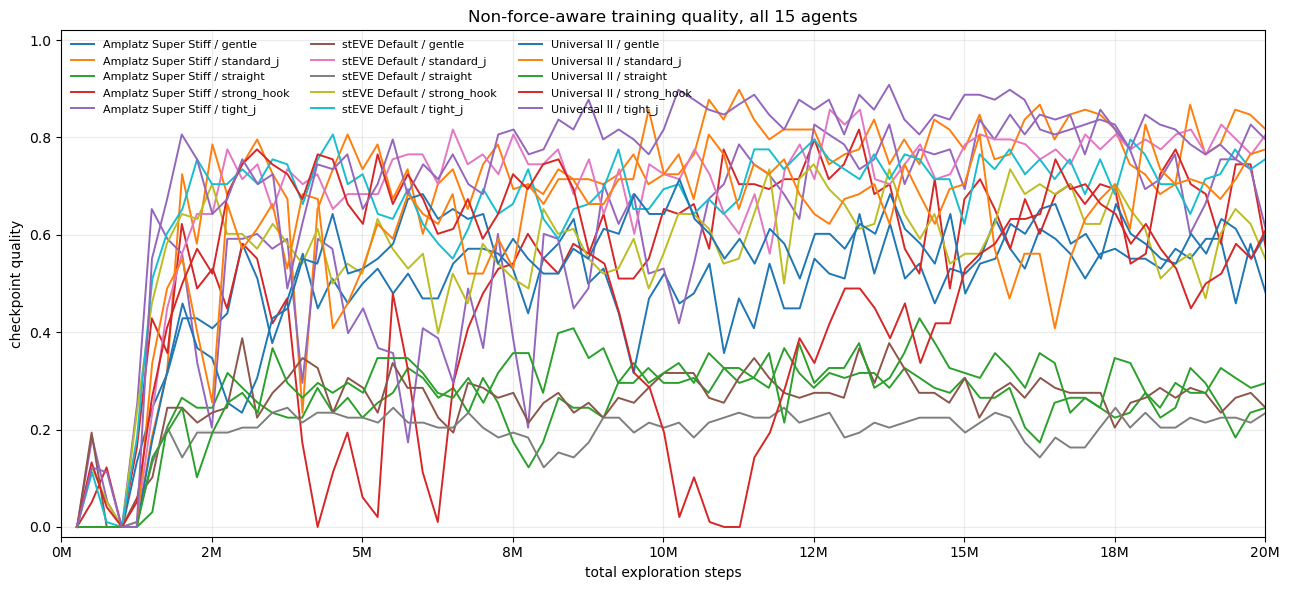

In [19]:
fig, ax = plt.subplots(figsize=(13, 6))

for (wire_model, wire_variant), group in non_force_quality_df.groupby(["wire_model", "wire_variant"], sort=True):
    label = f"{WIRE_LABELS.get(wire_model, wire_model)} / {wire_variant}"
    plot_quality_line(ax, group, label, linewidth=1.4)

setup_quality_axis(ax, "Non-force-aware training quality, all 15 agents")
ax.legend(ncol=3, fontsize=8, frameon=False)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "non_force_all_agents_quality.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "non_force_all_agents_quality.pdf", bbox_inches="tight")
plt.show()


### 3.1.1 Non-force-aware Training Curves Split by Wire Family

The same 15 non-force-aware training curves are shown as three stacked panels, one per wire family. Tip-shape colors are shared across panels so the same color always refers to the same tip shape.


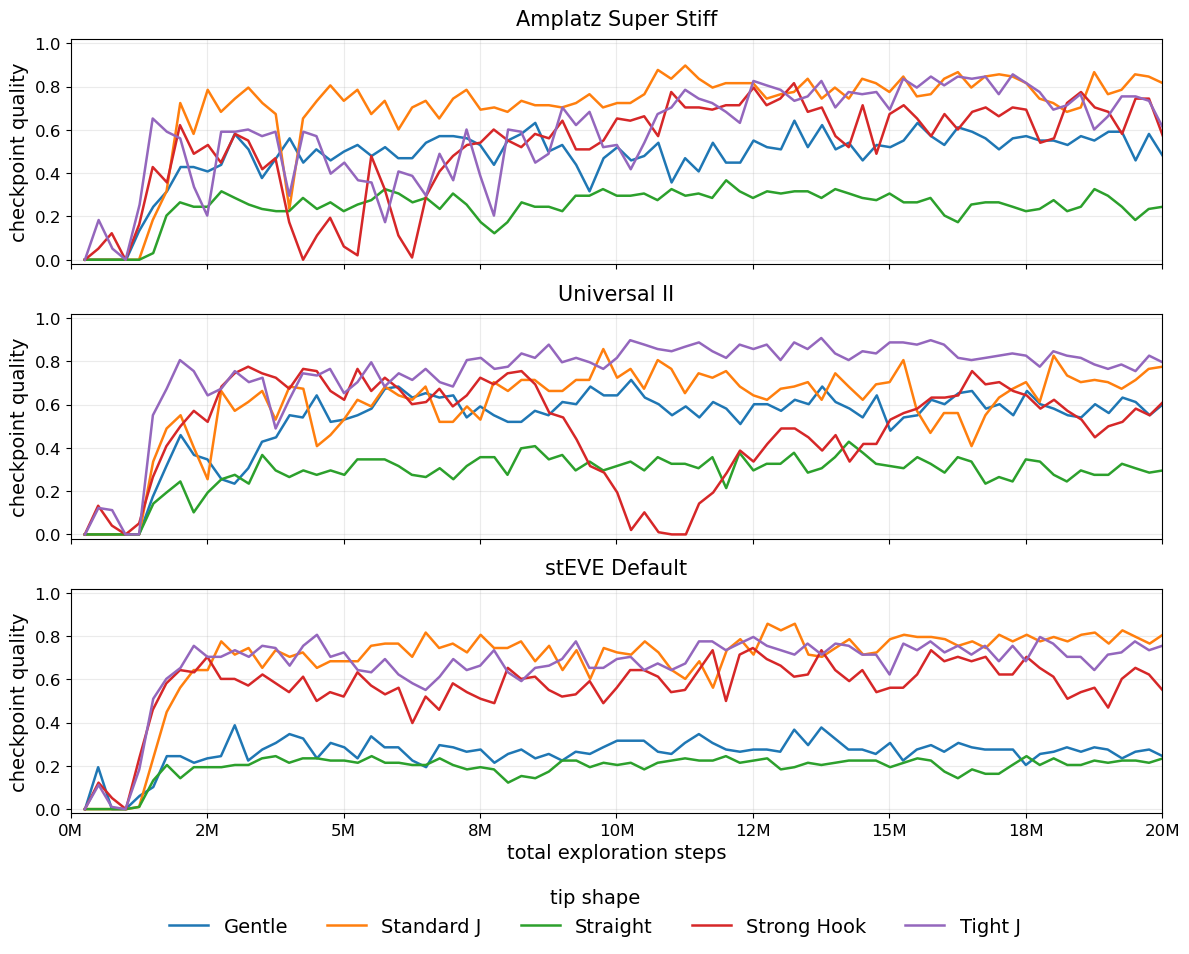

In [38]:
TIP_SHAPE_ORDER = ["gentle", "standard_j", "straight", "strong_hook", "tight_j"]
TIP_SHAPE_LABELS = {
    "gentle": "Gentle",
    "standard_j": "Standard J",
    "straight": "Straight",
    "strong_hook": "Strong Hook",
    "tight_j": "Tight J",
}
TIP_SHAPE_COLORS = {
    "gentle": "tab:blue",
    "standard_j": "tab:orange",
    "straight": "tab:green",
    "strong_hook": "tab:red",
    "tight_j": "tab:purple",
}
WIRE_FAMILY_ORDER = ["amplatz_super_stiff", "universal_ii", "steve_default"]

fig, axes = plt.subplots(
    nrows=len(WIRE_FAMILY_ORDER),
    ncols=1,
    figsize=(12, 9.5),
    sharex=True,
    sharey=True,
)

for ax, wire_model in zip(axes, WIRE_FAMILY_ORDER):
    family_df = non_force_quality_df.loc[non_force_quality_df["wire_model"].eq(wire_model)]
    for tip_shape in TIP_SHAPE_ORDER:
        group = family_df.loc[family_df["wire_variant"].eq(tip_shape)].sort_values("exploration_steps")
        if group.empty:
            continue
        ax.plot(
            group["exploration_steps"],
            group["quality"],
            label=TIP_SHAPE_LABELS.get(tip_shape, tip_shape),
            color=TIP_SHAPE_COLORS.get(tip_shape),
            linewidth=1.8,
        )

    ax.set_title(WIRE_LABELS.get(wire_model, wire_model), fontsize=15, pad=10)
    ax.set_ylabel("checkpoint quality", fontsize=14)
    ax.set_xlim(0, MAX_TRAINING_STEPS)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(FuncFormatter(million_steps))
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("total exploration steps", fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="tip shape",
    loc="lower center",
    ncol=len(TIP_SHAPE_ORDER),
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=14,
    title_fontsize=14,
)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(FIGURE_DIR / "non_force_training_quality_by_family_tip_shapes.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "non_force_training_quality_by_family_tip_shapes.pdf", bbox_inches="tight")
plt.show()


### 3.1.2 Thesis Summary: Non-force-aware Families

A cleaner summary of the same non-force-aware training curves. Each line is the mean quality of one wire family across its five variants; the shaded band shows the min-max range across variants.


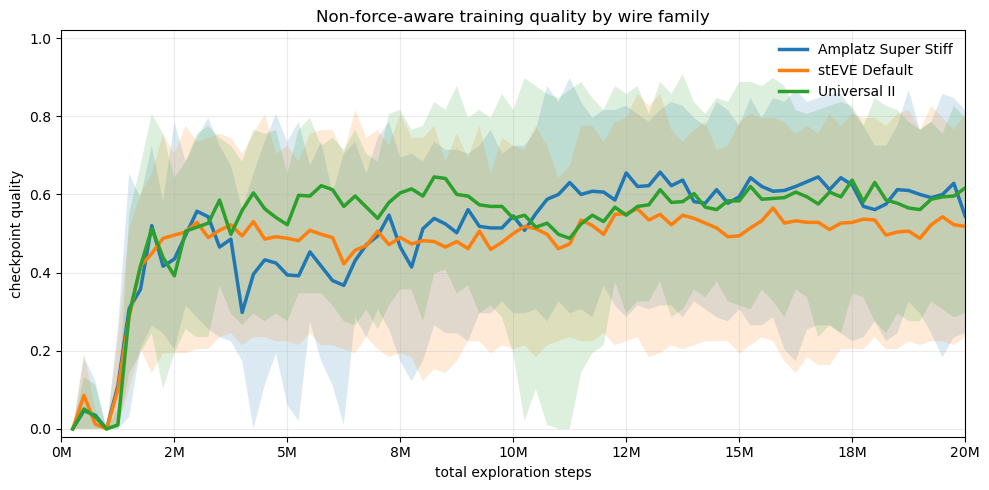

In [39]:
def plot_non_force_family_summary(bin_size=250_000):
    df = non_force_quality_df.copy()
    df["step_bin"] = (df["exploration_steps"] / bin_size).round() * bin_size

    summary = (
        df.groupby(["wire_model", "step_bin"], as_index=False)
        .agg(
            quality_mean=("quality", "mean"),
            quality_min=("quality", "min"),
            quality_max=("quality", "max"),
            variant_count=("wire_variant", "nunique"),
        )
        .sort_values(["wire_model", "step_bin"])
    )

    fig, ax = plt.subplots(figsize=(10, 5))

    for wire_model, group in summary.groupby("wire_model", sort=True):
        label = WIRE_LABELS.get(wire_model, wire_model)
        ax.plot(
            group["step_bin"],
            group["quality_mean"],
            label=label,
            linewidth=2.5,
        )
        ax.fill_between(
            group["step_bin"],
            group["quality_min"],
            group["quality_max"],
            alpha=0.16,
        )

    setup_quality_axis(ax, "Non-force-aware training quality by wire family")
    ax.legend(frameon=False)
    plt.tight_layout()
    fig.savefig(FIGURE_DIR / "non_force_family_summary_quality.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / "non_force_family_summary_quality.pdf", bbox_inches="tight")
    plt.show()

    return summary


non_force_family_quality_summary = plot_non_force_family_summary()


### 3.1.2 Non-force-aware Tip Shape Effect

This block compares the five non-force-aware wire tip shapes within each wire family. The second table averages those per-family summaries across wire families to show the overall effect of each tip shape relative to `standard_j`.


In [40]:
TIP_SHAPE_LABELS = {
    "gentle": "Gentle",
    "standard_j": "Standard J",
    "straight": "Straight",
    "strong_hook": "Strong Hook",
    "tight_j": "Tight J",
}


def summarize_tip_shape_quality(df):
    return (
        df.groupby(["wire_model", "wire_variant"], dropna=False)
        .agg(
            highest_quality=("quality", "max"),
            mean_checkpoint_quality=("quality", "mean"),
            n_checkpoints=("quality", "count"),
        )
        .reset_index()
    )


def describe_quality_table(table, table_name, metric_columns):
    rows = []
    for metric in metric_columns:
        values = pd.to_numeric(table[metric], errors="coerce").dropna()
        rows.append(
            {
                "table": table_name,
                "metric": metric,
                "mean": values.mean(),
                "standard_deviation": values.std(ddof=0),
                "minimum": values.min(),
                "maximum": values.max(),
                "min_max_difference": values.max() - values.min(),
            }
        )
    return pd.DataFrame(rows)


tip_shape_quality_summary = summarize_tip_shape_quality(non_force_quality_df)

family_quality_over_tip_shapes_table = (
    tip_shape_quality_summary.groupby("wire_model", dropna=False)
    .agg(
        highest_quality=("highest_quality", "max"),
        lowest_tip_shape_highest_quality=("highest_quality", "min"),
        highest_quality_difference=("highest_quality", lambda values: values.max() - values.min()),
        mean_checkpoint_quality=("mean_checkpoint_quality", "mean"),
        n_tip_shapes=("wire_variant", "nunique"),
        n_checkpoints=("n_checkpoints", "sum"),
    )
    .reset_index()
)
family_quality_over_tip_shapes_table["wire_family"] = family_quality_over_tip_shapes_table["wire_model"].map(WIRE_LABELS)
family_quality_over_tip_shapes_table = family_quality_over_tip_shapes_table[
    [
        "wire_family",
        "highest_quality",
        "lowest_tip_shape_highest_quality",
        "highest_quality_difference",
        "mean_checkpoint_quality",
        "n_tip_shapes",
        "n_checkpoints",
    ]
].sort_values("wire_family")
standard_j_tip_baseline = (
    tip_shape_quality_summary[tip_shape_quality_summary["wire_variant"].eq("standard_j")]
    [["wire_model", "highest_quality", "mean_checkpoint_quality"]]
    .rename(
        columns={
            "highest_quality": "standard_j_highest_quality",
            "mean_checkpoint_quality": "standard_j_mean_checkpoint_quality",
        }
    )
)

tip_shape_family_effect_table = tip_shape_quality_summary.merge(
    standard_j_tip_baseline,
    on="wire_model",
    how="left",
)
tip_shape_family_effect_table["delta_highest_quality_vs_standard_j"] = (
    tip_shape_family_effect_table["highest_quality"]
    - tip_shape_family_effect_table["standard_j_highest_quality"]
)
tip_shape_family_effect_table["delta_mean_checkpoint_quality_vs_standard_j"] = (
    tip_shape_family_effect_table["mean_checkpoint_quality"]
    - tip_shape_family_effect_table["standard_j_mean_checkpoint_quality"]
)
tip_shape_family_effect_table["wire_family"] = tip_shape_family_effect_table["wire_model"].map(WIRE_LABELS)
tip_shape_family_effect_table["tip_shape"] = tip_shape_family_effect_table["wire_variant"].map(TIP_SHAPE_LABELS)

tip_shape_family_effect_table = tip_shape_family_effect_table[
    [
        "wire_family",
        "tip_shape",
        "highest_quality",
        "mean_checkpoint_quality",
        "n_checkpoints",
    ]
].sort_values(["wire_family", "tip_shape"])

tip_shape_overall_effect_table = (
    tip_shape_family_effect_table.groupby("tip_shape", dropna=False)
    .agg(
        mean_highest_quality_across_families=("highest_quality", "mean"),
        mean_checkpoint_quality_across_families=("mean_checkpoint_quality", "mean"),
        wire_families=("wire_family", "nunique"),
    )
    .reset_index()
    .sort_values("mean_checkpoint_quality_across_families", ascending=False)
)

tip_shape_quality_format = {
    "highest_quality": "{:.3f}",
    "lowest_tip_shape_highest_quality": "{:.3f}",
    "highest_quality_difference": "{:.3f}",
    "mean_checkpoint_quality": "{:.3f}",
    "mean_highest_quality_across_families": "{:.3f}",
    "mean_checkpoint_quality_across_families": "{:.3f}",
}
stats_format = {
    "mean": "{:.3f}",
    "standard_deviation": "{:.3f}",
    "minimum": "{:.3f}",
    "maximum": "{:.3f}",
    "min_max_difference": "{:.3f}",
}

family_quality_stats_table = describe_quality_table(
    family_quality_over_tip_shapes_table,
    "wire-family quality over all tip shapes",
    [
        "highest_quality",
        "lowest_tip_shape_highest_quality",
        "highest_quality_difference",
        "mean_checkpoint_quality",
    ],
)
tip_shape_family_stats_table = describe_quality_table(
    tip_shape_family_effect_table,
    "tip-shape rows within wire families",
    ["highest_quality", "mean_checkpoint_quality"],
)
tip_shape_overall_stats_table = describe_quality_table(
    tip_shape_overall_effect_table,
    "tip-shape means across wire families",
    ["mean_highest_quality_across_families", "mean_checkpoint_quality_across_families"],
)

print("Non-force-aware wire-family quality over all tip shapes")
display(family_quality_over_tip_shapes_table.style.format(tip_shape_quality_format))
display(family_quality_stats_table.style.format(stats_format))

print("Non-force-aware tip-shape effect within each wire family")
display(tip_shape_family_effect_table.style.format(tip_shape_quality_format))
display(tip_shape_family_stats_table.style.format(stats_format))

print("Non-force-aware tip-shape effect averaged across wire families")
display(tip_shape_overall_effect_table.style.format(tip_shape_quality_format))
display(tip_shape_overall_stats_table.style.format(stats_format))






Non-force-aware wire-family quality over all tip shapes


,wire_family,highest_quality,lowest_tip_shape_highest_quality,highest_quality_difference,mean_checkpoint_quality,n_tip_shapes,n_checkpoints
0,Amplatz Super Stiff,0.898,0.367,0.531,0.506,5,400
2,Universal II,0.908,0.429,0.480,0.530,5,400
1,stEVE Default,0.857,0.245,0.612,0.473,5,400


,table,metric,mean,standard_deviation,minimum,maximum,min_max_difference
0,wire-family quality over all tip shapes,highest_quality,0.888,0.022,0.857,0.908,0.051
1,wire-family quality over all tip shapes,lowest_tip_shape_highest_quality,0.347,0.076,0.245,0.429,0.184
2,wire-family quality over all tip shapes,highest_quality_difference,0.541,0.055,0.480,0.612,0.133
3,wire-family quality over all tip shapes,mean_checkpoint_quality,0.503,0.023,0.473,0.530,0.057


Non-force-aware tip-shape effect within each wire family


,wire_family,tip_shape,highest_quality,mean_checkpoint_quality,n_checkpoints
0,Amplatz Super Stiff,Gentle,0.643,0.478,80
1,Amplatz Super Stiff,Standard J,0.898,0.696,80
2,Amplatz Super Stiff,Straight,0.367,0.247,80
3,Amplatz Super Stiff,Strong Hook,0.816,0.520,80
4,Amplatz Super Stiff,Tight J,0.857,0.588,80
10,Universal II,Gentle,0.714,0.524,80
11,Universal II,Standard J,0.857,0.601,80
12,Universal II,Straight,0.429,0.286,80
13,Universal II,Strong Hook,0.776,0.493,80
14,Universal II,Tight J,0.908,0.746,80


,table,metric,mean,standard_deviation,minimum,maximum,min_max_difference
0,tip-shape rows within wire families,highest_quality,0.687,0.213,0.245,0.908,0.663
1,tip-shape rows within wire families,mean_checkpoint_quality,0.503,0.172,0.194,0.746,0.552


Non-force-aware tip-shape effect averaged across wire families


,tip_shape,mean_highest_quality_across_families,mean_checkpoint_quality_across_families,wire_families
4,Tight J,0.857,0.665,3
1,Standard J,0.871,0.661,3
3,Strong Hook,0.779,0.525,3
0,Gentle,0.582,0.421,3
2,Straight,0.347,0.242,3


,table,metric,mean,standard_deviation,minimum,maximum,min_max_difference
0,tip-shape means across wire families,mean_highest_quality_across_families,0.687,0.199,0.347,0.871,0.524
1,tip-shape means across wire families,mean_checkpoint_quality_across_families,0.503,0.159,0.242,0.665,0.423


### 3.1.3 Tip Shape Quality Grid

Grid view of the best checkpoint quality for each non-force-aware tip shape and wire family. Darker cells indicate higher maximum checkpoint quality.


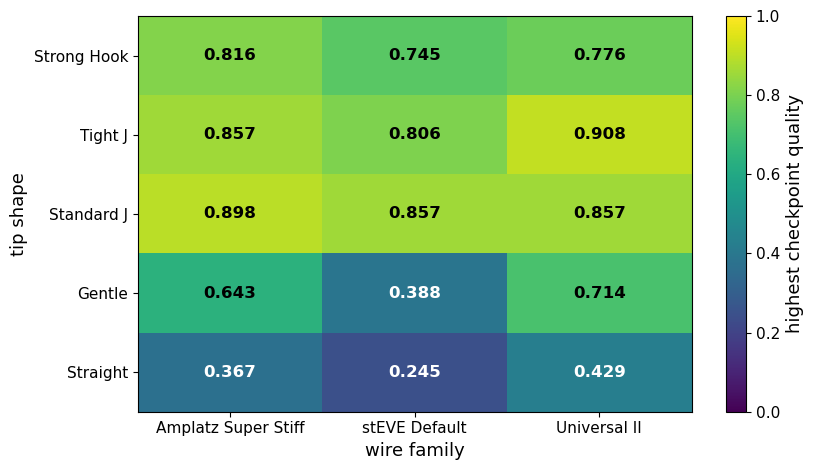

In [41]:
tip_shape_order = ["Strong Hook", "Tight J", "Standard J", "Gentle", "Straight"]
wire_family_order = ["Amplatz Super Stiff", "stEVE Default", "Universal II"]

quality_grid = (
    tip_shape_family_effect_table.pivot(
        index="tip_shape",
        columns="wire_family",
        values="highest_quality",
    )
    .reindex(index=tip_shape_order, columns=wire_family_order)
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
im = ax.imshow(quality_grid, cmap="viridis", vmin=0.0, vmax=1.0, aspect="auto")

ax.set_xticks(range(len(quality_grid.columns)))
ax.set_xticklabels(quality_grid.columns, fontsize=11)
ax.set_yticks(range(len(quality_grid.index)))
ax.set_yticklabels(quality_grid.index, fontsize=11)
ax.set_xlabel("wire family", fontsize=13)
ax.set_ylabel("tip shape", fontsize=13)
ax.tick_params(axis="both", labelsize=11)

for row_idx, tip_shape in enumerate(quality_grid.index):
    for col_idx, wire_family in enumerate(quality_grid.columns):
        value = quality_grid.loc[tip_shape, wire_family]
        text_color = "white" if value < 0.55 else "black"
        ax.text(
            col_idx,
            row_idx,
            f"{value:.3f}",
            ha="center",
            va="center",
            color=text_color,
            fontsize=12,
            fontweight="bold",
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("highest checkpoint quality", fontsize=13)
cbar.ax.tick_params(labelsize=11)
plt.tight_layout()
fig.savefig(FIGURE_DIR / "non_force_tip_shape_quality_grid.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "non_force_tip_shape_quality_grid.pdf", bbox_inches="tight")
plt.show()




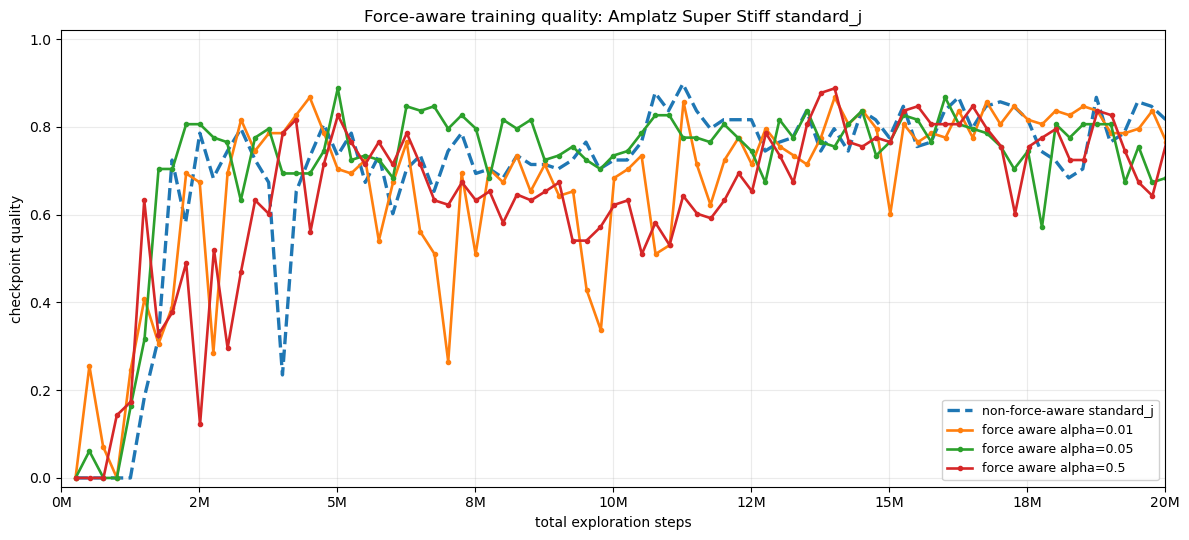

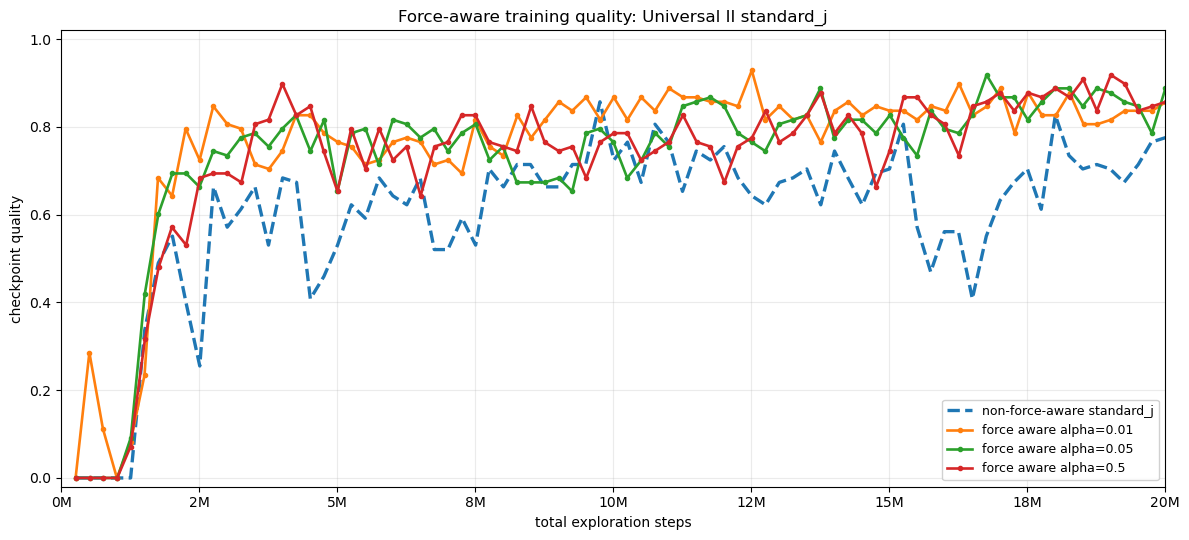

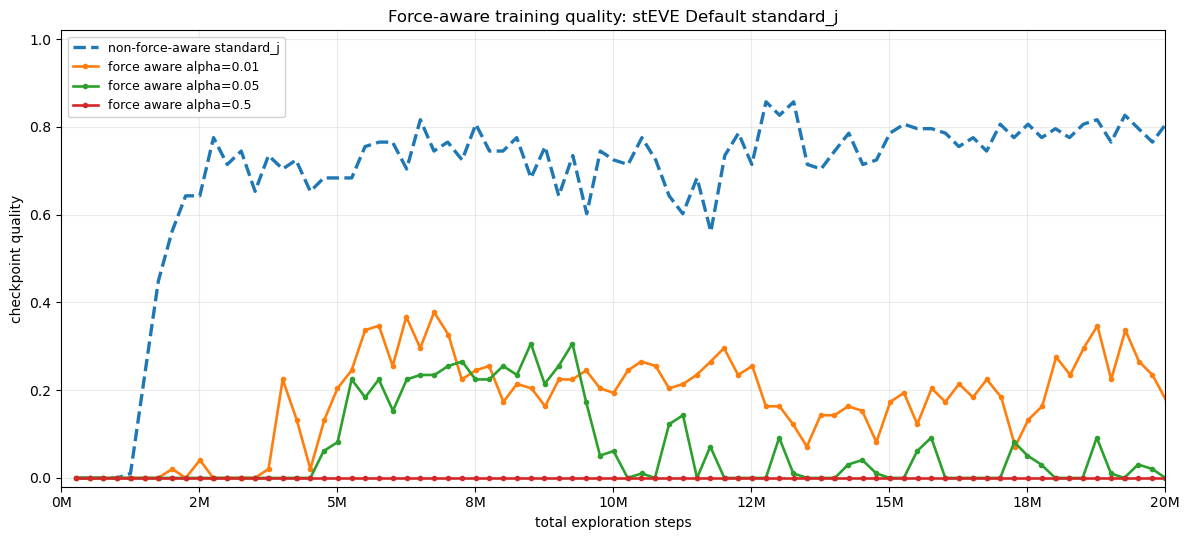

In [42]:
def plot_force_aware_wire_quality(wire_model):
    fig, ax = plt.subplots(figsize=(12, 5.5))

    baseline = non_force_quality_df[
        non_force_quality_df["wire_model"].eq(wire_model)
        & non_force_quality_df["wire_variant"].eq("standard_j")
    ]
    if not baseline.empty:
        plot_quality_line(
            ax,
            baseline,
            "non-force-aware standard_j",
            linestyle="--",
            linewidth=2.4,
        )

    force_rows = force_aware_quality_df[force_aware_quality_df["wire_model"].eq(wire_model)]
    for alpha, group in force_rows.groupby("force_alpha", sort=True):
        label = ALPHA_LABELS.get(alpha, f"force aware {alpha}")
        plot_quality_line(ax, group, label, linewidth=1.9, marker="o")

    title = f"Force-aware training quality: {WIRE_LABELS.get(wire_model, wire_model)} standard_j"
    setup_quality_axis(ax, title)
    legend_loc = "upper left" if wire_model == "steve_default" else "lower right"
    ax.legend(loc=legend_loc, fontsize=9, frameon=True, framealpha=0.9)
    plt.tight_layout()
    figure_stem = f"force_aware_{wire_model}_standard_j_quality"
    fig.savefig(FIGURE_DIR / f"{figure_stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURE_DIR / f"{figure_stem}.pdf", bbox_inches="tight")
    plt.show()


plot_force_aware_wire_quality("amplatz_super_stiff")
plot_force_aware_wire_quality("universal_ii")
plot_force_aware_wire_quality("steve_default")


### 3.1.3 Force-aware Training Curves Split by Wire Family

The force-aware standard-J training curves are shown as three stacked panels, one per wire family. The dashed line is the corresponding non-force-aware standard-J reference training curve. Force-aware alpha values use the same colors in every panel.


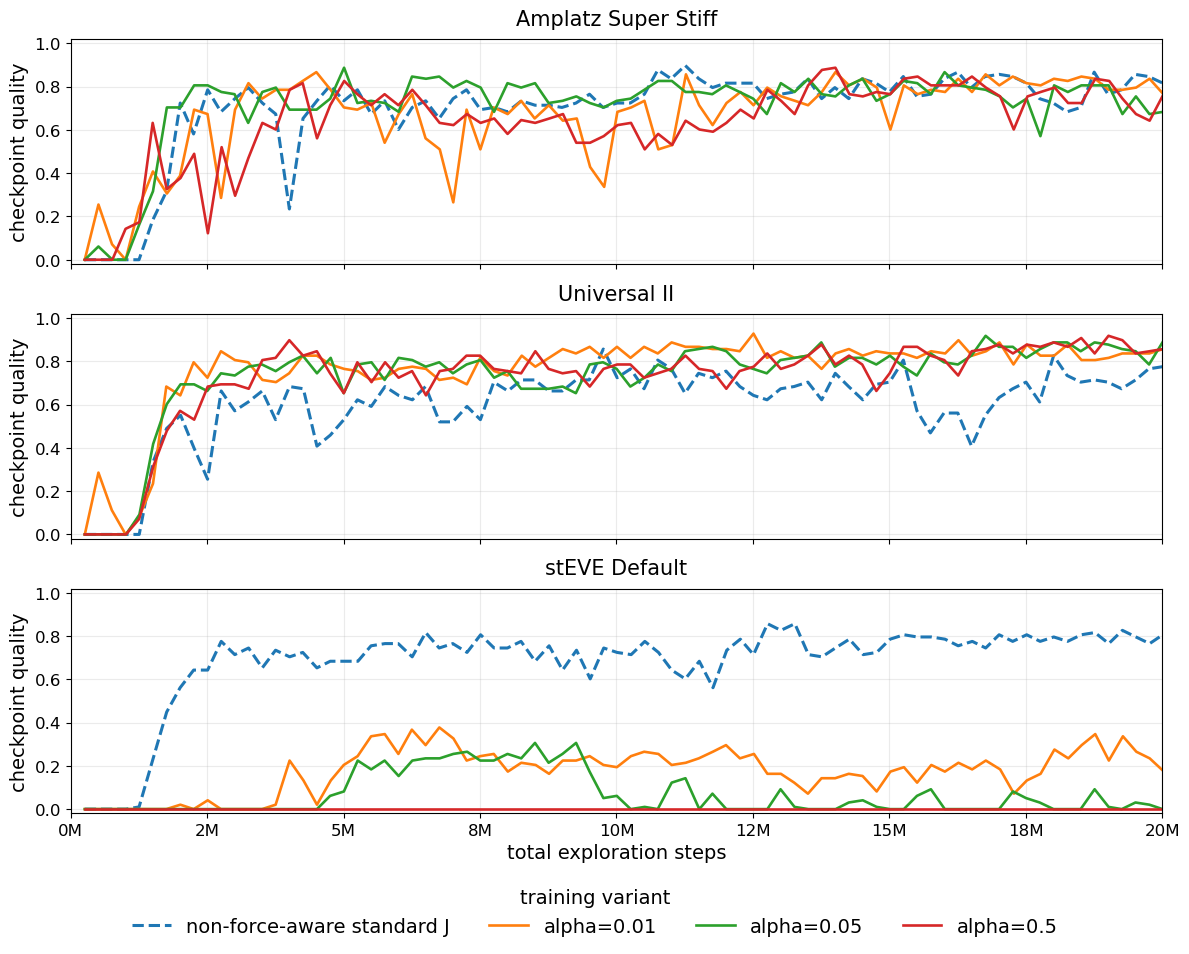

In [43]:
ALPHA_ORDER = ["a001", "a005", "a05"]
ALPHA_COLORS = {
    "a001": "tab:orange",
    "a005": "tab:green",
    "a05": "tab:red",
}
ALPHA_SHORT_LABELS = {
    "a001": "alpha=0.01",
    "a005": "alpha=0.05",
    "a05": "alpha=0.5",
}
FORCE_WIRE_FAMILY_ORDER = ["amplatz_super_stiff", "universal_ii", "steve_default"]

fig, axes = plt.subplots(
    nrows=len(FORCE_WIRE_FAMILY_ORDER),
    ncols=1,
    figsize=(12, 9.5),
    sharex=True,
    sharey=True,
)

for ax, wire_model in zip(axes, FORCE_WIRE_FAMILY_ORDER):
    baseline = non_force_quality_df[
        non_force_quality_df["wire_model"].eq(wire_model)
        & non_force_quality_df["wire_variant"].eq("standard_j")
    ].sort_values("exploration_steps")
    if not baseline.empty:
        ax.plot(
            baseline["exploration_steps"],
            baseline["quality"],
            label="non-force-aware standard J",
            color="tab:blue",
            linestyle="--",
            linewidth=2.2,
        )

    family_force_df = force_aware_quality_df.loc[force_aware_quality_df["wire_model"].eq(wire_model)]
    for alpha in ALPHA_ORDER:
        group = family_force_df.loc[family_force_df["force_alpha"].eq(alpha)].sort_values("exploration_steps")
        if group.empty:
            continue
        ax.plot(
            group["exploration_steps"],
            group["quality"],
            label=ALPHA_SHORT_LABELS.get(alpha, alpha),
            color=ALPHA_COLORS.get(alpha),
            linewidth=1.9,
        )

    ax.set_title(WIRE_LABELS.get(wire_model, wire_model), fontsize=15, pad=10)
    ax.set_ylabel("checkpoint quality", fontsize=14)
    ax.set_xlim(0, MAX_TRAINING_STEPS)
    ax.set_ylim(-0.02, 1.02)
    ax.xaxis.set_major_formatter(FuncFormatter(million_steps))
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("total exploration steps", fontsize=14)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    title="training variant",
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.01),
    fontsize=14,
    title_fontsize=14,
)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(FIGURE_DIR / "force_aware_training_quality_by_family_alpha.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "force_aware_training_quality_by_family_alpha.pdf", bbox_inches="tight")
plt.show()


### 3.1.4 Force-aware Reward Components and Force Distribution

This block summarizes the per-episode reward terms of the force-aware training runs. The table reports mean reward components per wire family and force-reward weight $\alpha$. The figure combines reward composition, force distribution, and checkpoint-quality trajectories for the nine force-aware agents.


Saved reward-component summary: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_force_aware_reward_component_summary.csv`

,wire_family,alpha,mean_target,mean_path_delta,mean_step,mean_force,mean_force_step_penalty,mean_force_terminal_penalty,mean_wire_force_trial_max_N,median_wire_force_trial_max_N,n_episodes
6,Universal II,0.01,0.6002,0.2390,-0.5523,-0.0000,-0.0000,0.0,0.0595,0.0505,188867
7,Universal II,0.05,0.5151,0.2314,-0.5863,-0.0001,-0.0000,0.0,0.0566,0.0474,175643
8,Universal II,0.5,0.5366,0.2333,-0.5780,-0.0013,-0.0000,0.0,0.0594,0.0498,178629
0,Amplatz Super Stiff,0.01,0.4114,0.2020,-0.6310,-0.0004,-0.0000,0.0,0.3836,0.3152,163144
1,Amplatz Super Stiff,0.05,0.4815,0.2187,-0.5923,-0.0025,-0.0001,0.0,0.4232,0.3526,175175
2,Amplatz Super Stiff,0.5,0.4150,0.2125,-0.6215,-0.0337,-0.0007,0.0,0.3837,0.3020,167624
3,stEVE Default,0.01,0.1039,0.1494,-0.7114,-0.1056,-0.0026,0.0,1.8593,1.3218,145354
4,stEVE Default,0.05,0.0450,0.1071,-0.7325,-0.3075,-0.0057,0.0,1.1956,0.9408,141200
5,stEVE Default,0.5,0.0001,0.0293,-0.7500,-0.4791,-0.0028,0.0,0.2967,0.0000,138191


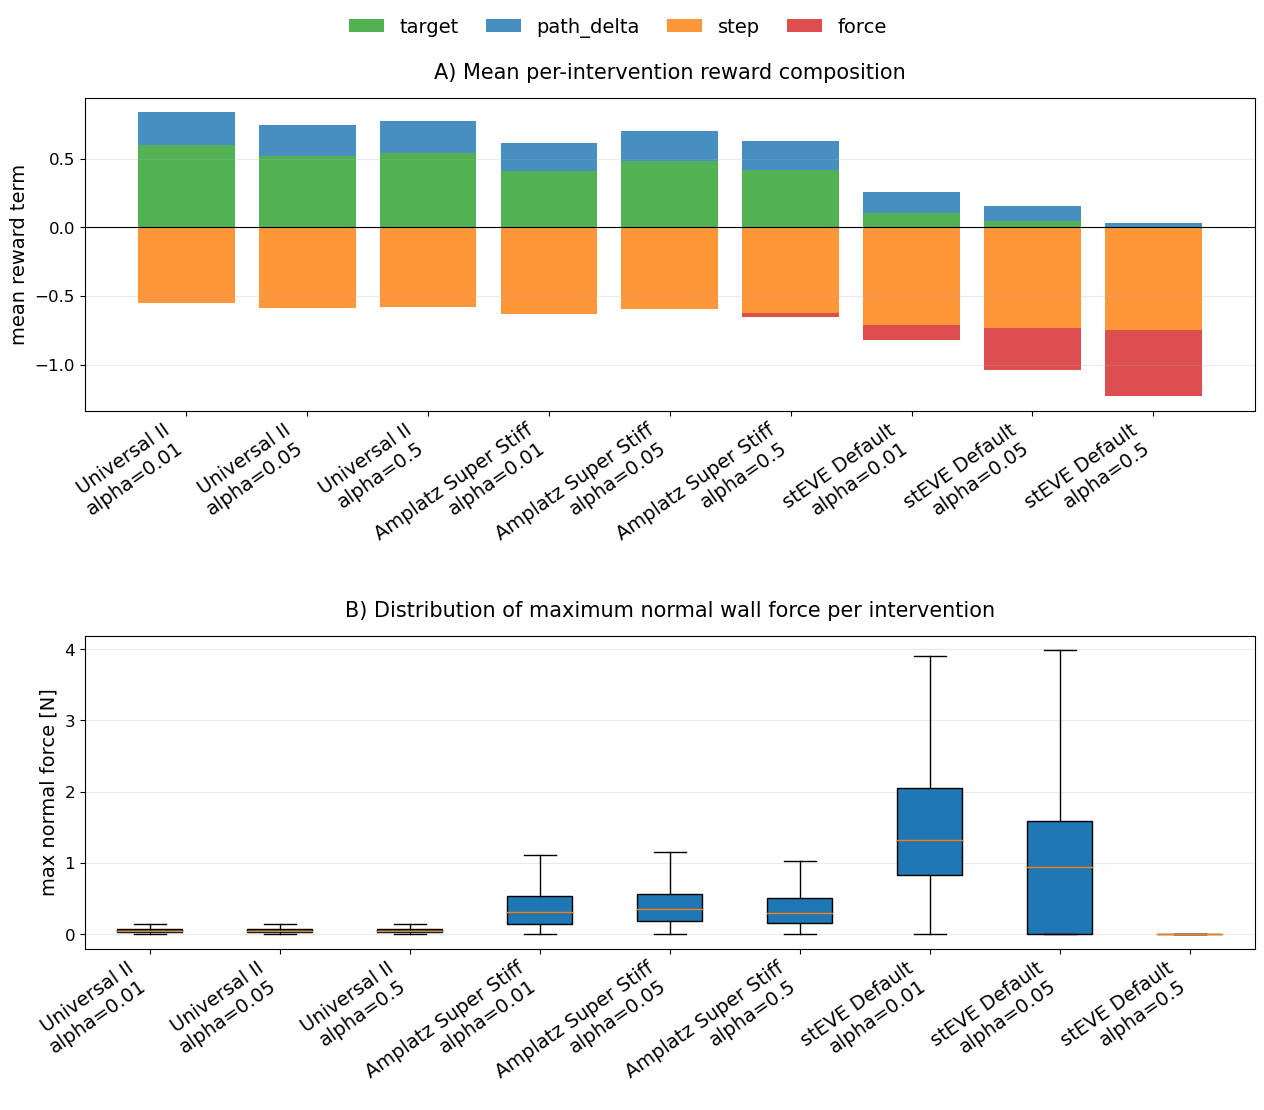

Saved combined figure: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/figures/e1_training/force_aware_reward_components_force_distribution.png`

In [37]:
# Force-aware reward-component table and thesis figure.
# Uses training episodes by default; change E1_REWARD_SPLIT_FOR_COMPONENTS to "eval" if needed.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from IPython.display import display, Markdown

E1_REWARD_SPLIT_FOR_COMPONENTS = "train"
E1_REWARD_CSV = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis" / "e1_training_episode_rewards.csv"
E1_REWARD_COMPONENT_CSV = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis" / "e1_force_aware_reward_component_summary.csv"

if "FIGURE_DIR" not in globals():
    FIGURE_DIR = PROJECT_ROOT / "results" / "master_thesis" / "figures" / "e1_training"
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
if "WIRE_LABELS" not in globals():
    WIRE_LABELS = {
        "amplatz_super_stiff": "Amplatz Super Stiff",
        "universal_ii": "Universal II",
        "steve_default": "stEVE Default",
    }

if "training_episode_reward_df" not in globals():
    if not E1_REWARD_CSV.exists():
        raise FileNotFoundError(
            "Run section 3.0.1 first, or create the per-episode reward CSV at "
            f"{E1_REWARD_CSV}"
        )
    training_episode_reward_df = pd.read_csv(E1_REWARD_CSV)

force_reward_df = training_episode_reward_df.loc[
    training_episode_reward_df["training_family"].eq("force_aware")
    & training_episode_reward_df["reward_split"].eq(E1_REWARD_SPLIT_FOR_COMPONENTS)
].copy()

numeric_reward_cols = [
    "target",
    "path_delta",
    "step",
    "force",
    "force_step_penalty",
    "force_terminal_penalty",
    "wire_force_normal_trial_max_N",
]
for col in numeric_reward_cols:
    if col in force_reward_df.columns:
        force_reward_df[col] = pd.to_numeric(force_reward_df[col], errors="coerce")

force_reward_df["wire_family"] = force_reward_df["wire_model"].map(WIRE_LABELS).fillna(force_reward_df["wire_model"])
force_reward_df["alpha"] = force_reward_df["force_alpha"].map({"a001": "0.01", "a005": "0.05", "a05": "0.5"}).fillna(force_reward_df["force_alpha"])

reward_component_summary_df = (
    force_reward_df
    .groupby(["wire_model", "wire_family", "force_alpha", "alpha"], dropna=False)
    .agg(
        mean_target=("target", "mean"),
        mean_path_delta=("path_delta", "mean"),
        mean_step=("step", "mean"),
        mean_force=("force", "mean"),
        mean_force_step_penalty=("force_step_penalty", "mean"),
        mean_force_terminal_penalty=("force_terminal_penalty", "mean"),
        mean_wire_force_trial_max_N=("wire_force_normal_trial_max_N", "mean"),
        median_wire_force_trial_max_N=("wire_force_normal_trial_max_N", "median"),
        n_episodes=("episode", "count"),
        n_reward_files=("source_file", "nunique"),
    )
    .reset_index()
)
reward_component_summary_df["force_penalty_total_last_step_snapshot"] = (
    reward_component_summary_df["mean_force_step_penalty"]
    + reward_component_summary_df["mean_force_terminal_penalty"]
)

wire_order = ["universal_ii", "amplatz_super_stiff", "steve_default"]
alpha_order = ["a001", "a005", "a05"]
reward_component_summary_df["wire_order"] = reward_component_summary_df["wire_model"].map({wire: i for i, wire in enumerate(wire_order)})
reward_component_summary_df["alpha_order"] = reward_component_summary_df["force_alpha"].map({alpha: i for i, alpha in enumerate(alpha_order)})
reward_component_summary_df = reward_component_summary_df.sort_values(["wire_order", "alpha_order"]).drop(columns=["wire_order", "alpha_order"])
reward_component_summary_df.to_csv(E1_REWARD_COMPONENT_CSV, index=False)

display(Markdown(f"Saved reward-component summary: `{E1_REWARD_COMPONENT_CSV}`"))
display(
    reward_component_summary_df[
        [
            "wire_family",
            "alpha",
            "mean_target",
            "mean_path_delta",
            "mean_step",
            "mean_force",
            "mean_force_step_penalty",
            "mean_force_terminal_penalty",
            "mean_wire_force_trial_max_N",
            "median_wire_force_trial_max_N",
            "n_episodes",
        ]
    ].round(4)
)

ordered_summary = (
    reward_component_summary_df
    .set_index(["wire_model", "force_alpha"])
    .reindex(pd.MultiIndex.from_product([wire_order, alpha_order], names=["wire_model", "force_alpha"]))
    .reset_index()
)
labels = [
    f"{WIRE_LABELS.get(row.wire_model, row.wire_model)}\nalpha={row.alpha}"
    for row in ordered_summary.itertuples(index=False)
]
x = np.arange(len(ordered_summary))

fig, axes = plt.subplots(2, 1, figsize=(13, 11.5), sharex=False)
TITLE_FONTSIZE = 15
AXIS_LABEL_FONTSIZE = 14
TICK_LABEL_FONTSIZE = 12
CATEGORY_LABEL_FONTSIZE = 14
LEGEND_FONTSIZE = 14

# A: Reward composition. Positive and negative terms are stacked separately.
reward_terms = [
    ("mean_target", "target", "tab:green"),
    ("mean_path_delta", "path_delta", "tab:blue"),
    ("mean_step", "step", "tab:orange"),
    # `force` is the episode-summed force reward component.
    # The separate force_step_penalty / force_terminal_penalty columns are
    # diagnostics from the last step of the episode, not episode sums.
    ("mean_force", "force", "tab:red"),
]
positive_bottom = np.zeros(len(ordered_summary))
negative_bottom = np.zeros(len(ordered_summary))
for col, label, color in reward_terms:
    values = ordered_summary[col].fillna(0).to_numpy(dtype=float)
    bottoms = np.where(values >= 0, positive_bottom, negative_bottom)
    axes[0].bar(x, values, bottom=bottoms, label=label, color=color, alpha=0.82)
    positive_bottom += np.where(values >= 0, values, 0)
    negative_bottom += np.where(values < 0, values, 0)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("A) Mean per-intervention reward composition", fontsize=TITLE_FONTSIZE, pad=14)
axes[0].set_ylabel("mean reward term", fontsize=AXIS_LABEL_FONTSIZE)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=35, ha="right", fontsize=CATEGORY_LABEL_FONTSIZE)
axes[0].tick_params(axis="y", labelsize=TICK_LABEL_FONTSIZE)
axes[0].yaxis.set_major_locator(MultipleLocator(0.5))
handles, legend_labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    legend_labels,
    ncol=4,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.985),
    fontsize=LEGEND_FONTSIZE,
    handlelength=1.8,
    columnspacing=1.4,
)
axes[0].grid(True, axis="y", alpha=0.25)

# B: Force distribution. Outliers are shown explicitly.
force_groups = []
for wire in wire_order:
    for alpha in alpha_order:
        values = force_reward_df.loc[
            force_reward_df["wire_model"].eq(wire)
            & force_reward_df["force_alpha"].eq(alpha),
            "wire_force_normal_trial_max_N",
        ].dropna()
        force_groups.append(values.to_numpy(dtype=float))
axes[1].boxplot(
    force_groups,
    showfliers=False,
    patch_artist=True,
    flierprops={
        "marker": ".",
        "markersize": 2,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "alpha": 0.20,
    },
)
axes[1].set_title("B) Distribution of maximum normal wall force per intervention", fontsize=TITLE_FONTSIZE, pad=14)
axes[1].set_ylabel("max normal force [N]", fontsize=AXIS_LABEL_FONTSIZE)
axes[1].set_xticks(x + 1)
axes[1].set_xticklabels(labels, rotation=35, ha="right", fontsize=CATEGORY_LABEL_FONTSIZE)
axes[1].tick_params(axis="y", labelsize=TICK_LABEL_FONTSIZE)
axes[1].yaxis.set_major_locator(MultipleLocator(1.0))
axes[1].grid(True, axis="y", alpha=0.25)

#fig.suptitle("Force-aware training reward components and force distribution", y=0.997)
fig.subplots_adjust(left=0.09, right=0.99, top=0.90, bottom=0.16, hspace=0.72)
figure_path_png = FIGURE_DIR / "force_aware_reward_components_force_distribution.png"
figure_path_pdf = FIGURE_DIR / "force_aware_reward_components_force_distribution.pdf"
fig.savefig(figure_path_png, dpi=300, bbox_inches="tight")
fig.savefig(figure_path_pdf, bbox_inches="tight")
plt.show()

display(Markdown(f"Saved combined figure: `{figure_path_png}`"))


### 3.1.5 Data-driven explanation of force-aware training differences

This block compares the force-aware agents against the corresponding non-force-aware standard-J reference. It combines checkpoint-quality deltas with per-intervention reward and force statistics to identify which measured quantities explain the different behavior across wire families.


In [31]:
# Data-driven explanation of why force-aware training behaves differently by wire family.
import pandas as pd
from IPython.display import display, Markdown

E1_EXPLANATION_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
E1_EXPLANATION_DIR.mkdir(parents=True, exist_ok=True)
E1_REWARD_CSV = E1_EXPLANATION_DIR / "e1_training_episode_rewards.csv"

required_tables = ["non_force_quality_df", "force_aware_quality_df"]
missing_tables = [name for name in required_tables if name not in globals()]
if missing_tables:
    display(Markdown("Run the training-log and quality setup cells first. Missing: `" + "`, `".join(missing_tables) + "`."))
elif not E1_REWARD_CSV.exists() and "training_episode_reward_df" not in globals():
    display(Markdown(f"Run section 3.0.1 first. Missing reward CSV: `{E1_REWARD_CSV}`"))
else:
    if "training_episode_reward_df" not in globals():
        training_episode_reward_df = pd.read_csv(E1_REWARD_CSV)

    alpha_label_map = {"a001": "0.01", "a005": "0.05", "a05": "0.5"}

    baseline_quality = (
        non_force_quality_df.loc[non_force_quality_df["wire_variant"].eq("standard_j")]
        .groupby("wire_model", dropna=False)
        .agg(
            baseline_highest_quality=("quality", "max"),
            baseline_mean_checkpoint_quality=("quality", "mean"),
            baseline_final_checkpoint_quality=("quality", lambda values: values.tail(10).mean()),
        )
        .reset_index()
    )

    force_quality = (
        force_aware_quality_df
        .groupby(["wire_model", "force_alpha"], dropna=False)
        .agg(
            force_highest_quality=("quality", "max"),
            force_mean_checkpoint_quality=("quality", "mean"),
            force_final_checkpoint_quality=("quality", lambda values: values.tail(10).mean()),
            n_checkpoints=("quality", "count"),
        )
        .reset_index()
        .merge(baseline_quality, on="wire_model", how="left")
    )
    force_quality["delta_highest_quality"] = force_quality["force_highest_quality"] - force_quality["baseline_highest_quality"]
    force_quality["delta_mean_checkpoint_quality"] = force_quality["force_mean_checkpoint_quality"] - force_quality["baseline_mean_checkpoint_quality"]
    force_quality["delta_final_checkpoint_quality"] = force_quality["force_final_checkpoint_quality"] - force_quality["baseline_final_checkpoint_quality"]

    reward_cols = [
        "training_family",
        "wire_model",
        "force_alpha",
        "reward_split",
        "episode",
        "steps",
        "total",
        "target",
        "path_delta",
        "step",
        "force",
        "wire_force_normal_trial_max_N",
        "is_success_episode",
    ]
    reward_cols = [col for col in reward_cols if col in training_episode_reward_df.columns]
    reward_df = training_episode_reward_df.loc[
        training_episode_reward_df["training_family"].eq("force_aware")
        & training_episode_reward_df["reward_split"].eq("train"),
        reward_cols,
    ].copy()
    for col in ["steps", "total", "target", "path_delta", "step", "force", "wire_force_normal_trial_max_N"]:
        if col in reward_df.columns:
            reward_df[col] = pd.to_numeric(reward_df[col], errors="coerce")

    reward_force_stats = (
        reward_df
        .groupby(["wire_model", "force_alpha"], dropna=False)
        .agg(
            training_success_rate=("is_success_episode", "mean"),
            mean_total_reward=("total", "mean"),
            mean_target_reward=("target", "mean"),
            mean_path_delta_reward=("path_delta", "mean"),
            mean_step_reward=("step", "mean"),
            mean_force_reward=("force", "mean"),
            mean_steps=("steps", "mean"),
            median_max_force_N=("wire_force_normal_trial_max_N", "median"),
            p95_max_force_N=("wire_force_normal_trial_max_N", lambda values: values.quantile(0.95)),
            mean_max_force_N=("wire_force_normal_trial_max_N", "mean"),
            n_interventions=("episode", "count"),
        )
        .reset_index()
    )

    force_explanation_df = force_quality.merge(reward_force_stats, on=["wire_model", "force_alpha"], how="left")
    force_explanation_df["wire_family"] = force_explanation_df["wire_model"].map(WIRE_LABELS).fillna(force_explanation_df["wire_model"])
    force_explanation_df["alpha"] = force_explanation_df["force_alpha"].map(alpha_label_map).fillna(force_explanation_df["force_alpha"])
    force_explanation_df = force_explanation_df.sort_values(["wire_model", "force_alpha"])

    explanation_cols = [
        "wire_family",
        "alpha",
        "delta_mean_checkpoint_quality",
        "delta_highest_quality",
        "training_success_rate",
        "mean_total_reward",
        "mean_target_reward",
        "mean_path_delta_reward",
        "mean_step_reward",
        "mean_force_reward",
        "mean_steps",
        "median_max_force_N",
        "p95_max_force_N",
    ]

    family_explanation_df = (
        force_explanation_df
        .groupby(["wire_model", "wire_family"], dropna=False)
        .agg(
            mean_delta_mean_checkpoint_quality=("delta_mean_checkpoint_quality", "mean"),
            mean_delta_highest_quality=("delta_highest_quality", "mean"),
            mean_training_success_rate=("training_success_rate", "mean"),
            mean_total_reward=("mean_total_reward", "mean"),
            mean_target_reward=("mean_target_reward", "mean"),
            mean_path_delta_reward=("mean_path_delta_reward", "mean"),
            mean_step_reward=("mean_step_reward", "mean"),
            mean_force_reward=("mean_force_reward", "mean"),
            mean_steps=("mean_steps", "mean"),
            mean_median_max_force_N=("median_max_force_N", "mean"),
            mean_p95_max_force_N=("p95_max_force_N", "mean"),
        )
        .reset_index()
        .sort_values("mean_delta_mean_checkpoint_quality", ascending=False)
    )

    correlation_rows = []
    candidate_metrics = [
        "training_success_rate",
        "mean_total_reward",
        "mean_target_reward",
        "mean_path_delta_reward",
        "mean_step_reward",
        "mean_force_reward",
        "median_max_force_N",
        "p95_max_force_N",
        "mean_max_force_N",
    ]
    for metric in candidate_metrics:
        correlation_rows.append({
            "metric": metric,
            "corr_with_delta_mean_checkpoint_quality": force_explanation_df[metric].corr(force_explanation_df["delta_mean_checkpoint_quality"]),
            "corr_with_delta_highest_quality": force_explanation_df[metric].corr(force_explanation_df["delta_highest_quality"]),
        })
    force_explanation_correlation_df = pd.DataFrame(correlation_rows).sort_values(
        "corr_with_delta_mean_checkpoint_quality",
        ascending=False,
    )

    force_explanation_csv = E1_EXPLANATION_DIR / "e1_force_aware_explanation_by_alpha.csv"
    family_explanation_csv = E1_EXPLANATION_DIR / "e1_force_aware_explanation_by_family.csv"
    correlation_csv = E1_EXPLANATION_DIR / "e1_force_aware_explanation_correlations.csv"
    force_explanation_df.to_csv(force_explanation_csv, index=False)
    family_explanation_df.to_csv(family_explanation_csv, index=False)
    force_explanation_correlation_df.to_csv(correlation_csv, index=False)

    display(Markdown(f"Saved alpha-level explanation table: `{force_explanation_csv}`"))
    display(force_explanation_df[explanation_cols].round(3))

    display(Markdown(f"Saved family-level explanation table: `{family_explanation_csv}`"))
    display(family_explanation_df.drop(columns=["wire_model"]).round(3))

    display(Markdown(f"Saved correlation table: `{correlation_csv}`"))
    display(force_explanation_correlation_df.round(3))

    display(Markdown(
        "**Data-driven reading.** Across the nine force-aware agents, the strongest positive association "
        "with checkpoint-quality improvement is the training success/target signal, while high force exposure "
        "is negatively associated with the quality delta. Universal II combines a high success rate with almost "
        "zero force reward penalty, Amplatz remains close to the baseline with moderate force exposure, and "
        "stEVE Default combines low success/target reward with the largest force penalties and highest force spread."
    ))


Saved alpha-level explanation table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_force_aware_explanation_by_alpha.csv`

,wire_family,alpha,delta_mean_checkpoint_quality,delta_highest_quality,training_success_rate,mean_total_reward,mean_target_reward,mean_path_delta_reward,mean_step_reward,mean_force_reward,mean_steps,median_max_force_N,p95_max_force_N
0,Amplatz Super Stiff,0.01,-0.031,-0.031,0.411,-0.018,0.411,0.202,-0.631,-0.000,126.197,0.315,0.990
1,Amplatz Super Stiff,0.05,0.018,-0.010,0.481,0.105,0.481,0.219,-0.592,-0.003,118.456,0.353,1.032
2,Amplatz Super Stiff,0.5,-0.060,-0.010,0.415,-0.028,0.415,0.212,-0.622,-0.034,124.305,0.302,0.949
3,stEVE Default,0.01,-0.509,-0.480,0.104,-0.564,0.104,0.149,-0.711,-0.106,142.284,1.322,5.221
4,stEVE Default,0.05,-0.616,-0.551,0.045,-0.888,0.045,0.107,-0.733,-0.308,146.508,0.941,3.175
5,stEVE Default,0.5,-0.684,-0.857,0.000,-1.200,0.000,0.029,-0.750,-0.479,149.997,0.000,1.704
6,Universal II,0.01,0.157,0.071,0.600,0.287,0.600,0.239,-0.552,-0.000,110.460,0.051,0.136
7,Universal II,0.05,0.132,0.061,0.515,0.160,0.515,0.231,-0.586,-0.000,117.266,0.047,0.131
8,Universal II,0.5,0.125,0.061,0.537,0.191,0.537,0.233,-0.578,-0.001,115.608,0.050,0.137


Saved family-level explanation table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_force_aware_explanation_by_family.csv`

,wire_family,mean_delta_mean_checkpoint_quality,mean_delta_highest_quality,mean_training_success_rate,mean_total_reward,mean_target_reward,mean_path_delta_reward,mean_step_reward,mean_force_reward,mean_steps,mean_median_max_force_N,mean_p95_max_force_N
2,Universal II,0.138,0.065,0.551,0.213,0.551,0.235,-0.572,-0.000,114.444,0.049,0.134
0,Amplatz Super Stiff,-0.024,-0.017,0.436,0.020,0.436,0.211,-0.615,-0.012,122.986,0.323,0.990
1,stEVE Default,-0.603,-0.629,0.050,-0.884,0.050,0.095,-0.731,-0.297,146.263,0.754,3.367


Saved correlation table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_force_aware_explanation_correlations.csv`

,metric,corr_with_delta_mean_checkpoint_quality,corr_with_delta_highest_quality
0,training_success_rate,0.996,0.968
2,mean_target_reward,0.996,0.968
4,mean_step_reward,0.989,0.959
1,mean_total_reward,0.983,0.990
3,mean_path_delta_reward,0.947,0.985
5,mean_force_reward,0.891,0.946
6,median_max_force_N,-0.561,-0.399
8,mean_max_force_N,-0.672,-0.535
7,p95_max_force_N,-0.776,-0.670


**Data-driven reading.** Across the nine force-aware agents, the strongest positive association with checkpoint-quality improvement is the training success/target signal, while high force exposure is negatively associated with the quality delta. Universal II combines a high success rate with almost zero force reward penalty, Amplatz remains close to the baseline with moderate force exposure, and stEVE Default combines low success/target reward with the largest force penalties and highest force spread.

### Force-Term Effect on Checkpoint Quality

These tables quantify the force-aware runs against the matching non-force-aware `standard_j` baseline for each wire family. Positive deltas mean that the force-aware objective achieved higher checkpoint quality.


In [ ]:
def summarize_quality_by_group(df, group_cols):
    return (
        df.groupby(group_cols, dropna=False)
        .agg(
            highest_quality=("quality", "max"),
            mean_checkpoint_quality=("quality", "mean"),
            n_checkpoints=("quality", "count"),
        )
        .reset_index()
    )


baseline_quality_summary = summarize_quality_by_group(
    non_force_quality_df[non_force_quality_df["wire_variant"].eq("standard_j")],
    ["wire_model"],
).rename(
    columns={
        "highest_quality": "baseline_highest_quality",
        "mean_checkpoint_quality": "baseline_mean_checkpoint_quality",
        "n_checkpoints": "baseline_n_checkpoints",
    }
)

force_alpha_quality_summary = summarize_quality_by_group(
    force_aware_quality_df,
    ["wire_model", "force_alpha"],
).merge(baseline_quality_summary, on="wire_model", how="left")

force_alpha_quality_summary["delta_highest_quality"] = (
    force_alpha_quality_summary["highest_quality"]
    - force_alpha_quality_summary["baseline_highest_quality"]
)
force_alpha_quality_summary["delta_mean_checkpoint_quality"] = (
    force_alpha_quality_summary["mean_checkpoint_quality"]
    - force_alpha_quality_summary["baseline_mean_checkpoint_quality"]
)
force_alpha_quality_summary["wire_family"] = force_alpha_quality_summary["wire_model"].map(WIRE_LABELS)
force_alpha_quality_summary["alpha"] = force_alpha_quality_summary["force_alpha"].map(
    {"a001": "0.01", "a005": "0.05", "a05": "0.5"}
)

force_mean_alpha_effect = (
    force_alpha_quality_summary.groupby(["wire_model", "wire_family"], dropna=False)
    .agg(
        force_highest_quality_mean_over_alphas=("highest_quality", "mean"),
        force_mean_checkpoint_quality_mean_over_alphas=("mean_checkpoint_quality", "mean"),
        baseline_highest_quality=("baseline_highest_quality", "first"),
        baseline_mean_checkpoint_quality=("baseline_mean_checkpoint_quality", "first"),
        alphas=("alpha", lambda values: ", ".join(sorted(str(v) for v in values))),
    )
    .reset_index()
)
force_mean_alpha_effect["delta_highest_quality"] = (
    force_mean_alpha_effect["force_highest_quality_mean_over_alphas"]
    - force_mean_alpha_effect["baseline_highest_quality"]
)
force_mean_alpha_effect["delta_mean_checkpoint_quality"] = (
    force_mean_alpha_effect["force_mean_checkpoint_quality_mean_over_alphas"]
    - force_mean_alpha_effect["baseline_mean_checkpoint_quality"]
)

mean_alpha_effect_table = force_mean_alpha_effect[
    [
        "wire_family",
        "alphas",
        "baseline_highest_quality",
        "force_highest_quality_mean_over_alphas",
        "delta_highest_quality",
        "baseline_mean_checkpoint_quality",
        "force_mean_checkpoint_quality_mean_over_alphas",
        "delta_mean_checkpoint_quality",
    ]
].sort_values("wire_family")

per_alpha_effect_table = force_alpha_quality_summary[
    [
        "wire_family",
        "alpha",
        "baseline_highest_quality",
        "highest_quality",
        "delta_highest_quality",
        "baseline_mean_checkpoint_quality",
        "mean_checkpoint_quality",
        "delta_mean_checkpoint_quality",
        "n_checkpoints",
    ]
].rename(
    columns={
        "highest_quality": "force_highest_quality",
        "mean_checkpoint_quality": "force_mean_checkpoint_quality",
    }
).sort_values(["wire_family", "alpha"])

quality_effect_format = {
    "baseline_highest_quality": "{:.3f}",
    "force_highest_quality_mean_over_alphas": "{:.3f}",
    "force_highest_quality": "{:.3f}",
    "delta_highest_quality": "{:+.3f}",
    "baseline_mean_checkpoint_quality": "{:.3f}",
    "force_mean_checkpoint_quality_mean_over_alphas": "{:.3f}",
    "force_mean_checkpoint_quality": "{:.3f}",
    "delta_mean_checkpoint_quality": "{:+.3f}",
}

print("Force-aware effect, averaged over alpha-level summaries")
display(mean_alpha_effect_table.style.format(quality_effect_format))

print("Force-aware effect per alpha")
display(per_alpha_effect_table.style.format(quality_effect_format))



Force-aware effect, averaged over alpha-level summaries


,wire_family,alphas,baseline_highest_quality,force_highest_quality_mean_over_alphas,delta_highest_quality,baseline_mean_checkpoint_quality,force_mean_checkpoint_quality_mean_over_alphas,delta_mean_checkpoint_quality
0,Amplatz Super Stiff,"0.01, 0.05, 0.5",0.898,0.881,-0.017,0.696,0.672,-0.024
2,Universal II,"0.01, 0.05, 0.5",0.857,0.922,+0.065,0.601,0.739,+0.138
1,stEVE Default,"0.01, 0.05, 0.5",0.857,0.228,-0.629,0.684,0.081,-0.603


Force-aware effect per alpha


,wire_family,alpha,baseline_highest_quality,force_highest_quality,delta_highest_quality,baseline_mean_checkpoint_quality,force_mean_checkpoint_quality,delta_mean_checkpoint_quality,n_checkpoints
0,Amplatz Super Stiff,0.01,0.898,0.867,-0.031,0.696,0.666,-0.031,80
1,Amplatz Super Stiff,0.05,0.898,0.888,-0.010,0.696,0.714,+0.018,80
2,Amplatz Super Stiff,0.5,0.898,0.888,-0.010,0.696,0.636,-0.060,80
6,Universal II,0.01,0.857,0.929,+0.071,0.601,0.758,+0.157,80
7,Universal II,0.05,0.857,0.918,+0.061,0.601,0.733,+0.132,80
8,Universal II,0.5,0.857,0.918,+0.061,0.601,0.726,+0.125,80
3,stEVE Default,0.01,0.857,0.378,-0.480,0.684,0.175,-0.509,80
4,stEVE Default,0.05,0.857,0.306,-0.551,0.684,0.068,-0.616,80
5,stEVE Default,0.5,0.857,0.000,-0.857,0.684,0.000,-0.684,80


## 3.2 Training Speed Comparison

Training speed is computed from the durations printed in each merged `main.log`, not from wall-clock timestamp differences. This excludes idle gaps between resumed jobs and measures only active heatup, update, exploration, and evaluation time. For the thesis this is best reported as a compact table plus one small bar plot; it is supporting context, not a main result.


In [ ]:
def build_training_speed_summary(training_df):
    parts = []
    group_cols = ["training_family", "wire_model", "wire_variant", "force_alpha", "merged_dir"]

    for key, group in training_df.groupby(group_cols, dropna=False):
        meta = dict(zip(group_cols, key))
        updates = group[group["event_type"].eq("training_update")]
        evaluations = group[group["event_type"].eq("evaluation_run")]
        heatup = group[group["event_type"].eq("heatup")]
        quality = group[group["event_type"].eq("quality_result")]

        update_seconds = pd.to_numeric(updates.get("update_seconds"), errors="coerce").sum()
        explore_seconds = pd.to_numeric(updates.get("explore_seconds"), errors="coerce").sum()
        eval_seconds = pd.to_numeric(evaluations.get("eval_seconds"), errors="coerce").sum()
        heatup_seconds = pd.to_numeric(heatup.get("heatup_seconds"), errors="coerce").sum()
        active_seconds = update_seconds + explore_seconds + eval_seconds + heatup_seconds

        final_explore_steps = pd.to_numeric(updates.get("total_explore_steps"), errors="coerce").max()
        final_update_steps = pd.to_numeric(updates.get("total_update_steps"), errors="coerce").max()
        best_quality = pd.to_numeric(quality.get("quality"), errors="coerce").max()
        final_quality = pd.to_numeric(quality.sort_values("exploration_steps").get("quality"), errors="coerce").iloc[-1] if not quality.empty else pd.NA

        parts.append({
            **meta,
            "active_hours": active_seconds / 3600,
            "heatup_hours": heatup_seconds / 3600,
            "exploration_hours": explore_seconds / 3600,
            "update_hours": update_seconds / 3600,
            "evaluation_hours": eval_seconds / 3600,
            "final_explore_steps": final_explore_steps,
            "final_update_steps": final_update_steps,
            "explore_steps_per_active_hour": final_explore_steps / (active_seconds / 3600) if active_seconds else pd.NA,
            "explore_steps_per_exploration_hour": final_explore_steps / (explore_seconds / 3600) if explore_seconds else pd.NA,
            "best_quality": best_quality,
            "final_quality": final_quality,
        })

    return pd.DataFrame(parts).sort_values(["training_family", "wire_model", "wire_variant", "force_alpha"]).reset_index(drop=True)


training_speed_df = pd.concat(
    [
        build_training_speed_summary(non_force_training_df),
        build_training_speed_summary(force_aware_training_df),
    ],
    ignore_index=True,
)

speed_display_columns = [
    "training_family", "wire_model", "wire_variant", "force_alpha",
    "active_hours", "explore_steps_per_active_hour", "explore_steps_per_exploration_hour",
    "best_quality", "final_quality",
]
display(training_speed_df[speed_display_columns].round(3))


,training_family,wire_model,wire_variant,force_alpha,active_hours,explore_steps_per_active_hour,explore_steps_per_exploration_hour,best_quality,final_quality
0,non_force_aware,amplatz_super_stiff,gentle,NaN,57.082,350580.286,622198.121,0.643,0.480
1,non_force_aware,amplatz_super_stiff,standard_j,NaN,60.014,333457.754,565440.119,0.898,0.816
2,non_force_aware,amplatz_super_stiff,straight,NaN,57.953,345291.314,613779.801,0.367,0.245
3,non_force_aware,amplatz_super_stiff,strong_hook,NaN,54.210,369176.580,665112.895,0.816,0.571
4,non_force_aware,amplatz_super_stiff,tight_j,NaN,55.843,358323.430,625245.257,0.857,0.612
5,non_force_aware,steve_default,gentle,NaN,55.387,361238.303,646631.172,0.388,0.245
6,non_force_aware,steve_default,standard_j,NaN,72.383,276451.890,425332.108,0.857,0.806
7,non_force_aware,steve_default,straight,NaN,61.420,325881.538,566958.907,0.245,0.235
8,non_force_aware,steve_default,strong_hook,NaN,53.681,372634.891,682795.098,0.745,0.551
9,non_force_aware,steve_default,tight_j,NaN,77.826,256990.287,385985.870,0.806,0.755


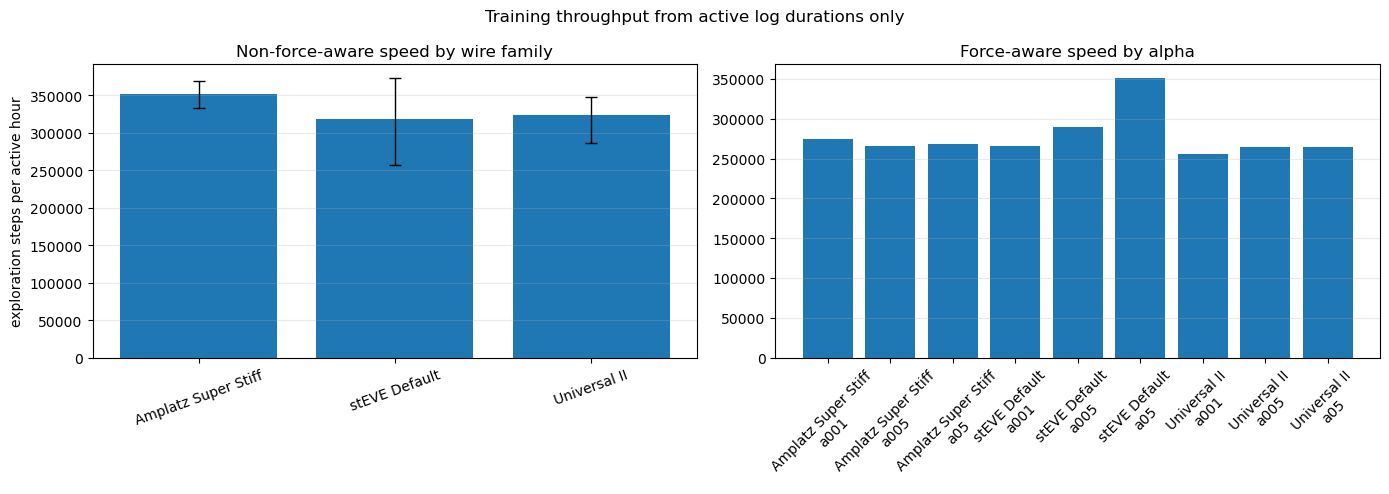

In [ ]:
speed_plot_df = training_speed_df.copy()
speed_plot_df["agent_group"] = speed_plot_df.apply(
    lambda row: f"{WIRE_LABELS.get(row['wire_model'], row['wire_model'])}\n{row['wire_variant']}" 
    if row["training_family"] == "non_force_aware"
    else f"{WIRE_LABELS.get(row['wire_model'], row['wire_model'])}\nalpha={row['force_alpha']}",
    axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

non_force_speed = speed_plot_df[speed_plot_df["training_family"].eq("non_force_aware")].copy()
non_force_family_speed = (
    non_force_speed.groupby("wire_model", as_index=False)
    .agg(
        mean_steps_per_hour=("explore_steps_per_active_hour", "mean"),
        min_steps_per_hour=("explore_steps_per_active_hour", "min"),
        max_steps_per_hour=("explore_steps_per_active_hour", "max"),
    )
)

axes[0].bar(
    [WIRE_LABELS.get(wire, wire) for wire in non_force_family_speed["wire_model"]],
    non_force_family_speed["mean_steps_per_hour"],
)
axes[0].errorbar(
    [WIRE_LABELS.get(wire, wire) for wire in non_force_family_speed["wire_model"]],
    non_force_family_speed["mean_steps_per_hour"],
    yerr=[
        non_force_family_speed["mean_steps_per_hour"] - non_force_family_speed["min_steps_per_hour"],
        non_force_family_speed["max_steps_per_hour"] - non_force_family_speed["mean_steps_per_hour"],
    ],
    fmt="none",
    color="black",
    capsize=4,
    linewidth=1,
)
axes[0].set_title("Non-force-aware speed by wire family")
axes[0].set_ylabel("exploration steps per active hour")
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(True, axis="y", alpha=0.25)

force_speed = speed_plot_df[speed_plot_df["training_family"].eq("force_aware")].copy()
force_speed["label"] = force_speed["wire_model"].map(WIRE_LABELS).fillna(force_speed["wire_model"]) + "\n" + force_speed["force_alpha"].astype(str)
axes[1].bar(force_speed["label"], force_speed["explore_steps_per_active_hour"])
axes[1].set_title("Force-aware speed by alpha")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y", alpha=0.25)

fig.suptitle("Training throughput from active log durations only")
plt.tight_layout()
fig.savefig(FIGURE_DIR / "training_speed_active_time_summary.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURE_DIR / "training_speed_active_time_summary.pdf", bbox_inches="tight")
plt.show()


**Interpretation note.** These values are useful as sanity checks and as computational-cost context. They should not be over-interpreted as algorithmic performance, because throughput also depends on cluster node, resume structure, simulator speed, and evaluation workload. For the thesis, a short table or this supporting bar plot is likely enough.


## 4. Clean Generation of the DataFrames

This cell builds one slim per-trial DataFrame for each `(friction, config)` pair. Configs 2-4 should have about `15 wires x 1000 trials x 12 anatomies x 3 targets = 540000` rows per friction setting when all result files are available; config 1 is smaller because it has only one trial per anatomy-target-wire combination.


## 4.1 Cached Friction Comparison on Shared Anatomy-Target Pairs

This compares only anatomy-target pairs that exist for both friction settings. It avoids loading all trials at once: each run is read, immediately summarized to a small table, and then cached as CSV.

In [2]:
# Step 1: define the two friction folders and the cache files.

from pathlib import Path
import pandas as pd
from IPython.display import Markdown, display

if "PROJECT_ROOT" not in globals():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "notebooks" / "e1.ipynb").exists():
            PROJECT_ROOT = candidate.resolve()
            break
    else:
        raise FileNotFoundError("Could not locate the project root.")

E1_FRICTION_ROOTS = {
    "0.001": PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_0001_merged_plus_finished_115",
    "0.1": PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_friction_01_real",
}

E1_FRICTION_OUTPUT_DIR = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
E1_FRICTION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FRICTION_GROUP_CACHE_CSV = E1_FRICTION_OUTPUT_DIR / "e1_friction_group_cache.csv"
FRICTION_WIRE_COMPARISON_CSV = E1_FRICTION_OUTPUT_DIR / "e1_friction_shared_wire_target_comparison.csv"
FRICTION_TARGET_COMPARISON_CSV = E1_FRICTION_OUTPUT_DIR / "e1_friction_shared_anatomy_target_comparison.csv"
FRICTION_CONFIG_COMPARISON_CSV = E1_FRICTION_OUTPUT_DIR / "e1_friction_shared_config_summary.csv"

display(pd.DataFrame({"friction": E1_FRICTION_ROOTS.keys(), "folder": [str(path) for path in E1_FRICTION_ROOTS.values()]}))


,friction,folder
0,0.001,/home/hannes-deittert/dev/Uni/master-project/r...
1,0.1,/home/hannes-deittert/dev/Uni/master-project/r...


In [3]:
# Step 2: small helper functions.
# They read only the columns needed for this comparison and summarize one run at a time.

TRIAL_COLUMNS_NEEDED = [
    "execution_wire",
    "success",
    "steps_total",
    "wire_force_normal_trial_max_N",
]
EXPECTED_TRIALS_PER_WIRE = {1: 1, 2: 1000, 3: 1000, 4: 1000}


def config_id_from_run_dir(run_dir: Path) -> int:
    return int(run_dir.parent.name.replace("config_", ""))


def tree_target_from_run_dir(run_dir: Path) -> str:
    # Example folder: Tree_8547__target_0__seedbase_1223
    return run_dir.name.split("__seedbase_", maxsplit=1)[0]


def read_small_trial_table(csv_path: Path) -> pd.DataFrame:
    trials = pd.read_csv(csv_path, usecols=lambda column: column in TRIAL_COLUMNS_NEEDED)
    trials["execution_wire"] = trials["execution_wire"].astype(str)
    trials["steps_total"] = pd.to_numeric(trials["steps_total"], errors="coerce")
    trials["wire_force_normal_trial_max_N"] = pd.to_numeric(
        trials["wire_force_normal_trial_max_N"],
        errors="coerce",
    )

    success_text = trials["success"].astype(str).str.lower()
    trials["success_numeric"] = success_text.isin(["true", "1", "1.0"]).astype(float)
    return trials


def summarize_one_run(friction_label: str, manifest_path: Path):
    run_dir = manifest_path.parent
    csv_path = run_dir / "trials.csv"
    if not csv_path.exists():
        return None

    trials = read_small_trial_table(csv_path)
    if trials.empty:
        return None

    summary = (
        trials
        .groupby("execution_wire", dropna=False)
        .agg(
            n_trials=("success_numeric", "size"),
            success_rate=("success_numeric", "mean"),
            steps_mean=("steps_total", "mean"),
            steps_p95=("steps_total", lambda values: values.quantile(0.95)),
            normal_force_max_mean_N=("wire_force_normal_trial_max_N", "mean"),
            normal_force_max_p95_N=("wire_force_normal_trial_max_N", lambda values: values.quantile(0.95)),
            normal_force_max_max_N=("wire_force_normal_trial_max_N", "max"),
        )
        .reset_index()
    )

    summary.insert(0, "friction_label", friction_label)
    summary.insert(1, "config_id", config_id_from_run_dir(run_dir))
    summary.insert(2, "tree_target_combo", tree_target_from_run_dir(run_dir))
    summary["run_dir"] = str(run_dir)
    return summary


In [4]:
# Step 3: build the small cache, or load it if it already exists.
# Set rebuild_cache = True if the result folders changed.

rebuild_cache = False

if FRICTION_GROUP_CACHE_CSV.exists() and not rebuild_cache:
    friction_group_summary = pd.read_csv(FRICTION_GROUP_CACHE_CSV)
else:
    summaries = []
    skipped_runs = []

    for friction_label, result_root in E1_FRICTION_ROOTS.items():
        manifest_paths = sorted(result_root.rglob("manifest.json"))
        for manifest_path in manifest_paths:
            try:
                summary = summarize_one_run(friction_label, manifest_path)
            except Exception as exc:
                skipped_runs.append({
                    "friction_label": friction_label,
                    "manifest_path": str(manifest_path),
                    "error": f"{type(exc).__name__}: {exc}",
                })
                continue

            if summary is None:
                skipped_runs.append({
                    "friction_label": friction_label,
                    "manifest_path": str(manifest_path),
                    "error": "missing or empty trials.csv",
                })
            else:
                summaries.append(summary)

    if not summaries:
        raise RuntimeError("No readable trials.csv files were found for the friction comparison.")

    friction_group_summary = pd.concat(summaries, ignore_index=True)
    friction_group_summary.to_csv(FRICTION_GROUP_CACHE_CSV, index=False)
    skipped_runs = pd.DataFrame(skipped_runs)
    if not skipped_runs.empty:
        skipped_runs.to_csv(E1_FRICTION_OUTPUT_DIR / "e1_friction_group_cache_skipped_runs.csv", index=False)

friction_group_summary["config_id"] = pd.to_numeric(friction_group_summary["config_id"], errors="coerce").astype("Int64")
friction_group_summary["expected_trials_per_wire"] = friction_group_summary["config_id"].map(EXPECTED_TRIALS_PER_WIRE)
friction_group_summary["complete_group"] = friction_group_summary["n_trials"].eq(friction_group_summary["expected_trials_per_wire"])

display(Markdown(f"Loaded `{len(friction_group_summary):,}` small summary rows from `{FRICTION_GROUP_CACHE_CSV}`."))
display(
    friction_group_summary
    .groupby(["friction_label", "config_id"], dropna=False)
    .agg(
        wire_target_groups=("execution_wire", "size"),
        anatomy_targets=("tree_target_combo", "nunique"),
        complete_groups=("complete_group", "sum"),
    )
    .reset_index()
)


Loaded `4,005` small summary rows from `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_group_cache.csv`.

,friction_label,config_id,wire_target_groups,anatomy_targets,complete_groups
0,0.001,1,540,36,540
1,0.001,2,405,27,405
2,0.001,3,465,31,465
3,0.001,4,435,29,435
4,0.100,1,540,36,540
5,0.100,2,540,36,540
6,0.100,3,540,36,540
7,0.100,4,540,36,540


In [5]:
# Step 4: keep only anatomy-target/wire groups that exist for both frictions.

match_columns = ["config_id", "tree_target_combo", "execution_wire"]

friction_0001 = friction_group_summary.loc[
    friction_group_summary["friction_label"].astype(str).eq("0.001")
].drop(columns="friction_label")

friction_01 = friction_group_summary.loc[
    friction_group_summary["friction_label"].astype(str).eq("0.1")
].drop(columns="friction_label")

paired_friction_wire_comparison = friction_0001.merge(
    friction_01,
    on=match_columns,
    how="inner",
    suffixes=("_0001", "_01"),
)

paired_friction_wire_comparison["success_rate_delta_01_minus_0001"] = (
    paired_friction_wire_comparison["success_rate_01"]
    - paired_friction_wire_comparison["success_rate_0001"]
)
paired_friction_wire_comparison["steps_mean_delta_01_minus_0001"] = (
    paired_friction_wire_comparison["steps_mean_01"]
    - paired_friction_wire_comparison["steps_mean_0001"]
)
paired_friction_wire_comparison["normal_force_max_mean_delta_01_minus_0001_N"] = (
    paired_friction_wire_comparison["normal_force_max_mean_N_01"]
    - paired_friction_wire_comparison["normal_force_max_mean_N_0001"]
)
paired_friction_wire_comparison["normal_force_max_max_delta_01_minus_0001_N"] = (
    paired_friction_wire_comparison["normal_force_max_max_N_01"]
    - paired_friction_wire_comparison["normal_force_max_max_N_0001"]
)

paired_friction_wire_comparison.to_csv(FRICTION_WIRE_COMPARISON_CSV, index=False)

display(Markdown(f"Shared wire/anatomy-target groups: `{len(paired_friction_wire_comparison):,}`"))
display(paired_friction_wire_comparison.head(20).round(4))


Shared wire/anatomy-target groups: `1,845`

,config_id,tree_target_combo,execution_wire,n_trials_0001,success_rate_0001,steps_mean_0001,steps_p95_0001,normal_force_max_mean_N_0001,normal_force_max_p95_N_0001,normal_force_max_max_N_0001,...,normal_force_max_mean_N_01,normal_force_max_p95_N_01,normal_force_max_max_N_01,run_dir_01,expected_trials_per_wire_01,complete_group_01,success_rate_delta_01_minus_0001,steps_mean_delta_01_minus_0001,normal_force_max_mean_delta_01_minus_0001_N,normal_force_max_max_delta_01_minus_0001_N
0,1,Tree_1382__target_0,amplatz_super_stiff/gentle,1,1.0,473.0,473.0,0.8284,0.8284,0.8284,...,0.9851,0.9851,0.9851,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,-1.0,527.0,0.1566,0.1566
1,1,Tree_1382__target_0,amplatz_super_stiff/standard_j,1,1.0,85.0,85.0,0.3943,0.3943,0.3943,...,1.0987,1.0987,1.0987,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,-1.0,915.0,0.7044,0.7044
2,1,Tree_1382__target_0,amplatz_super_stiff/straight,1,0.0,1000.0,1000.0,9.1241,9.1241,9.1241,...,2.2645,2.2645,2.2645,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,0.0,0.0,-6.8596,-6.8596
3,1,Tree_1382__target_0,amplatz_super_stiff/strong_hook,1,1.0,123.0,123.0,0.4093,0.4093,0.4093,...,0.6213,0.6213,0.6213,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,0.0,592.0,0.2120,0.2120
4,1,Tree_1382__target_0,amplatz_super_stiff/tight_j,1,1.0,406.0,406.0,1.1938,1.1938,1.1938,...,0.6456,0.6456,0.6456,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,0.0,-65.0,-0.5482,-0.5482
5,1,Tree_1382__target_0,steve_default/gentle,1,0.0,204.0,204.0,7.3083,7.3083,7.3083,...,10.3359,10.3359,10.3359,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,1.0,161.0,3.0277,3.0277
6,1,Tree_1382__target_0,steve_default/standard_j,1,1.0,67.0,67.0,6.7607,6.7607,6.7607,...,8.0281,8.0281,8.0281,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,0.0,3.0,1.2674,1.2674
7,1,Tree_1382__target_0,steve_default/straight,1,0.0,1000.0,1000.0,8.2654,8.2654,8.2654,...,23.0946,23.0946,23.0946,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,0.0,0.0,14.8292,14.8292
8,1,Tree_1382__target_0,steve_default/strong_hook,1,1.0,102.0,102.0,10.6158,10.6158,10.6158,...,6.4172,6.4172,6.4172,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,-1.0,-47.0,-4.1986,-4.1986
9,1,Tree_1382__target_0,steve_default/tight_j,1,1.0,69.0,69.0,7.1898,7.1898,7.1898,...,14.4876,14.4876,14.4876,/home/hannes-deittert/dev/Uni/master-project/r...,1,True,0.0,1.0,7.2979,7.2979


In [6]:
# Step 5: average the wire-level comparison into target and config summaries.

paired_friction_target_summary = (
    paired_friction_wire_comparison
    .groupby(["config_id", "tree_target_combo"], dropna=False)
    .agg(
        common_wires=("execution_wire", "nunique"),
        complete_0001=("complete_group_0001", "all"),
        complete_01=("complete_group_01", "all"),
        success_rate_0001_mean=("success_rate_0001", "mean"),
        success_rate_01_mean=("success_rate_01", "mean"),
        success_rate_delta_01_minus_0001_mean=("success_rate_delta_01_minus_0001", "mean"),
        steps_mean_0001=("steps_mean_0001", "mean"),
        steps_mean_01=("steps_mean_01", "mean"),
        steps_mean_delta_01_minus_0001=("steps_mean_delta_01_minus_0001", "mean"),
        normal_force_max_mean_0001_N=("normal_force_max_mean_N_0001", "mean"),
        normal_force_max_mean_01_N=("normal_force_max_mean_N_01", "mean"),
        normal_force_max_mean_delta_01_minus_0001_N=("normal_force_max_mean_delta_01_minus_0001_N", "mean"),
        normal_force_max_max_0001_N=("normal_force_max_max_N_0001", "max"),
        normal_force_max_max_01_N=("normal_force_max_max_N_01", "max"),
        normal_force_max_max_delta_01_minus_0001_N=("normal_force_max_max_delta_01_minus_0001_N", "mean"),
    )
    .reset_index()
    .sort_values(["config_id", "tree_target_combo"])
)

paired_friction_config_summary = (
    paired_friction_target_summary
    .groupby("config_id", dropna=False)
    .agg(
        shared_anatomy_targets=("tree_target_combo", "size"),
        mean_common_wires=("common_wires", "mean"),
        complete_targets_0001=("complete_0001", "sum"),
        complete_targets_01=("complete_01", "sum"),
        mean_success_rate_delta_01_minus_0001=("success_rate_delta_01_minus_0001_mean", "mean"),
        mean_steps_delta_01_minus_0001=("steps_mean_delta_01_minus_0001", "mean"),
        mean_normal_force_max_delta_01_minus_0001_N=("normal_force_max_mean_delta_01_minus_0001_N", "mean"),
    )
    .reset_index()
)

paired_friction_target_summary.to_csv(FRICTION_TARGET_COMPARISON_CSV, index=False)
paired_friction_config_summary.to_csv(FRICTION_CONFIG_COMPARISON_CSV, index=False)

display(Markdown("### Config summary"))
display(paired_friction_config_summary.round(4))

display(Markdown("### First anatomy-target rows"))
display(paired_friction_target_summary.head(20).round(4))


### Config summary

,config_id,shared_anatomy_targets,mean_common_wires,complete_targets_0001,complete_targets_01,mean_success_rate_delta_01_minus_0001,mean_steps_delta_01_minus_0001,mean_normal_force_max_delta_01_minus_0001_N
0,1,36,15.0,36,36,-0.0000,6.6278,0.7115
1,2,27,15.0,27,27,0.0039,6.0947,0.6309
2,3,31,15.0,31,31,-0.0055,10.6240,0.6751
3,4,29,15.0,29,29,-0.0102,14.1283,0.6511


### First anatomy-target rows

,config_id,tree_target_combo,common_wires,complete_0001,complete_01,success_rate_0001_mean,success_rate_01_mean,success_rate_delta_01_minus_0001_mean,steps_mean_0001,steps_mean_01,steps_mean_delta_01_minus_0001,normal_force_max_mean_0001_N,normal_force_max_mean_01_N,normal_force_max_mean_delta_01_minus_0001_N,normal_force_max_max_0001_N,normal_force_max_max_01_N,normal_force_max_max_delta_01_minus_0001_N
0,1,Tree_1382__target_0,15,True,True,0.6667,0.5333,-0.1333,387.6000,581.2000,193.6000,3.5011,4.5978,1.0967,10.6158,23.0946,1.0967
1,1,Tree_1382__target_1,15,True,True,0.6667,0.8667,0.2000,391.6667,341.3333,-50.3333,2.2323,2.2463,0.0140,9.1678,10.7457,0.0140
2,1,Tree_1382__target_2,15,True,True,0.2000,0.1333,-0.0667,682.9333,755.1333,72.2000,3.0701,3.7339,0.6638,13.7421,19.1903,0.6638
3,1,Tree_1882__target_0,15,True,True,0.6000,0.7333,0.1333,490.8667,472.5333,-18.3333,2.1759,2.8231,0.6473,9.7868,13.5248,0.6473
4,1,Tree_1882__target_1,15,True,True,0.8000,0.6667,-0.1333,335.6000,401.3333,65.7333,3.8084,5.4790,1.6707,21.7356,23.0040,1.6707
5,1,Tree_1882__target_2,15,True,True,0.9333,0.8667,-0.0667,206.0667,272.5333,66.4667,2.0598,2.5881,0.5283,11.7524,13.9308,0.5283
6,1,Tree_1996__target_0,15,True,True,0.4667,0.4667,0.0000,615.7333,571.8000,-43.9333,3.8392,5.0307,1.1915,13.4919,22.4369,1.1915
7,1,Tree_1996__target_1,15,True,True,0.1333,0.3333,0.2000,751.5333,663.4000,-88.1333,2.6312,3.8260,1.1948,11.5664,20.0618,1.1948
8,1,Tree_1996__target_2,15,True,True,1.0000,1.0000,0.0000,75.2667,71.9333,-3.3333,1.8376,1.7922,-0.0454,11.9586,11.1868,-0.0454
9,1,Tree_5348__target_0,15,True,True,1.0000,1.0000,0.0000,56.8667,61.6000,4.7333,1.1649,1.5549,0.3900,7.5966,10.3613,0.3900


In [7]:
# Step 6: bootstrap the shared anatomy-target rows 1000 times.
# The confidence interval is computed from the 2.5% and 97.5% bootstrap percentiles.

import numpy as np

BOOTSTRAP_ROUNDS = 1000
BOOTSTRAP_RANDOM_SEED = 20260602
FRICTION_BOOTSTRAP_CI_CSV = E1_FRICTION_OUTPUT_DIR / "e1_friction_shared_bootstrap_1000_ci.csv"

bootstrap_metrics = [
    "success_rate_0001_mean",
    "success_rate_01_mean",
    "success_rate_delta_01_minus_0001_mean",
    "steps_mean_0001",
    "steps_mean_01",
    "steps_mean_delta_01_minus_0001",
    "normal_force_max_mean_0001_N",
    "normal_force_max_mean_01_N",
    "normal_force_max_mean_delta_01_minus_0001_N",
    "normal_force_max_max_0001_N",
    "normal_force_max_max_01_N",
    "normal_force_max_max_delta_01_minus_0001_N",
]


def bootstrap_mean_ci(values, *, rounds=BOOTSTRAP_ROUNDS, seed=BOOTSTRAP_RANDOM_SEED):
    values = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy(dtype=float)
    if len(values) == 0:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    bootstrap_means = np.empty(rounds, dtype=float)
    for index in range(rounds):
        sample = rng.choice(values, size=len(values), replace=True)
        bootstrap_means[index] = sample.mean()

    observed_mean = values.mean()
    ci_low, ci_high = np.percentile(bootstrap_means, [2.5, 97.5])
    return observed_mean, ci_low, ci_high


def bootstrap_metric_table(source_df, *, group_label, config_id):
    rows = []
    for metric in bootstrap_metrics:
        observed_mean, ci_low, ci_high = bootstrap_mean_ci(source_df[metric])
        rows.append({
            "group_label": group_label,
            "config_id": config_id,
            "n_shared_anatomy_targets": len(source_df),
            "bootstrap_rounds": BOOTSTRAP_ROUNDS,
            "metric": metric,
            "observed_mean": observed_mean,
            "ci_low_95": ci_low,
            "ci_high_95": ci_high,
        })
    return rows

bootstrap_rows = []

for config_id, config_df in paired_friction_target_summary.groupby("config_id", dropna=False):
    bootstrap_rows.extend(
        bootstrap_metric_table(
            config_df,
            group_label=f"config_{config_id}",
            config_id=config_id,
        )
    )

bootstrap_rows.extend(
    bootstrap_metric_table(
        paired_friction_target_summary,
        group_label="all_configs",
        config_id="all",
    )
)

paired_friction_bootstrap_ci = pd.DataFrame(bootstrap_rows)
paired_friction_bootstrap_ci.to_csv(FRICTION_BOOTSTRAP_CI_CSV, index=False)

# These are the main friction differences: 0.1 minus 0.001.
paired_friction_bootstrap_delta_ci = paired_friction_bootstrap_ci[
    paired_friction_bootstrap_ci["metric"].str.contains("delta")
].copy()

display(Markdown(f"### Bootstrap 95% confidence intervals ({BOOTSTRAP_ROUNDS:,} rounds)"))
display(Markdown(f"Saved the full table to `{FRICTION_BOOTSTRAP_CI_CSV}`."))
display(Markdown("Main difference metrics below are `0.1 - 0.001`."))
display(paired_friction_bootstrap_delta_ci.round(4))


### Bootstrap 95% confidence intervals (1,000 rounds)

Saved the full table to `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_shared_bootstrap_1000_ci.csv`.

Main difference metrics below are `0.1 - 0.001`.

,group_label,config_id,n_shared_anatomy_targets,bootstrap_rounds,metric,observed_mean,ci_low_95,ci_high_95
2,config_1,1,36,1000,success_rate_delta_01_minus_0001_mean,0.0000,-0.0315,0.0333
5,config_1,1,36,1000,steps_mean_delta_01_minus_0001,6.6278,-17.3245,31.5454
8,config_1,1,36,1000,normal_force_max_mean_delta_01_minus_0001_N,0.7115,0.4529,1.0108
11,config_1,1,36,1000,normal_force_max_max_delta_01_minus_0001_N,0.7115,0.4529,1.0108
14,config_2,2,27,1000,success_rate_delta_01_minus_0001_mean,0.0039,-0.0176,0.0275
17,config_2,2,27,1000,steps_mean_delta_01_minus_0001,6.0947,-6.1901,18.4770
20,config_2,2,27,1000,normal_force_max_mean_delta_01_minus_0001_N,0.6309,0.4910,0.7694
23,config_2,2,27,1000,normal_force_max_max_delta_01_minus_0001_N,1.3643,1.0139,1.7232
26,config_3,3,31,1000,success_rate_delta_01_minus_0001_mean,-0.0055,-0.0200,0.0086
29,config_3,3,31,1000,steps_mean_delta_01_minus_0001,10.6240,-0.3267,22.8431


In [8]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, display

if "PROJECT_ROOT" not in globals():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1_analysis.py"
        if helper.exists():
            PROJECT_ROOT = candidate.resolve()
            break
    else:
        raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")

HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for path in (PROJECT_ROOT, HELPER_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

if "load_e1_result_rows" not in globals():
    from e1_analysis import load_e1_result_rows


E1_RESULT_ROOTS = {
    "0.001": PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_0001_merged_plus_finished_115",
    "0.1": PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_friction_01_real",
}


def _coerce_numeric(df: pd.DataFrame, columns) -> pd.DataFrame:
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


trial_rows_all = []

for friction_label, result_root in E1_RESULT_ROOTS.items():
    _, _, trial_rows = load_e1_result_rows(result_root)
    for row in trial_rows:
        item = dict(row)
        item["friction_label"] = str(friction_label)
        trial_rows_all.append(item)

_trial_df = pd.DataFrame(trial_rows_all)

_trial_df = _coerce_numeric(
    _trial_df,
    [
        "config_id",
        "target_index",
        "trial_index",
        "score_total",
        "steps_total",
        "wire_force_normal_trial_max_N",
        "wire_force_normal_trial_mean_N",
        "wire_force_magnitude_trial_mean_N",
        "tip_force_normal_trial_max_N",
    ],
)

if "run_dir" in _trial_df.columns:
    _trial_df["tree_target_combo"] = _trial_df["run_dir"].map(lambda value: Path(str(value)).name if pd.notna(value) else "")
else:
    _trial_df["tree_target_combo"] = (
        "Tree_" + _trial_df["anatomy_id"].astype(str)
        + "__target_" + _trial_df["target_index"].astype("Int64").astype(str)
    )

if "wire_force_normal_magnitude_trial_mean_N" not in _trial_df.columns:
    if "wire_force_magnitude_trial_mean_N" in _trial_df.columns:
        _trial_df["wire_force_normal_magnitude_trial_mean_N"] = _trial_df["wire_force_magnitude_trial_mean_N"]
    elif "wire_force_normal_trial_mean_N" in _trial_df.columns:
        _trial_df["wire_force_normal_magnitude_trial_mean_N"] = _trial_df["wire_force_normal_trial_mean_N"]
    else:
        _trial_df["wire_force_normal_magnitude_trial_mean_N"] = pd.NA


def _select_existing(df: pd.DataFrame, columns) -> pd.DataFrame:
    return df[[column for column in columns if column in df.columns]].copy()


CONFIG_TRIAL_COLUMNS = [
    "execution_wire",
    "tree_target_combo",
    "valid_for_ranking",
    "success",
    "steps_total",
    "tip_force_normal_trial_max_N",
    "wire_force_normal_magnitude_trial_mean_N",
    "wire_force_normal_trial_max_N",
]

config_trial_dfs = {}
config_trial_names = {}
for friction_label in sorted(_trial_df["friction_label"].dropna().unique(), key=float):
    friction_key = "f0001" if friction_label == "0.001" else "f01" if friction_label == "0.1" else "f" + str(friction_label).replace(".", "")
    friction_subset = _trial_df.loc[_trial_df["friction_label"] == friction_label]
    for config_id in sorted(friction_subset["config_id"].dropna().astype(int).unique()):
        config_subset = friction_subset.loc[friction_subset["config_id"] == config_id].copy()
        sort_columns = [column for column in ["tree_target_combo", "execution_wire", "trial_index"] if column in config_subset.columns]
        config_subset = config_subset.sort_values(sort_columns).reset_index(drop=True)
        slim_df = _select_existing(config_subset, CONFIG_TRIAL_COLUMNS)
        config_trial_dfs[(friction_label, int(config_id))] = slim_df
        dataframe_name = f"trial_cfg{int(config_id)}_{friction_key}_df"
        config_trial_names[(friction_label, int(config_id))] = dataframe_name
        globals()[dataframe_name] = slim_df

display(Markdown("### Per-config trial DataFrame stats"))
config_trial_stats_df = pd.DataFrame(
    [
        {
            "friction_label": friction_label,
            "config_id": config_id,
            "dataframe": config_trial_names[(friction_label, config_id)],
            "rows": len(df),
            "anatomy_target_combinations": df["tree_target_combo"].nunique() if "tree_target_combo" in df.columns else pd.NA,
            "columns": len(df.columns),
            "column_names": ", ".join(df.columns),
        }
        for (friction_label, config_id), df in config_trial_dfs.items()
    ]
).sort_values(["friction_label", "config_id"]).reset_index(drop=True)
display(config_trial_stats_df)

for (friction_label, config_id), df in sorted(config_trial_dfs.items(), key=lambda item: (float(item[0][0]), item[0][1])):
    name = config_trial_names[(friction_label, config_id)]
    display(Markdown(f"### {name} snippet"))
    display(df.head(5))


### Per-config trial DataFrame stats

,friction_label,config_id,dataframe,rows,anatomy_target_combinations,columns,column_names
0,0.001,1,trial_cfg1_f0001_df,540,36,8,"execution_wire, tree_target_combo, valid_for_r..."
1,0.001,2,trial_cfg2_f0001_df,432378,31,8,"execution_wire, tree_target_combo, valid_for_r..."
2,0.001,3,trial_cfg3_f0001_df,477184,33,8,"execution_wire, tree_target_combo, valid_for_r..."
3,0.001,4,trial_cfg4_f0001_df,472563,33,8,"execution_wire, tree_target_combo, valid_for_r..."
4,0.1,1,trial_cfg1_f01_df,540,36,8,"execution_wire, tree_target_combo, valid_for_r..."
5,0.1,2,trial_cfg2_f01_df,540000,36,8,"execution_wire, tree_target_combo, valid_for_r..."
6,0.1,3,trial_cfg3_f01_df,540000,36,8,"execution_wire, tree_target_combo, valid_for_r..."
7,0.1,4,trial_cfg4_f01_df,540000,36,8,"execution_wire, tree_target_combo, valid_for_r..."


### trial_cfg1_f0001_df snippet

,execution_wire,tree_target_combo,valid_for_ranking,success,steps_total,tip_force_normal_trial_max_N,wire_force_normal_magnitude_trial_mean_N,wire_force_normal_trial_max_N
0,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,True,True,473,0.239140,0.053595,0.828428
1,amplatz_super_stiff/standard_j,Tree_1382__target_0__seedbase_223,True,True,85,0.277022,0.077232,0.394290
2,amplatz_super_stiff/straight,Tree_1382__target_0__seedbase_223,False,False,1000,9.124074,0.097052,9.124074
3,amplatz_super_stiff/strong_hook,Tree_1382__target_0__seedbase_223,True,True,123,0.238829,0.063907,0.409312
4,amplatz_super_stiff/tight_j,Tree_1382__target_0__seedbase_223,True,True,406,0.242157,0.065623,1.193803


### trial_cfg2_f0001_df snippet

...

,execution_wire,tree_target_combo,valid_for_ranking,success,steps_total,tip_force_normal_trial_max_N,wire_force_normal_magnitude_trial_mean_N,wire_force_normal_trial_max_N
0,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.985068,0.035668,0.985068
1,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.139905,0.042091,0.490913
2,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.091531,0.042724,0.738234
3,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.316261,0.044626,0.548631
4,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.167686,0.040031,0.897859


### trial_cfg3_f01_df snippet

,execution_wire,tree_target_combo,valid_for_ranking,success,steps_total,tip_force_normal_trial_max_N,wire_force_normal_magnitude_trial_mean_N,wire_force_normal_trial_max_N
0,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,True,True,136,0.297351,0.061549,0.675110
1,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.222849,0.039816,0.502643
2,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.450003,0.043945,0.467055
3,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.098747,0.041976,0.708911
4,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,True,True,915,0.318141,0.046492,0.584220


### trial_cfg4_f01_df snippet

,execution_wire,tree_target_combo,valid_for_ranking,success,steps_total,tip_force_normal_trial_max_N,wire_force_normal_magnitude_trial_mean_N,wire_force_normal_trial_max_N
0,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,True,True,136,0.297351,0.061549,0.675110
1,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,True,True,855,0.271208,0.049858,1.291256
2,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,False,False,1000,0.324157,0.041674,0.589586
3,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,True,True,923,0.306836,0.043661,0.579361
4,amplatz_super_stiff/gentle,Tree_1382__target_0__seedbase_223,True,True,336,0.854452,0.057792,0.854452


## 1. Friction = 0.1 Analysis


1.1 Steps to success per configuration

This analysis uses only the `0.1` friction result tables (`trial_cfg1_f01_df` to `trial_cfg4_f01_df`). For each configuration, every row is one trial of one wire in one anatomy-target combination.

The analysis filters to successful trials only:

- include a row if `success == True`
- use `steps_total` as the number of simulation steps needed until the target was reached
- failed trials are excluded from the distribution because their `steps_total` represents the episode limit, not a real time-to-success

For each configuration, the plot shows the empirical density of `steps_total` for successful trials. The line is computed by binning `steps_total` into 10-step bins from `0` to `1000`, normalizing the bin counts to density, and drawing the bin centers as a line. This gives a distribution-like view without using a bar chart.

The CSV/table summarizes the same successful-trial `steps_total` values per configuration:

- `mean_steps_total`: average number of steps among successful trials
- `p95_steps_total`: 95th percentile, meaning 95% of successful trials reached the target in this many steps or fewer
- `p99_steps_total`: 99th percentile
- `min_steps_total`: fastest successful trial
- `max_steps_total`: slowest successful trial


Saved steps CSV: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_steps_to_success_summary.csv`

Saved steps plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_steps_to_success_distribution.png`

Saved cumulative steps plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_steps_to_success_ecdf.png`

### Steps to success summary table

,config_id,n_trials,n_success_trials,success_rate,mean_steps_total,p95_steps_total,p99_steps_total,min_steps_total,max_steps_total
0,1,540,358,0.663,143.27,443.15,843.66,36,935
1,2,540000,362787,0.672,143.00,476.00,822.00,35,1000
2,3,540000,386370,0.716,140.36,455.00,831.00,37,1000
3,4,540000,385897,0.715,139.37,453.00,828.00,37,1000


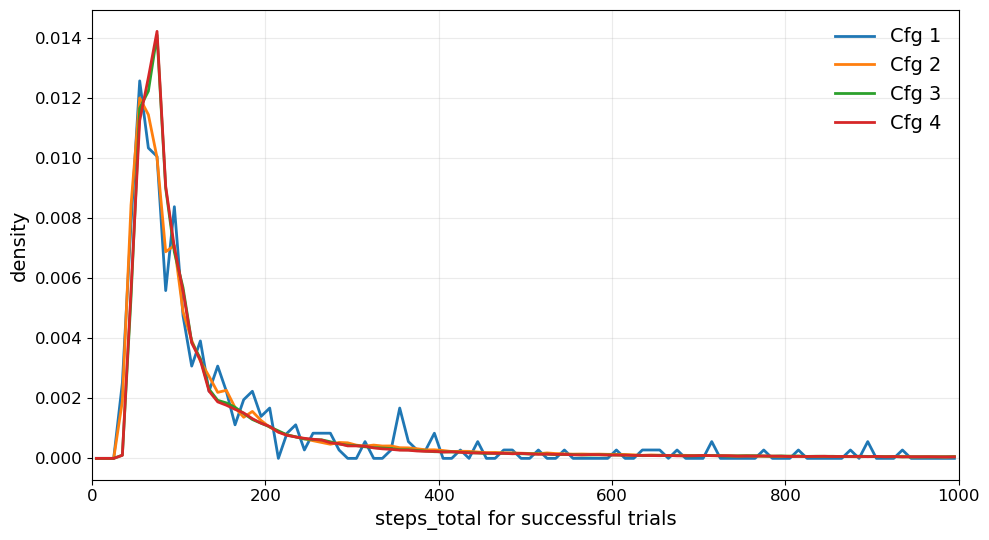

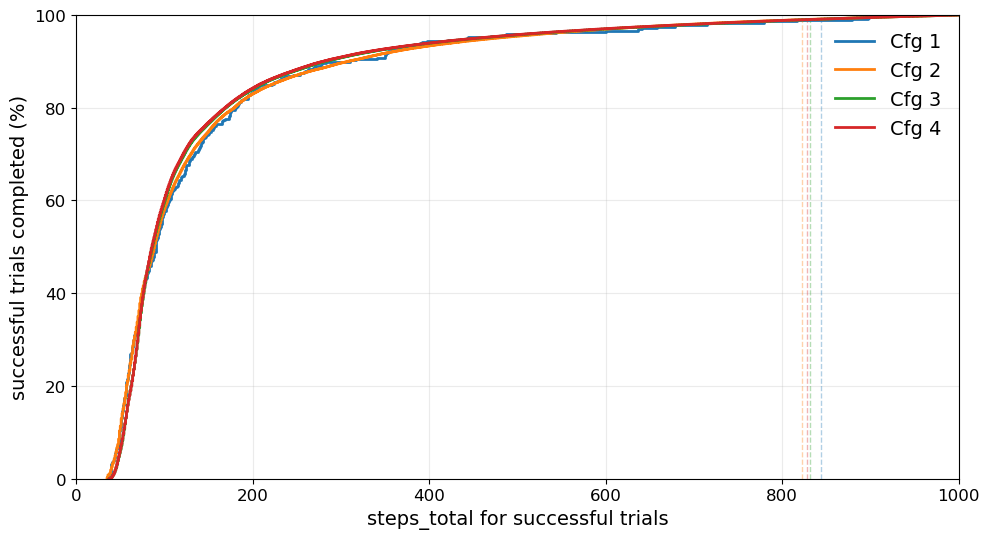

In [9]:
import numpy as np
import matplotlib.pyplot as plt

required_tables = ["trial_cfg1_f01_df", "trial_cfg2_f01_df", "trial_cfg3_f01_df", "trial_cfg4_f01_df"]
missing_tables = [name for name in required_tables if name not in globals()]

if missing_tables:
    display(Markdown("Run the per-config DataFrame generation cell above first. Missing: `" + "`, `".join(missing_tables) + "`."))
else:
    steps_by_config_01 = {
        1: trial_cfg1_f01_df,
        2: trial_cfg2_f01_df,
        3: trial_cfg3_f01_df,
        4: trial_cfg4_f01_df,
    }
    summary_rows = []
    success_steps_by_config = {}
    fig, ax = plt.subplots(figsize=(10, 5.5))
    bins = np.arange(0, 1001, 10)

    for config_id, df in steps_by_config_01.items():
        success_mask = df["success"].map({True: True, False: False, "true": True, "false": False, "True": True, "False": False})
        success_mask = success_mask.fillna(df["success"].astype(bool))
        success_steps = pd.to_numeric(df.loc[success_mask, "steps_total"], errors="coerce").dropna()
        success_rate = success_mask.mean()

        summary_rows.append(
            {
                "config_id": config_id,
                "n_trials": int(len(df)),
                "n_success_trials": int(success_steps.size),
                "success_rate": success_rate,
                "mean_steps_total": success_steps.mean(),
                "p95_steps_total": success_steps.quantile(0.95),
                "p99_steps_total": success_steps.quantile(0.99),
                "min_steps_total": success_steps.min(),
                "max_steps_total": success_steps.max(),
            }
        )

        success_steps_by_config[config_id] = success_steps.sort_values().to_numpy(dtype=float)

        if not success_steps.empty:
            density, edges = np.histogram(success_steps, bins=bins, density=True)
            centers = (edges[:-1] + edges[1:]) / 2
            ax.plot(centers, density, linewidth=2, label=f"Cfg {config_id}")

    steps_success_summary_01_df = pd.DataFrame(summary_rows)
    steps_success_summary_01_df["success_rate"] = steps_success_summary_01_df["success_rate"].round(3)
    step_value_columns = ["mean_steps_total", "p95_steps_total", "p99_steps_total", "min_steps_total", "max_steps_total"]
    steps_success_summary_01_df[step_value_columns] = steps_success_summary_01_df[step_value_columns].round(2)
    output_dir = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
    output_dir.mkdir(parents=True, exist_ok=True)
    steps_summary_csv_01 = output_dir / "e1_friction_01_steps_to_success_summary.csv"
    steps_success_summary_01_df.to_csv(steps_summary_csv_01, index=False)

    ax.set_xlabel("steps_total for successful trials", fontsize=14)
    ax.set_ylabel("density", fontsize=14)
    ax.set_xlim(0, 1000)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=14, frameon=False)
    fig.tight_layout()

    steps_plot_path_01 = output_dir / "e1_friction_01_steps_to_success_distribution.png"
    fig.savefig(steps_plot_path_01, dpi=200, bbox_inches="tight")

    fig_ecdf, ax_ecdf = plt.subplots(figsize=(10, 5.5))
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for idx, (config_id, values) in enumerate(success_steps_by_config.items()):
        if values.size == 0:
            continue
        color = color_cycle[idx % len(color_cycle)]
        completed_pct = 100.0 * np.arange(1, values.size + 1) / values.size
        ax_ecdf.step(values, completed_pct, where="post", linewidth=2, color=color, label=f"Cfg {config_id}")
        p99_step = float(steps_success_summary_01_df.loc[steps_success_summary_01_df["config_id"] == config_id, "p99_steps_total"].iloc[0])
        ax_ecdf.axvline(p99_step, color=color, linestyle="--", linewidth=1, alpha=0.35)
    ax_ecdf.set_xlabel("steps_total for successful trials", fontsize=14)
    ax_ecdf.set_ylabel("successful trials completed (%)", fontsize=14)
    ax_ecdf.set_xlim(0, 1000)
    ax_ecdf.set_ylim(0, 100)
    ax_ecdf.tick_params(axis="both", labelsize=12)
    ax_ecdf.grid(alpha=0.25)
    ax_ecdf.legend(fontsize=14, frameon=False)
    fig_ecdf.tight_layout()

    steps_ecdf_plot_path_01 = output_dir / "e1_friction_01_steps_to_success_ecdf.png"
    fig_ecdf.savefig(steps_ecdf_plot_path_01, dpi=200, bbox_inches="tight")

    display(Markdown(f"Saved steps CSV: `{steps_summary_csv_01}`"))
    display(Markdown(f"Saved steps plot: `{steps_plot_path_01}`"))
    display(Markdown(f"Saved cumulative steps plot: `{steps_ecdf_plot_path_01}`"))
    display(Markdown("### Steps to success summary table"))
    display(steps_success_summary_01_df)


### 1.1 Results:

We see a heavy one sided distribution with 95% of the reached targets within around 450 steps. We want to not disable the possibility of the agent to revert mistakes or work there way to targets further away, so using p99_steps_total per Config for the following score experiments is chosen.


## 1.2 Determine target CI half-width from rank gaps

Before choosing the optimal bootstrap trial number `k`, we need a meaningful uncertainty target. The target should be connected to the actual score resolution needed to separate neighboring wires.

For each config and each of the 36 anatomy-target combinations, this section:

1. Computes the calibrated k=1000 wire score for all 15 wires.
2. Sorts wires by score within each anatomy-target combination.
3. Computes the 14 adjacent rank gaps: rank 1 -> 2, rank 2 -> 3, ..., rank 14 -> 15.
4. Summarizes the rank-gap distribution with median, p25, p75, p10, and p90.
5. Builds a rank-position matrix and plots median adjacent gap per rank position.

The step-normalization mode is controlled by `STEP_NORMALIZATION_MODE` in the code cell. Available options are:

- `"p99_budget"`: current method, using the config-specific p99 step budget from section 1.1.
- `"condition_minmax"`: condition-specific min-max normalization with `steps_score = (steps_max_in_condition - steps_total) / (steps_max_in_condition - steps_min_in_condition)`, where the condition is `config_id + tree_target_combo`.

The CI target used in section 1.3 is derived from the score gaps. If two neighboring wire scores differ by `gap`, then a simple non-overlap rule requires roughly `gap > 2 * CI_half_width`. Therefore this notebook sets:

`TARGET_CI_HALF_WIDTH = p25(adjacent_rank_gap) / 2`

This is conservative relative to the median gap, because it targets the lower quartile of observed neighboring rank differences.


/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saved wire scores: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_wire_score_k1000.csv`

Saved rank gaps: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_adjacent_rank_gaps.csv`

Saved rank-gap summary: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_rank_gap_summary.csv`

Saved rank-gap by-position table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_rank_gap_by_position.csv`

...

,scope,gap_quantile_used,gap_value,target_ci_half_width,rule
0,all_configs,p25_gap,0.0,0.0,target_ci_half_width = p25_gap / 2


### Rank-gap distribution summary per config

,config_id,n_gaps,median_gap,p25_gap,p75_gap,p10_gap,p90_gap
0,1,504,0.000082,0.0,0.023790,0.0,0.129536
1,2,504,0.006058,0.0,0.051216,0.0,0.229859
2,3,504,0.007997,0.0,0.058032,0.0,0.220605
3,4,504,0.005949,0.0,0.057580,0.0,0.227409


### Rank-gap median/IQR by rank position

,config_id,rank_position,median_gap,p25_gap,p75_gap,iqr_gap
0,1,1,0.010770,0.001488,0.024795,0.023307
1,1,2,0.009655,0.001275,0.026344,0.025069
2,1,3,0.011347,0.006369,0.025623,0.019255
3,1,4,0.011816,0.001379,0.040696,0.039317
4,1,5,0.012397,0.001262,0.056820,0.055558
5,1,6,0.009581,0.000000,0.041418,0.041418
6,1,7,0.028906,0.000000,0.186017,0.186017
7,1,8,0.000000,0.000000,0.062882,0.062882
8,1,9,0.000000,0.000000,0.030666,0.030666
9,1,10,0.000000,0.000000,0.000000,0.000000


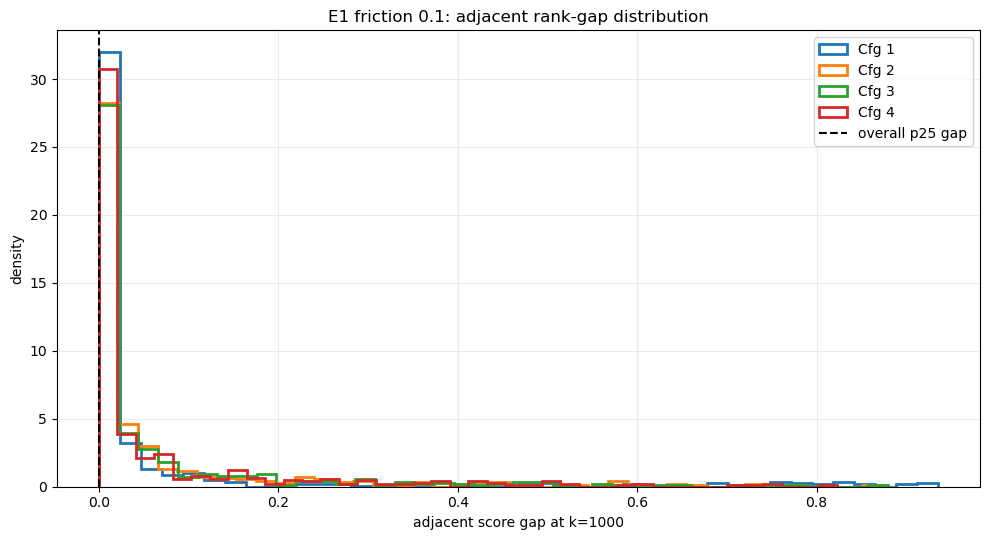

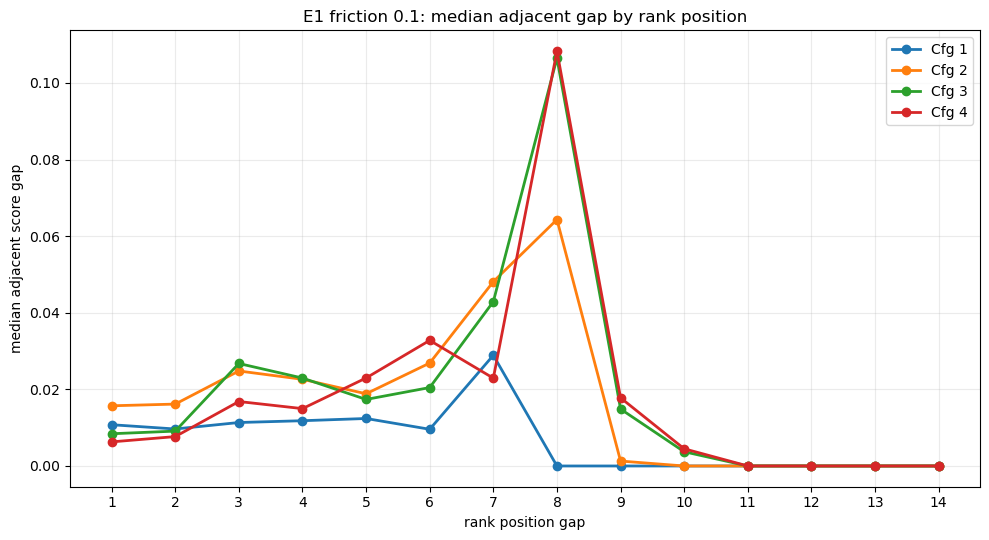

In [10]:
import numpy as np
import matplotlib.pyplot as plt

required_tables = ["_trial_df"]
missing_tables = [name for name in required_tables if name not in globals()]

if missing_tables:
    display(Markdown("Run the per-config DataFrame generation cell above first. Missing: `" + "`, `".join(missing_tables) + "`."))
else:
    FORCE_LIMIT_N = 2.0
    STEP_NORMALIZATION_MODE = "condition_minmax"  # options: "p99_budget", "condition_minmax"
    STEP_MINMAX_CONDITION_COLUMNS = ["config_id", "tree_target_combo"]
    if STEP_NORMALIZATION_MODE not in {"p99_budget", "condition_minmax"}:
        raise ValueError(f"Unknown STEP_NORMALIZATION_MODE: {STEP_NORMALIZATION_MODE}")
    output_dir = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
    output_dir.mkdir(parents=True, exist_ok=True)

    def _success_numeric_01(series):
        mapped = series.map({True: 1.0, False: 0.0, "true": 1.0, "false": 0.0, "True": 1.0, "False": 0.0})
        return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0.0)

    def _safety_score_01(force_n):
        force = pd.to_numeric(force_n, errors="coerce").clip(lower=0)
        c = 0.30
        p = 2.0
        k = 10.0
        f50 = 1.55
        fmax = FORCE_LIMIT_N
        g = 1.0 / (1.0 + np.exp(k * (force - f50)))
        g0 = 1.0 / (1.0 + np.exp(k * (0.0 - f50)))
        gmax = 1.0 / (1.0 + np.exp(k * (fmax - f50)))
        logistic_part = ((g - gmax) / (g0 - gmax)).clip(0, 1)
        polynomial_part = (1.0 - c * np.power(force, p)).clip(0, 1)
        return (logistic_part * polynomial_part).clip(0, 1)

    score_source_01 = _trial_df.loc[_trial_df["friction_label"] == "0.1"].copy()
    score_source_01["success_numeric"] = _success_numeric_01(score_source_01["success"])
    score_source_01["steps_total"] = pd.to_numeric(score_source_01["steps_total"], errors="coerce")
    score_source_01["wire_force_normal_trial_max_N"] = pd.to_numeric(score_source_01["wire_force_normal_trial_max_N"], errors="coerce")

    step_budget_by_config = (
        score_source_01.loc[score_source_01["success_numeric"] == 1.0]
        .groupby("config_id")["steps_total"]
        .quantile(0.99)
        .to_dict()
    )

    calibrated_parts = []
    for config_id, config_df in score_source_01.groupby("config_id", dropna=False):
        step_budget = float(step_budget_by_config.get(config_id, config_df["steps_total"].max()))
        part = config_df.copy()
        part["step_budget_p99"] = step_budget
        part["step_normalization_mode"] = STEP_NORMALIZATION_MODE
        if STEP_NORMALIZATION_MODE == "p99_budget":
            denom = max(step_budget - 1.0, 1.0)
            part["steps_min_in_condition"] = 1.0
            part["steps_max_in_condition"] = step_budget
            part["score_efficiency_calibrated"] = (1.0 - ((part["steps_total"] - 1.0) / denom)).clip(0, 1)
        else:
            part["steps_min_in_condition"] = part.groupby(STEP_MINMAX_CONDITION_COLUMNS)["steps_total"].transform("min")
            part["steps_max_in_condition"] = part.groupby(STEP_MINMAX_CONDITION_COLUMNS)["steps_total"].transform("max")
            denom = (part["steps_max_in_condition"] - part["steps_min_in_condition"]).replace(0, np.nan)
            part["score_efficiency_calibrated"] = ((part["steps_max_in_condition"] - part["steps_total"]) / denom).fillna(1.0).clip(0, 1)
        part.loc[part["success_numeric"] < 1.0, "score_efficiency_calibrated"] = 0.0
        part["score_safety_calibrated"] = _safety_score_01(part["wire_force_normal_trial_max_N"])
        part["within_step_budget_p99"] = part["steps_total"] <= part["step_budget_p99"]
        part["valid_for_calibrated_score"] = (part["success_numeric"] == 1.0) & part["within_step_budget_p99"] & (part["wire_force_normal_trial_max_N"] <= FORCE_LIMIT_N)
        part["trial_score_calibrated"] = 0.5 * part["score_efficiency_calibrated"] + 0.5 * part["score_safety_calibrated"]
        calibrated_parts.append(part)

    calibrated_trial_score_01_df = pd.concat(calibrated_parts, ignore_index=True)

    group_cols = ["config_id", "tree_target_combo", "execution_wire"]
    wire_score_rows = []
    for (config_id, tree_target_combo, execution_wire), group in calibrated_trial_score_01_df.groupby(group_cols, dropna=False):
        valid = group["valid_for_calibrated_score"].astype(bool)
        valid_rate = valid.mean()
        mean_valid_score = group.loc[valid, "trial_score_calibrated"].mean() if valid.any() else 0.0
        wire_score_rows.append(
            {
                "config_id": int(config_id),
                "tree_target_combo": tree_target_combo,
                "execution_wire": execution_wire,
                "n_trials": int(len(group)),
                "n_valid_trials": int(valid.sum()),
                "valid_rate": valid_rate,
                "mean_valid_trial_score": mean_valid_score,
                "wire_score_k1000": valid_rate * mean_valid_score,
            }
        )

    wire_score_k1000_01_df = pd.DataFrame(wire_score_rows)
    wire_score_ranked_01_df = (
        wire_score_k1000_01_df
        .sort_values(["config_id", "tree_target_combo", "wire_score_k1000"], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    wire_score_ranked_01_df["rank"] = wire_score_ranked_01_df.groupby(["config_id", "tree_target_combo"]).cumcount() + 1

    rank_gap_rows = []
    for (config_id, tree_target_combo), group in wire_score_ranked_01_df.groupby(["config_id", "tree_target_combo"], dropna=False):
        scores = group.sort_values("rank")["wire_score_k1000"].to_numpy(dtype=float)
        if len(scores) < 2:
            continue
        for idx, gap in enumerate(scores[:-1] - scores[1:], start=1):
            rank_gap_rows.append(
                {
                    "config_id": int(config_id),
                    "tree_target_combo": tree_target_combo,
                    "rank_position": idx,
                    "rank_pair": f"{idx}->{idx + 1}",
                    "adjacent_score_gap": float(gap),
                }
            )

    rank_gap_01_df = pd.DataFrame(rank_gap_rows)
    rank_gap_distribution_summary_01_df = (
        rank_gap_01_df
        .groupby("config_id", dropna=False)["adjacent_score_gap"]
        .agg(
            n_gaps="count",
            median_gap="median",
            p25_gap=lambda s: s.quantile(0.25),
            p75_gap=lambda s: s.quantile(0.75),
            p10_gap=lambda s: s.quantile(0.10),
            p90_gap=lambda s: s.quantile(0.90),
        )
        .reset_index()
    )

    overall_gap_summary = rank_gap_01_df["adjacent_score_gap"].agg(
        n_gaps="count",
        median_gap="median",
        p25_gap=lambda s: s.quantile(0.25),
        p75_gap=lambda s: s.quantile(0.75),
        p10_gap=lambda s: s.quantile(0.10),
        p90_gap=lambda s: s.quantile(0.90),
    )

    rank_gap_by_position_01_df = (
        rank_gap_01_df
        .groupby(["config_id", "rank_position"], dropna=False)["adjacent_score_gap"]
        .agg(
            median_gap="median",
            p25_gap=lambda s: s.quantile(0.25),
            p75_gap=lambda s: s.quantile(0.75),
        )
        .reset_index()
    )
    rank_gap_by_position_01_df["iqr_gap"] = rank_gap_by_position_01_df["p75_gap"] - rank_gap_by_position_01_df["p25_gap"]

    TARGET_CI_HALF_WIDTH = float(overall_gap_summary["p25_gap"] / 2.0)
    target_ci_half_width_01_df = pd.DataFrame(
        [
            {
                "scope": "all_configs",
                "gap_quantile_used": "p25_gap",
                "gap_value": overall_gap_summary["p25_gap"],
                "target_ci_half_width": TARGET_CI_HALF_WIDTH,
                "rule": "target_ci_half_width = p25_gap / 2",
            }
        ]
    )

    rank_gap_matrix_01_df = rank_gap_01_df.pivot_table(
        index=["config_id", "tree_target_combo"],
        columns="rank_position",
        values="adjacent_score_gap",
    ).reset_index()

    wire_score_k1000_csv_01 = output_dir / "e1_friction_01_wire_score_k1000.csv"
    rank_gap_csv_01 = output_dir / "e1_friction_01_adjacent_rank_gaps.csv"
    rank_gap_summary_csv_01 = output_dir / "e1_friction_01_rank_gap_summary.csv"
    rank_gap_by_position_csv_01 = output_dir / "e1_friction_01_rank_gap_by_position.csv"
    target_ci_half_width_csv_01 = output_dir / "e1_friction_01_target_ci_half_width.csv"
    wire_score_k1000_01_df.to_csv(wire_score_k1000_csv_01, index=False)
    rank_gap_01_df.to_csv(rank_gap_csv_01, index=False)
    rank_gap_distribution_summary_01_df.round(6).to_csv(rank_gap_summary_csv_01, index=False)
    rank_gap_by_position_01_df.round(6).to_csv(rank_gap_by_position_csv_01, index=False)
    target_ci_half_width_01_df.round(6).to_csv(target_ci_half_width_csv_01, index=False)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for config_id, group in rank_gap_01_df.groupby("config_id", dropna=False):
        ax.hist(group["adjacent_score_gap"], bins=40, histtype="step", density=True, linewidth=2, label=f"Cfg {int(config_id)}")
    ax.axvline(overall_gap_summary["p25_gap"], color="black", linestyle="--", linewidth=1.5, label="overall p25 gap")
    ax.set_xlabel("adjacent score gap at k=1000")
    ax.set_ylabel("density")
    ax.set_title("E1 friction 0.1: adjacent rank-gap distribution")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    rank_gap_hist_path_01 = output_dir / "e1_friction_01_rank_gap_histogram.png"
    fig.savefig(rank_gap_hist_path_01, dpi=200, bbox_inches="tight")

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for config_id, group in rank_gap_by_position_01_df.groupby("config_id", dropna=False):
        ax.plot(group["rank_position"], group["median_gap"], marker="o", linewidth=2, label=f"Cfg {int(config_id)}")
    ax.set_xlabel("rank position gap")
    ax.set_ylabel("median adjacent score gap")
    ax.set_title("E1 friction 0.1: median adjacent gap by rank position")
    ax.set_xticks(range(1, 15))
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    rank_gap_position_path_01 = output_dir / "e1_friction_01_rank_gap_by_position.png"
    fig.savefig(rank_gap_position_path_01, dpi=200, bbox_inches="tight")

    display(Markdown(f"Saved wire scores: `{wire_score_k1000_csv_01}`"))
    display(Markdown(f"Saved rank gaps: `{rank_gap_csv_01}`"))
    display(Markdown(f"Saved rank-gap summary: `{rank_gap_summary_csv_01}`"))
    display(Markdown(f"Saved rank-gap by-position table: `{rank_gap_by_position_csv_01}`"))
    display(Markdown(f"Saved target CI half-width table: `{target_ci_half_width_csv_01}`"))
    display(Markdown(f"Saved histogram: `{rank_gap_hist_path_01}`"))
    display(Markdown(f"Saved rank-position plot: `{rank_gap_position_path_01}`"))
    display(Markdown("### Target CI half-width used in 1.3"))
    display(target_ci_half_width_01_df.round(6))
    display(Markdown("### Rank-gap distribution summary per config"))
    display(rank_gap_distribution_summary_01_df.round(6))
    display(Markdown("### Rank-gap median/IQR by rank position"))
    display(rank_gap_by_position_01_df.round(6))




## 1.3 Define the optimal k per Config

The goal is to select the config with the best performance for evaluating the fittingness of a wire for a given anatomy, not how well the agent is optimized for one single anatomy. Before comparing configs, each config gets its own calibrated trial-level score and its own trial budget `k`.

Calculation performed here:

1. For each config, define the efficiency step budget as the `p99_steps_total` from section 1.1.
2. Recompute a config-specific efficiency score per trial: successful trials get `1 - (steps_total - 1) / (step_budget - 1)`, clipped to `[0, 1]`; failed trials get efficiency `0`.
3. Recompute the safety score from `wire_force_normal_trial_max_N` with the E1 force-normalization function and a hard validity limit of `2 N`.
4. Compute a calibrated trial score with equal weights: `trial_score = 0.5 * efficiency + 0.5 * safety`.
5. For every single `config / anatomy-target / execution_wire` group, bootstrap different `k` values from the available trials. In each bootstrap sample, calculate `experiment_score = valid_rate * mean(trial_score of valid trials)`, where valid means `success == True` and `wire_force_normal_trial_max_N <= 2 N`.
6. For every group and `k`, estimate the 95% bootstrap confidence interval. The config-level decision uses the p95 CI half-width across all wire/anatomy-target groups.

The selected `optimal_k` is the smallest `k` where `p95_ci_half_width <= TARGET_CI_HALF_WIDTH`. The threshold is explicit in the code so it can be changed for stricter or looser confidence requirements.



/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


Saved calibrated trial scores: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_calibrated_trial_scores.csv`

Saved bootstrap detail: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_k_bootstrap_detail.csv`

Saved k calibration summary: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_k_calibration_summary.csv`

Saved optimal k table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_optimal_k_by_config.csv`

...

,config_id,step_budget_p99
0,1,843.66
1,2,822.00
2,3,831.00
3,4,828.00


### Optimal k by config

,config_id,optimal_k,target_ci_half_width,p95_ci_half_width_at_optimal_k,median_ci_half_width_at_optimal_k,mean_bootstrap_score_at_optimal_k,target_reached
0,1,1,0.0,0.0000,0.0000,0.4297,True
1,2,1000,0.0,0.0241,0.0010,0.4452,False
2,3,1000,0.0,0.0239,0.0016,0.4651,False
3,4,1000,0.0,0.0234,0.0016,0.4665,False


### k calibration summary

,config_id,k,n_wire_anatomy_target_groups,mean_bootstrap_score,median_ci_half_width,p95_ci_half_width,max_ci_half_width
0,1,1,540,0.4297,0.0000,0.0000,0.0000
1,2,1,540,0.4452,0.0162,0.4925,0.4997
2,2,2,540,0.4455,0.0136,0.4751,0.4991
3,2,5,540,0.4451,0.0105,0.3223,0.4338
4,2,10,540,0.4450,0.0087,0.2342,0.2903
5,2,20,540,0.4450,0.0072,0.1684,0.2200
6,2,30,540,0.4451,0.0060,0.1357,0.1620
7,2,50,540,0.4453,0.0049,0.1076,0.1404
8,2,100,540,0.4452,0.0031,0.0760,0.0940
9,2,200,540,0.4451,0.0023,0.0534,0.0720


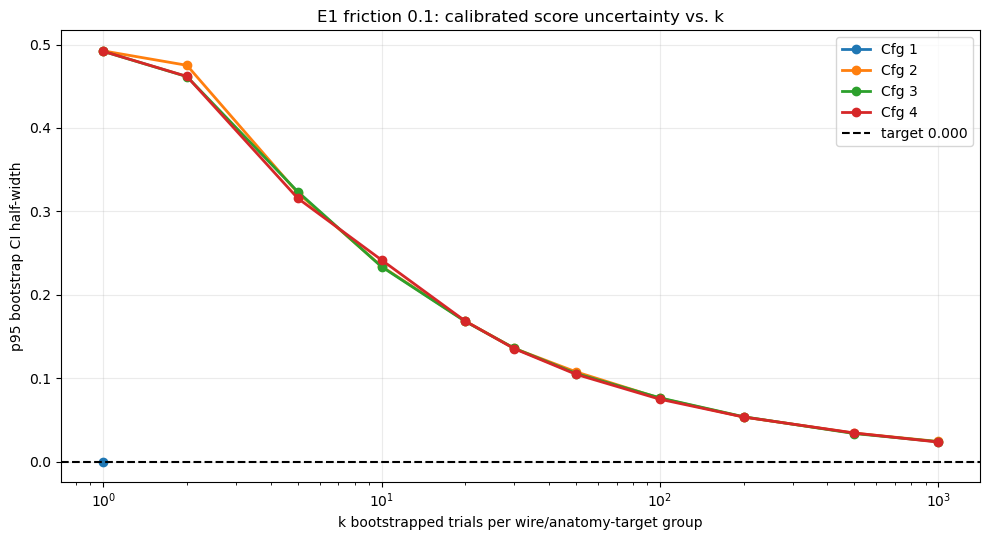

In [11]:
import numpy as np
import matplotlib.pyplot as plt

required_tables = ["_trial_df"]
missing_tables = [name for name in required_tables if name not in globals()]

if missing_tables:
    display(Markdown("Run the per-config DataFrame generation cell above first. Missing: `" + "`, `".join(missing_tables) + "`."))
else:
    if "TARGET_CI_HALF_WIDTH" not in globals():
        TARGET_CI_HALF_WIDTH = 0.02
    if "STEP_NORMALIZATION_MODE" not in globals():
        STEP_NORMALIZATION_MODE = "p99_budget"
    STEP_MINMAX_CONDITION_COLUMNS = ["config_id", "tree_target_combo"]
    if STEP_NORMALIZATION_MODE not in {"p99_budget", "condition_minmax"}:
        raise ValueError(f"Unknown STEP_NORMALIZATION_MODE: {STEP_NORMALIZATION_MODE}")
    N_BOOT = 200
    BOOT_SEED = 123
    K_VALUES = [1, 2, 5, 10, 20, 30, 50, 100, 200, 500, 1000]
    FORCE_LIMIT_N = 2.0

    output_dir = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
    output_dir.mkdir(parents=True, exist_ok=True)

    def _success_numeric(series):
        mapped = series.map({True: 1.0, False: 0.0, "true": 1.0, "false": 0.0, "True": 1.0, "False": 0.0})
        return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0.0)

    def _safety_score(force_n):
        force = pd.to_numeric(force_n, errors="coerce").clip(lower=0)
        c = 0.30
        p = 2.0
        k = 10.0
        f50 = 1.55
        fmax = FORCE_LIMIT_N
        g = 1.0 / (1.0 + np.exp(k * (force - f50)))
        g0 = 1.0 / (1.0 + np.exp(k * (0.0 - f50)))
        gmax = 1.0 / (1.0 + np.exp(k * (fmax - f50)))
        logistic_part = ((g - gmax) / (g0 - gmax)).clip(0, 1)
        polynomial_part = (1.0 - c * np.power(force, p)).clip(0, 1)
        return (logistic_part * polynomial_part).clip(0, 1)

    score_source_01 = _trial_df.loc[_trial_df["friction_label"] == "0.1"].copy()
    score_source_01["success_numeric"] = _success_numeric(score_source_01["success"])
    score_source_01["steps_total"] = pd.to_numeric(score_source_01["steps_total"], errors="coerce")
    score_source_01["wire_force_normal_trial_max_N"] = pd.to_numeric(score_source_01["wire_force_normal_trial_max_N"], errors="coerce")

    step_budget_by_config = (
        score_source_01.loc[score_source_01["success_numeric"] == 1.0]
        .groupby("config_id")["steps_total"]
        .quantile(0.99)
        .to_dict()
    )

    calibrated_parts = []
    for config_id, config_df in score_source_01.groupby("config_id", dropna=False):
        step_budget = float(step_budget_by_config.get(config_id, config_df["steps_total"].max()))
        part = config_df.copy()
        part["step_budget_p99"] = step_budget
        part["step_normalization_mode"] = STEP_NORMALIZATION_MODE
        if STEP_NORMALIZATION_MODE == "p99_budget":
            denom = max(step_budget - 1.0, 1.0)
            part["steps_min_in_condition"] = 1.0
            part["steps_max_in_condition"] = step_budget
            part["score_efficiency_calibrated"] = (1.0 - ((part["steps_total"] - 1.0) / denom)).clip(0, 1)
        else:
            part["steps_min_in_condition"] = part.groupby(STEP_MINMAX_CONDITION_COLUMNS)["steps_total"].transform("min")
            part["steps_max_in_condition"] = part.groupby(STEP_MINMAX_CONDITION_COLUMNS)["steps_total"].transform("max")
            denom = (part["steps_max_in_condition"] - part["steps_min_in_condition"]).replace(0, np.nan)
            part["score_efficiency_calibrated"] = ((part["steps_max_in_condition"] - part["steps_total"]) / denom).fillna(1.0).clip(0, 1)
        part.loc[part["success_numeric"] < 1.0, "score_efficiency_calibrated"] = 0.0
        part["score_safety_calibrated"] = _safety_score(part["wire_force_normal_trial_max_N"])
        part["within_step_budget_p99"] = part["steps_total"] <= part["step_budget_p99"]
        part["valid_for_calibrated_score"] = (part["success_numeric"] == 1.0) & part["within_step_budget_p99"] & (part["wire_force_normal_trial_max_N"] <= FORCE_LIMIT_N)
        part["trial_score_calibrated"] = 0.5 * part["score_efficiency_calibrated"] + 0.5 * part["score_safety_calibrated"]
        calibrated_parts.append(part)

    calibrated_trial_score_01_df = pd.concat(calibrated_parts, ignore_index=True)

    rng = np.random.default_rng(BOOT_SEED)
    bootstrap_rows = []
    group_cols = ["config_id", "tree_target_combo", "execution_wire"]

    for (config_id, tree_target_combo, execution_wire), group in calibrated_trial_score_01_df.groupby(group_cols, dropna=False):
        trial_scores = group["trial_score_calibrated"].to_numpy(dtype=float)
        valid = group["valid_for_calibrated_score"].to_numpy(dtype=bool)
        n_available = len(group)
        for k_value in K_VALUES:
            if k_value > n_available:
                continue
            sample_idx = rng.integers(0, n_available, size=(N_BOOT, k_value))
            sampled_valid = valid[sample_idx]
            sampled_scores = trial_scores[sample_idx]
            valid_counts = sampled_valid.sum(axis=1)
            valid_rate = valid_counts / float(k_value)
            valid_score_sums = (sampled_scores * sampled_valid).sum(axis=1)
            mean_valid_score = np.divide(valid_score_sums, valid_counts, out=np.zeros_like(valid_score_sums, dtype=float), where=valid_counts > 0)
            boot_scores = valid_rate * mean_valid_score
            ci_low, ci_high = np.quantile(boot_scores, [0.025, 0.975])
            bootstrap_rows.append(
                {
                    "config_id": int(config_id),
                    "tree_target_combo": tree_target_combo,
                    "execution_wire": execution_wire,
                    "n_trials_available": int(n_available),
                    "k": int(k_value),
                    "n_boot": N_BOOT,
                    "bootstrap_mean_score": float(np.mean(boot_scores)),
                    "ci_low": float(ci_low),
                    "ci_high": float(ci_high),
                    "ci_half_width": float((ci_high - ci_low) / 2.0),
                }
            )

    k_bootstrap_detail_01_df = pd.DataFrame(bootstrap_rows)
    k_calibration_summary_01_df = (
        k_bootstrap_detail_01_df
        .groupby(["config_id", "k"], dropna=False)
        .agg(
            n_wire_anatomy_target_groups=("ci_half_width", "size"),
            mean_bootstrap_score=("bootstrap_mean_score", "mean"),
            median_ci_half_width=("ci_half_width", "median"),
            p95_ci_half_width=("ci_half_width", lambda s: s.quantile(0.95)),
            max_ci_half_width=("ci_half_width", "max"),
        )
        .reset_index()
        .sort_values(["config_id", "k"])
        .reset_index(drop=True)
    )

    optimal_rows = []
    for config_id, config_summary in k_calibration_summary_01_df.groupby("config_id", dropna=False):
        passing = config_summary.loc[config_summary["p95_ci_half_width"] <= TARGET_CI_HALF_WIDTH]
        chosen = passing.iloc[0] if not passing.empty else config_summary.iloc[-1]
        optimal_rows.append(
            {
                "config_id": int(config_id),
                "optimal_k": int(chosen["k"]),
                "target_ci_half_width": TARGET_CI_HALF_WIDTH,
                "p95_ci_half_width_at_optimal_k": chosen["p95_ci_half_width"],
                "median_ci_half_width_at_optimal_k": chosen["median_ci_half_width"],
                "mean_bootstrap_score_at_optimal_k": chosen["mean_bootstrap_score"],
                "target_reached": bool(not passing.empty),
            }
        )
    optimal_k_by_config_01_df = pd.DataFrame(optimal_rows).round(4)

    calibrated_trial_score_csv_01 = output_dir / "e1_friction_01_calibrated_trial_scores.csv"
    k_bootstrap_detail_csv_01 = output_dir / "e1_friction_01_k_bootstrap_detail.csv"
    k_calibration_summary_csv_01 = output_dir / "e1_friction_01_k_calibration_summary.csv"
    optimal_k_csv_01 = output_dir / "e1_friction_01_optimal_k_by_config.csv"
    calibrated_trial_score_01_df.to_csv(calibrated_trial_score_csv_01, index=False)
    k_bootstrap_detail_01_df.to_csv(k_bootstrap_detail_csv_01, index=False)
    k_calibration_summary_01_df.round(4).to_csv(k_calibration_summary_csv_01, index=False)
    optimal_k_by_config_01_df.to_csv(optimal_k_csv_01, index=False)

    fig, ax = plt.subplots(figsize=(10, 5.5))
    for config_id, config_summary in k_calibration_summary_01_df.groupby("config_id", dropna=False):
        ax.plot(config_summary["k"], config_summary["p95_ci_half_width"], marker="o", linewidth=2, label=f"Cfg {int(config_id)}")
    ax.axhline(TARGET_CI_HALF_WIDTH, color="black", linestyle="--", linewidth=1.5, label=f"target {TARGET_CI_HALF_WIDTH:.3f}")
    ax.set_xscale("log")
    ax.set_xlabel("k bootstrapped trials per wire/anatomy-target group")
    ax.set_ylabel("p95 bootstrap CI half-width")
    ax.set_title("E1 friction 0.1: calibrated score uncertainty vs. k")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    k_calibration_plot_01 = output_dir / "e1_friction_01_optimal_k_ci_half_width.png"
    fig.savefig(k_calibration_plot_01, dpi=200, bbox_inches="tight")

    display(Markdown(f"Saved calibrated trial scores: `{calibrated_trial_score_csv_01}`"))
    display(Markdown(f"Saved bootstrap detail: `{k_bootstrap_detail_csv_01}`"))
    display(Markdown(f"Saved k calibration summary: `{k_calibration_summary_csv_01}`"))
    display(Markdown(f"Saved optimal k table: `{optimal_k_csv_01}`"))
    display(Markdown(f"Saved k calibration plot: `{k_calibration_plot_01}`"))
    display(Markdown("### Step normalization settings"))
    display(pd.DataFrame([{"step_normalization_mode": STEP_NORMALIZATION_MODE, "condition_columns_for_minmax": ", ".join(STEP_MINMAX_CONDITION_COLUMNS)}]))
    display(Markdown("### Config p99 step budgets"))
    display(pd.DataFrame([{"config_id": int(k), "step_budget_p99": v} for k, v in step_budget_by_config.items()]).sort_values("config_id").round(2))
    display(Markdown("### Optimal k by config"))
    display(optimal_k_by_config_01_df)
    display(Markdown("### k calibration summary"))
    display(k_calibration_summary_01_df.round(4))




### 1.3.1 Compare Step Normalization Modes

This cell runs the same k-calibration for both step-normalization modes: `condition_minmax` and `p99_budget`. It prints the resulting k-calibration summaries and optimal-k tables for direct comparison.


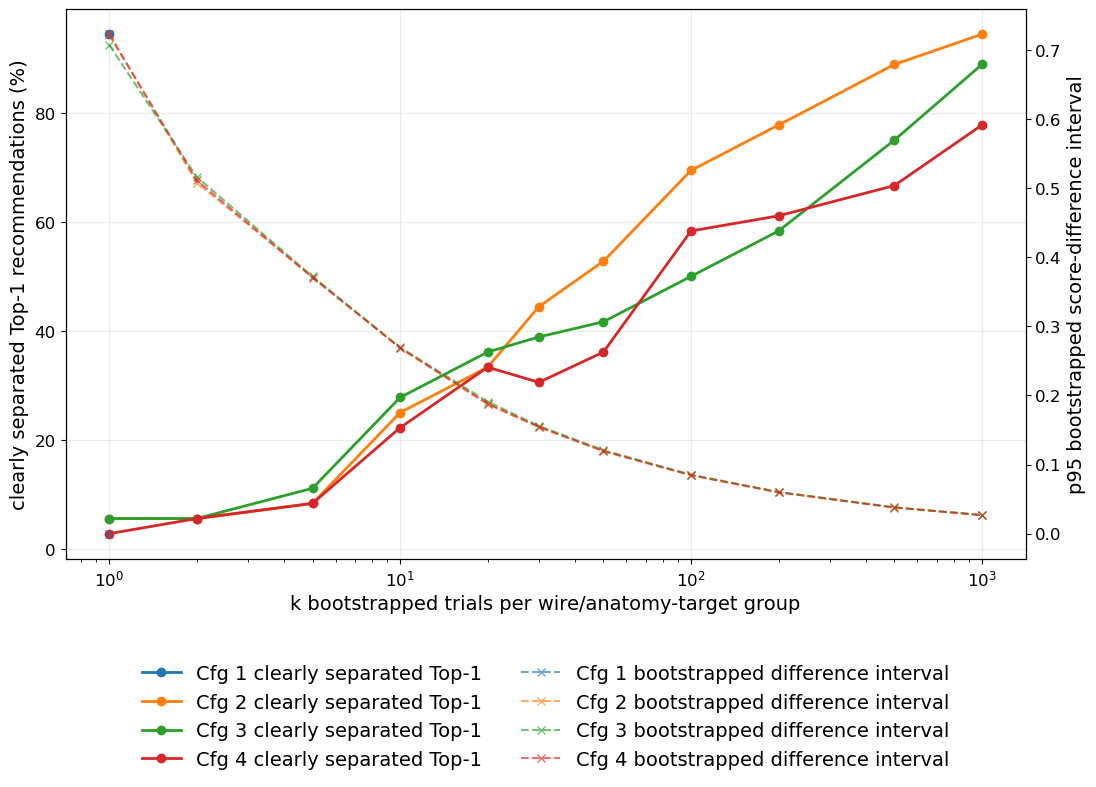

Saved cached pairwise bootstrap summary: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_pairwise_bootstrap_clear_top1_summary_by_k.csv`

Saved plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_pairwise_bootstrap_top1_clarity_vs_k.png`

,config_id,k,n_anatomy_target_experiments,n_clear_top1,pct_clear_top1,median_min_p_top1_greater_other,p95_pairwise_ci_half_width,median_pairwise_ci_half_width
0,1,1,36,34,0.9444,1.0000,0.0000,0.0000
1,2,1,36,2,0.0556,0.6140,0.7223,0.2355
2,2,2,36,2,0.0556,0.6490,0.5078,0.1856
3,2,5,36,3,0.0833,0.7460,0.3715,0.1079
4,2,10,36,9,0.2500,0.8290,0.2684,0.0788
5,2,20,36,12,0.3333,0.9045,0.1872,0.0551
6,2,30,36,16,0.4444,0.9445,0.1541,0.0459
7,2,50,36,19,0.5278,0.9855,0.1198,0.0364
8,2,100,36,25,0.6944,0.9980,0.0848,0.0260
9,2,200,36,28,0.7778,1.0000,0.0601,0.0183


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

output_dir = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
summary_csv = output_dir / "e1_friction_01_pairwise_bootstrap_clear_top1_summary_by_k.csv"
clear_top1_csv = output_dir / "e1_friction_01_pairwise_bootstrap_clear_top1_by_target.csv"
pairwise_diff_csv = output_dir / "e1_friction_01_pairwise_bootstrap_all_wire_differences.csv"
plot_path = output_dir / "e1_friction_01_pairwise_bootstrap_top1_clarity_vs_k.png"

if summary_csv.exists():
    plot_df = pd.read_csv(summary_csv)
elif clear_top1_csv.exists() and pairwise_diff_csv.exists():
    clear_top1_by_target_e1_df = pd.read_csv(clear_top1_csv)
    pairwise_bootstrap_diff_e1_df = pd.read_csv(pairwise_diff_csv)

    clear_top1_summary_e1_df = (
        clear_top1_by_target_e1_df
        .groupby(["config_id", "k"], dropna=False)
        .agg(
            n_anatomy_target_experiments=("top1_clear_vs_all", "size"),
            n_clear_top1=("top1_clear_vs_all", "sum"),
            pct_clear_top1=("top1_clear_vs_all", "mean"),
            median_min_p_top1_greater_other=("top1_min_p_greater_other", "median"),
        )
        .reset_index()
        .sort_values(["config_id", "k"])
    )

    pairwise_ci_summary_e1_df = (
        pairwise_bootstrap_diff_e1_df
        .groupby(["config_id", "k"], dropna=False)
        .agg(
            p95_pairwise_ci_half_width=("ci_half_width_diff", lambda s: s.quantile(0.95)),
            median_pairwise_ci_half_width=("ci_half_width_diff", "median"),
        )
        .reset_index()
    )

    plot_df = clear_top1_summary_e1_df.merge(pairwise_ci_summary_e1_df, on=["config_id", "k"], how="left")
    plot_df.to_csv(summary_csv, index=False)
else:
    plot_df = pd.DataFrame()
    display(Markdown(
        "Missing cached pairwise bootstrap files. Run the pairwise bootstrap cells once first: "
        f"`{clear_top1_csv}` and `{pairwise_diff_csv}`."
    ))

if not plot_df.empty:
    fig, ax_clear = plt.subplots(figsize=(12, 8.2))
    ax_ci = ax_clear.twinx()
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for idx, (config_id, group) in enumerate(plot_df.groupby("config_id", dropna=False)):
        color = color_cycle[idx % len(color_cycle)]
        ax_clear.plot(
            group["k"],
            100 * group["pct_clear_top1"],
            marker="o",
            linewidth=2,
            color=color,
            label=f"Cfg {int(config_id)} clearly separated Top-1",
        )
        ax_ci.plot(
            group["k"],
            group["p95_pairwise_ci_half_width"],
            marker="x",
            linestyle="--",
            linewidth=1.5,
            color=color,
            alpha=0.65,
            label=f"Cfg {int(config_id)} bootstrapped difference interval",
        )

    ax_clear.set_xscale("log")
    ax_clear.set_xlabel("k bootstrapped trials per wire/anatomy-target group", fontsize=14)
    ax_clear.set_ylabel("clearly separated Top-1 recommendations (%)", fontsize=14)
    ax_ci.set_ylabel("p95 bootstrapped score-difference interval", fontsize=14)
    ax_clear.tick_params(axis="both", labelsize=12)
    ax_ci.tick_params(axis="y", labelsize=12)
    ax_clear.grid(alpha=0.25)

    lines_clear, labels_clear = ax_clear.get_legend_handles_labels()
    lines_ci, labels_ci = ax_ci.get_legend_handles_labels()
    ax_clear.legend(
        lines_clear + lines_ci,
        labels_clear + labels_ci,
        loc="upper center",
        bbox_to_anchor=(0.56, -0.20),
        ncol=2,
        fontsize=14,
        frameon=False,
    )
    fig.subplots_adjust(left=0.10, right=0.90, top=0.97, bottom=0.34)
    fig.savefig(plot_path, dpi=200, bbox_inches="tight")
    plt.show()

    display(Markdown(f"Saved cached pairwise bootstrap summary: `{summary_csv}`"))
    display(Markdown(f"Saved plot: `{plot_path}`"))
    display(plot_df.round(4))


## 1.4 Pipeline Performance Characterization

This section combines the uncertainty estimate from section 1.3 with the Top-1 vs. Top-2 score differences from section 1.2.

For every `(config, k)` it reports:

- the empirical pipeline-score CI half-width from the bootstrap analysis
- the percentage of anatomy-target combinations where Top-1 is statistically distinguishable from Top-2
- the percentage of anatomy-target combinations where Top-1 and Top-2 form a non-separable top cluster

Decision rule:

`Top-1 clear if: top1_score - top2_score > 2 * ci_half_width`

The factor `2` is used because two independent score estimates with equal CI half-width `epsilon` have non-overlapping confidence intervals only when their score difference is larger than `2 * epsilon`.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Saved Top-1/Top-2 gaps: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_top12_gaps.csv`

Saved pipeline performance table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_pipeline_performance_by_k.csv`

Saved performance trade-off plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_pipeline_performance_tradeoff.png`

Saved Top-1/Top-2 threshold plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_top12_gap_thresholds.png`

### Pipeline performance by config and k

,config_id,k,ci_half_width,top12_clear_threshold_2ci,n_anatomy_target_combinations,n_clear_top1,n_top_cluster,pct_clear_top1,pct_top_cluster,compute_factor_vs_k30
0,1,1,0.0000,0.0000,36,34,2,94.4,5.6,0.0
1,2,1,0.4925,0.9849,36,0,36,0.0,100.0,0.0
2,2,2,0.4751,0.9503,36,0,36,0.0,100.0,0.1
3,2,5,0.3223,0.6445,36,0,36,0.0,100.0,0.2
4,2,10,0.2342,0.4684,36,0,36,0.0,100.0,0.3
5,2,20,0.1684,0.3369,36,0,36,0.0,100.0,0.7
6,2,30,0.1357,0.2714,36,0,36,0.0,100.0,1.0
7,2,50,0.1076,0.2151,36,1,35,2.8,97.2,1.7
8,2,100,0.0760,0.1521,36,3,33,8.3,91.7,3.3
9,2,200,0.0534,0.1069,36,6,30,16.7,83.3,6.7


### Top-1 vs Top-2 score gaps

,config_id,tree_target_combo,top1_wire,top2_wire,top1_score,top2_score,diff_top12
0,1,Tree_1382__target_0__seedbase_223,universal_ii/tight_j,universal_ii/standard_j,0.928429,0.901752,0.026677
1,1,Tree_1382__target_1__seedbase_224,universal_ii/tight_j,universal_ii/standard_j,0.989461,0.966130,0.023331
2,1,Tree_1382__target_2__seedbase_225,amplatz_super_stiff/standard_j,universal_ii/tight_j,0.859967,0.764610,0.095357
3,1,Tree_1882__target_0__seedbase_323,universal_ii/tight_j,amplatz_super_stiff/strong_hook,0.998781,0.979346,0.019435
4,1,Tree_1882__target_1__seedbase_324,universal_ii/standard_j,universal_ii/tight_j,0.994171,0.975358,0.018812
5,1,Tree_1882__target_2__seedbase_325,universal_ii/straight,universal_ii/standard_j,0.997838,0.997755,0.000083
6,1,Tree_1996__target_0__seedbase_423,universal_ii/tight_j,universal_ii/strong_hook,0.998548,0.970222,0.028326
7,1,Tree_1996__target_1__seedbase_424,universal_ii/tight_j,amplatz_super_stiff/standard_j,0.998905,0.929353,0.069552
8,1,Tree_1996__target_2__seedbase_425,amplatz_super_stiff/straight,universal_ii/straight,0.985933,0.974550,0.011382
9,1,Tree_5348__target_0__seedbase_523,universal_ii/standard_j,amplatz_super_stiff/standard_j,0.975586,0.974976,0.000610


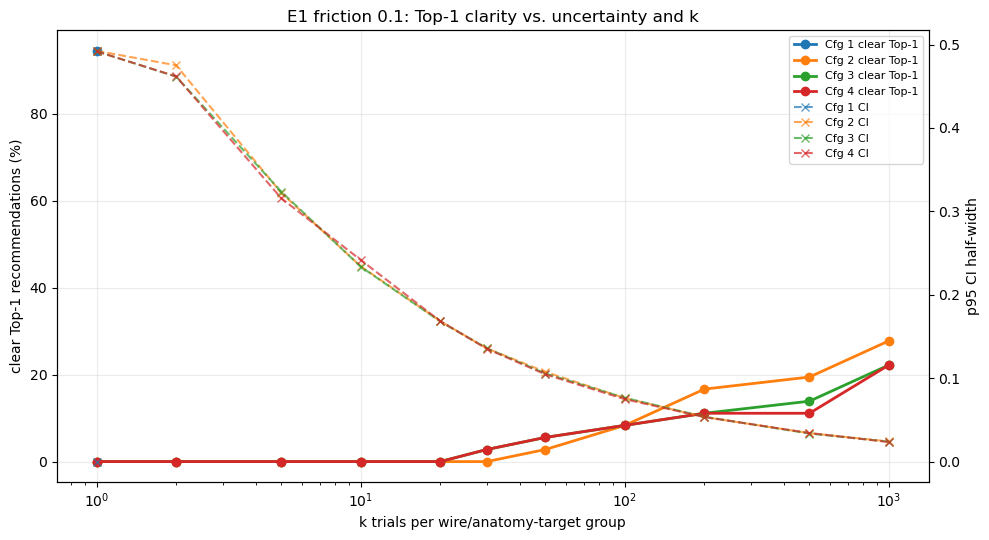

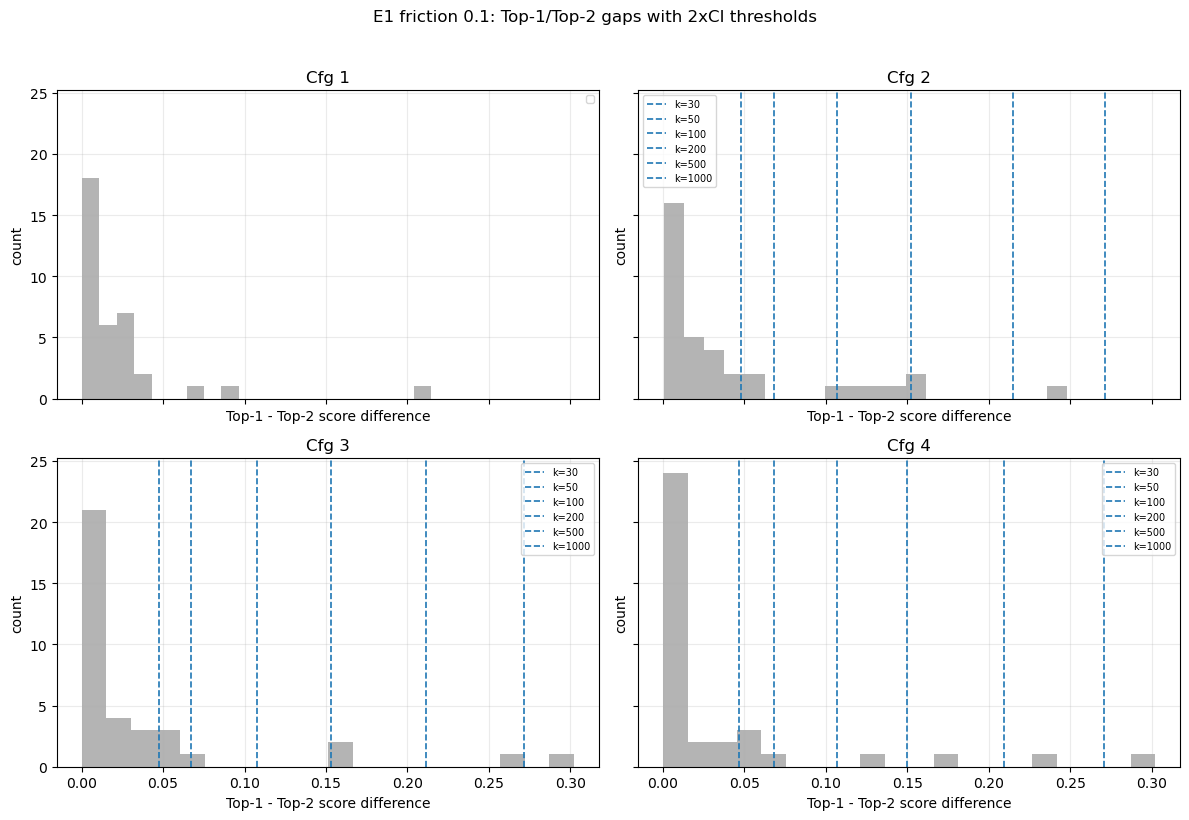

In [14]:
import numpy as np
import matplotlib.pyplot as plt

required_tables = ["k_calibration_summary_01_df", "wire_score_ranked_01_df"]
missing_tables = [name for name in required_tables if name not in globals()]

if missing_tables:
    display(Markdown("Run sections 1.2 and 1.3 first. Missing: `" + "`, `".join(missing_tables) + "`."))
else:
    output_dir = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
    output_dir.mkdir(parents=True, exist_ok=True)

    top12_rows = []
    for (config_id, tree_target_combo), group in wire_score_ranked_01_df.groupby(["config_id", "tree_target_combo"], dropna=False):
        ranked = group.sort_values("rank")
        if len(ranked) < 2:
            continue
        top1 = ranked.iloc[0]
        top2 = ranked.iloc[1]
        top12_rows.append(
            {
                "config_id": int(config_id),
                "tree_target_combo": tree_target_combo,
                "top1_wire": top1["execution_wire"],
                "top2_wire": top2["execution_wire"],
                "top1_score": float(top1["wire_score_k1000"]),
                "top2_score": float(top2["wire_score_k1000"]),
                "diff_top12": float(top1["wire_score_k1000"] - top2["wire_score_k1000"]),
            }
        )
    top12_gap_01_df = pd.DataFrame(top12_rows)

    performance_rows = []
    for _, row in k_calibration_summary_01_df.iterrows():
        config_id = int(row["config_id"])
        k_value = int(row["k"])
        ci_half_width = float(row["p95_ci_half_width"])
        threshold = 2.0 * ci_half_width
        config_top12 = top12_gap_01_df.loc[top12_gap_01_df["config_id"] == config_id].copy()
        clear_mask = config_top12["diff_top12"] > threshold
        n_total = int(len(config_top12))
        n_clear = int(clear_mask.sum())
        n_cluster = int(n_total - n_clear)
        performance_rows.append(
            {
                "config_id": config_id,
                "k": k_value,
                "ci_half_width": ci_half_width,
                "top12_clear_threshold_2ci": threshold,
                "n_anatomy_target_combinations": n_total,
                "n_clear_top1": n_clear,
                "n_top_cluster": n_cluster,
                "pct_clear_top1": n_clear / n_total if n_total else np.nan,
                "pct_top_cluster": n_cluster / n_total if n_total else np.nan,
                "compute_factor_vs_k30": k_value / 30.0,
            }
        )

    pipeline_performance_01_df = pd.DataFrame(performance_rows).sort_values(["config_id", "k"]).reset_index(drop=True)
    pipeline_performance_display_01_df = pipeline_performance_01_df.copy()
    pipeline_performance_display_01_df["pct_clear_top1"] = (100 * pipeline_performance_display_01_df["pct_clear_top1"]).round(1)
    pipeline_performance_display_01_df["pct_top_cluster"] = (100 * pipeline_performance_display_01_df["pct_top_cluster"]).round(1)
    pipeline_performance_display_01_df["ci_half_width"] = pipeline_performance_display_01_df["ci_half_width"].round(4)
    pipeline_performance_display_01_df["top12_clear_threshold_2ci"] = pipeline_performance_display_01_df["top12_clear_threshold_2ci"].round(4)
    pipeline_performance_display_01_df["compute_factor_vs_k30"] = pipeline_performance_display_01_df["compute_factor_vs_k30"].round(1)

    top12_gap_csv_01 = output_dir / "e1_friction_01_top12_gaps.csv"
    pipeline_performance_csv_01 = output_dir / "e1_friction_01_pipeline_performance_by_k.csv"
    top12_gap_01_df.to_csv(top12_gap_csv_01, index=False)
    pipeline_performance_01_df.to_csv(pipeline_performance_csv_01, index=False)

    fig, ax_clear = plt.subplots(figsize=(10, 5.5))
    ax_ci = ax_clear.twinx()
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for idx, (config_id, group) in enumerate(pipeline_performance_01_df.groupby("config_id", dropna=False)):
        color = color_cycle[idx % len(color_cycle)]
        ax_clear.plot(group["k"], 100 * group["pct_clear_top1"], marker="o", linewidth=2, color=color, label=f"Cfg {int(config_id)} clear Top-1")
        ax_ci.plot(group["k"], group["ci_half_width"], marker="x", linestyle="--", linewidth=1.5, color=color, alpha=0.7, label=f"Cfg {int(config_id)} CI")
    ax_clear.set_xscale("log")
    ax_clear.set_xlabel("k trials per wire/anatomy-target group")
    ax_clear.set_ylabel("clear Top-1 recommendations (%)")
    ax_ci.set_ylabel("p95 CI half-width")
    ax_clear.set_title("E1 friction 0.1: Top-1 clarity vs. uncertainty and k")
    ax_clear.grid(alpha=0.25)
    lines_clear, labels_clear = ax_clear.get_legend_handles_labels()
    lines_ci, labels_ci = ax_ci.get_legend_handles_labels()
    ax_clear.legend(lines_clear + lines_ci, labels_clear + labels_ci, loc="best", fontsize=8)
    fig.tight_layout()
    performance_tradeoff_plot_01 = output_dir / "e1_friction_01_pipeline_performance_tradeoff.png"
    fig.savefig(performance_tradeoff_plot_01, dpi=200, bbox_inches="tight")

    selected_k_values = [30, 50, 100, 200, 500, 1000]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
    axes = axes.ravel()
    for ax, (config_id, gaps) in zip(axes, top12_gap_01_df.groupby("config_id", dropna=False)):
        ax.hist(gaps["diff_top12"], bins=20, alpha=0.65, color="0.55")
        thresholds = pipeline_performance_01_df.loc[
            (pipeline_performance_01_df["config_id"] == int(config_id))
            & (pipeline_performance_01_df["k"].isin(selected_k_values)),
            ["k", "top12_clear_threshold_2ci"],
        ]
        for _, threshold_row in thresholds.iterrows():
            ax.axvline(threshold_row["top12_clear_threshold_2ci"], linestyle="--", linewidth=1.2, label=f"k={int(threshold_row['k'])}")
        ax.set_title(f"Cfg {int(config_id)}")
        ax.set_xlabel("Top-1 - Top-2 score difference")
        ax.set_ylabel("count")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=7)
    fig.suptitle("E1 friction 0.1: Top-1/Top-2 gaps with 2xCI thresholds", y=1.02)
    fig.tight_layout()
    top12_threshold_plot_01 = output_dir / "e1_friction_01_top12_gap_thresholds.png"
    fig.savefig(top12_threshold_plot_01, dpi=200, bbox_inches="tight")

    display(Markdown(f"Saved Top-1/Top-2 gaps: `{top12_gap_csv_01}`"))
    display(Markdown(f"Saved pipeline performance table: `{pipeline_performance_csv_01}`"))
    display(Markdown(f"Saved performance trade-off plot: `{performance_tradeoff_plot_01}`"))
    display(Markdown(f"Saved Top-1/Top-2 threshold plot: `{top12_threshold_plot_01}`"))
    display(Markdown("### Pipeline performance by config and k"))
    display(pipeline_performance_display_01_df)
    display(Markdown("### Top-1 vs Top-2 score gaps"))
    display(top12_gap_01_df.head(20))


## 1.4.1 Pairwise Bootstrap Confidence Analysis

This section recomputes the E1 friction 0.1 scoring in small explicit steps. The goal is to keep the intermediate tables visible:

1. compute config-specific p99 step budgets, force normalization, and calibrated trial scores,
2. compute the overall wire score per configuration/anatomy-target/wire,
3. bootstrap each wire/anatomy-target score for several values of `k`,
4. compute paired bootstrap score differences for every wire pair,
5. plot the percentage of anatomy-target experiments where the Top-1 wire is clearly separated from every other wire.

A Top-1 recommendation is counted as clearly separated if none of the paired 95% bootstrap confidence intervals between Top-1 and any other wire includes zero.


In [ ]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

E1_PAIRWISE_BOOT_N = 1000
E1_PAIRWISE_BOOT_SEED = 123
E1_PAIRWISE_K_VALUES = [1, 2, 5, 10, 20, 30, 50, 100, 200, 500, 1000]
E1_FORCE_LIMIT_N = 2.0

output_dir = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

def load_e1_trial_source():
    """Return the E1 trial table. Prefer the in-memory notebook DataFrame."""
    if "_trial_df" in globals():
        print("Using in-memory `_trial_df`.")
        return _trial_df.copy()

    analysis_root = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_01_real"
    csv_paths = sorted(analysis_root.glob("e1_tinyfat_friction_01_e0_style_config_*_trials_flat.csv"))
    if not csv_paths:
        raise FileNotFoundError(
            "Run the dataframe-generation cells first, or check that E1 trial CSVs exist under "
            f"{analysis_root}"
        )

    print(f"Loading {len(csv_paths)} trial CSVs from {analysis_root}.")
    parts = []
    for csv_path in csv_paths:
        part = pd.read_csv(csv_path)
        if "friction_label" not in part.columns:
            part["friction_label"] = "0.1"
        parts.append(part)
    return pd.concat(parts, ignore_index=True)

def success_to_float(series):
    mapped = series.map({True: 1.0, False: 0.0, "true": 1.0, "false": 0.0, "True": 1.0, "False": 0.0})
    return mapped.fillna(pd.to_numeric(series, errors="coerce")).fillna(0.0)

def force_safety_score(force_n):
    """Same force score shape as the previous E1 analysis, clipped to [0, 1]."""
    force = pd.to_numeric(force_n, errors="coerce").clip(lower=0)
    c = 0.30
    p = 2.0
    k = 10.0
    f50 = 1.55
    fmax = E1_FORCE_LIMIT_N
    g = 1.0 / (1.0 + np.exp(k * (force - f50)))
    g0 = 1.0 / (1.0 + np.exp(k * (0.0 - f50)))
    gmax = 1.0 / (1.0 + np.exp(k * (fmax - f50)))
    logistic_part = ((g - gmax) / (g0 - gmax)).clip(0, 1)
    polynomial_part = (1.0 - c * np.power(force, p)).clip(0, 1)
    return (logistic_part * polynomial_part).clip(0, 1)

trial_source = load_e1_trial_source()
print(f"raw trials: {len(trial_source):,}")
print("columns needed:", ["config_id", "anatomy_id", "target_index", "execution_wire", "success", "steps_total", "wire_force_normal_trial_max_N"])


Using in-memory `_trial_df`.


In [ ]:
# Step 1: config-specific p99 step budget, force normalization, and trial score.
score_source = trial_source.copy()
if "friction_label" in score_source.columns:
    score_source = score_source.loc[score_source["friction_label"].astype(str).eq("0.1")].copy()

if "tree_target_combo" not in score_source.columns:
    score_source["tree_target_combo"] = (
        score_source["anatomy_id"].astype(str)
        + "__target_"
        + score_source["target_index"].astype(str)
    )

score_source["config_id"] = score_source["config_id"].astype(int)
score_source["success_numeric"] = success_to_float(score_source["success"])
score_source["steps_total"] = pd.to_numeric(score_source["steps_total"], errors="coerce")
score_source["wire_force_normal_trial_max_N"] = pd.to_numeric(score_source["wire_force_normal_trial_max_N"], errors="coerce")

step_budget_by_config = (
    score_source.loc[score_source["success_numeric"].eq(1.0)]
    .groupby("config_id")["steps_total"]
    .quantile(0.99)
    .to_dict()
)

scored_parts = []
for config_id, config_df in score_source.groupby("config_id", dropna=False):
    part = config_df.copy()
    step_budget = float(step_budget_by_config.get(int(config_id), part["steps_total"].max()))
    denom = max(step_budget - 1.0, 1.0)

    part["step_budget_p99"] = step_budget
    part["score_efficiency"] = (1.0 - ((part["steps_total"] - 1.0) / denom)).clip(0, 1)
    part.loc[part["success_numeric"].lt(1.0), "score_efficiency"] = 0.0
    part["score_safety"] = force_safety_score(part["wire_force_normal_trial_max_N"])
    part["within_step_budget_p99"] = part["steps_total"].le(part["step_budget_p99"])
    part["valid_for_score"] = (
        part["success_numeric"].eq(1.0)
        & part["within_step_budget_p99"]
        & part["wire_force_normal_trial_max_N"].le(E1_FORCE_LIMIT_N)
    )
    part["trial_score"] = 0.5 * part["score_efficiency"] + 0.5 * part["score_safety"]
    scored_parts.append(part)

trial_score_e1_pairwise_df = pd.concat(scored_parts, ignore_index=True)
trial_score_csv = output_dir / "e1_friction_01_pairwise_bootstrap_trial_scores.csv"
trial_score_e1_pairwise_df.to_csv(trial_score_csv, index=False)

print(f"scored trials: {len(trial_score_e1_pairwise_df):,}")
print(f"saved: {trial_score_csv}")
display(Markdown("### Config p99 step budgets"))
display(pd.DataFrame([{"config_id": int(k), "step_budget_p99": v} for k, v in step_budget_by_config.items()]).sort_values("config_id").round(2))
display(Markdown("### Trial-score sanity check"))
display(
    trial_score_e1_pairwise_df
    .groupby("config_id")
    .agg(
        n_trials=("trial_score", "size"),
        valid_rate=("valid_for_score", "mean"),
        mean_trial_score=("trial_score", "mean"),
        mean_valid_trial_score=("trial_score", lambda s: s[trial_score_e1_pairwise_df.loc[s.index, "valid_for_score"]].mean()),
    )
    .round(4)
)


/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)
/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


scored trials: 1,620,540
saved: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_pairwise_bootstrap_trial_scores.csv


### Config p99 step budgets

,config_id,step_budget_p99
0,1,843.66
1,2,822.00
2,3,831.00
3,4,828.00


### Trial-score sanity check

,n_trials,valid_rate,mean_trial_score,mean_valid_trial_score
config_id,,,,
1,540,0.4759,0.5839,0.8857
2,540000,0.4903,0.5851,0.8688
3,540000,0.5145,0.6035,0.8669
4,540000,0.5148,0.6037,0.8669


In [ ]:
# Step 2: overall score per configuration/anatomy-target/wire.
wire_group_cols = ["config_id", "tree_target_combo", "execution_wire"]

overall_rows = []
for (config_id, tree_target_combo, execution_wire), group in trial_score_e1_pairwise_df.groupby(wire_group_cols, dropna=False):
    valid = group["valid_for_score"].astype(bool)
    valid_rate = valid.mean()
    mean_valid_score = group.loc[valid, "trial_score"].mean() if valid.any() else 0.0
    overall_rows.append(
        {
            "config_id": int(config_id),
            "tree_target_combo": tree_target_combo,
            "execution_wire": execution_wire,
            "n_trials": int(len(group)),
            "n_valid_trials": int(valid.sum()),
            "valid_rate": float(valid_rate),
            "mean_valid_trial_score": float(mean_valid_score),
            "wire_score": float(valid_rate * mean_valid_score),
        }
    )

overall_wire_score_e1_pairwise_df = pd.DataFrame(overall_rows)
overall_wire_score_e1_pairwise_df = (
    overall_wire_score_e1_pairwise_df
    .sort_values(["config_id", "tree_target_combo", "wire_score"], ascending=[True, True, False])
    .reset_index(drop=True)
)
overall_wire_score_e1_pairwise_df["rank"] = overall_wire_score_e1_pairwise_df.groupby(["config_id", "tree_target_combo"]).cumcount() + 1

overall_score_csv = output_dir / "e1_friction_01_pairwise_bootstrap_overall_wire_scores.csv"
overall_wire_score_e1_pairwise_df.to_csv(overall_score_csv, index=False)

print(f"wire/anatomy-target groups: {len(overall_wire_score_e1_pairwise_df):,}")
print(f"saved: {overall_score_csv}")
display(overall_wire_score_e1_pairwise_df.head(20).round(4))


wire/anatomy-target groups: 2,160
saved: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_pairwise_bootstrap_overall_wire_scores.csv


,config_id,tree_target_combo,execution_wire,n_trials,n_valid_trials,valid_rate,mean_valid_trial_score,wire_score,rank
0,1,Tree_1382__target_0__seedbase_223,universal_ii/tight_j,1,1,1.0,0.8878,0.8878,1
1,1,Tree_1382__target_0__seedbase_223,universal_ii/standard_j,1,1,1.0,0.8581,0.8581,2
2,1,Tree_1382__target_0__seedbase_223,amplatz_super_stiff/tight_j,1,1,1.0,0.7357,0.7357,3
3,1,Tree_1382__target_0__seedbase_223,universal_ii/gentle,1,1,1.0,0.5778,0.5778,4
4,1,Tree_1382__target_0__seedbase_223,amplatz_super_stiff/strong_hook,1,1,1.0,0.5184,0.5184,5
5,1,Tree_1382__target_0__seedbase_223,amplatz_super_stiff/gentle,1,0,0.0,0.0000,0.0000,6
6,1,Tree_1382__target_0__seedbase_223,amplatz_super_stiff/standard_j,1,0,0.0,0.0000,0.0000,7
7,1,Tree_1382__target_0__seedbase_223,amplatz_super_stiff/straight,1,0,0.0,0.0000,0.0000,8
8,1,Tree_1382__target_0__seedbase_223,steve_default/gentle,1,0,0.0,0.0000,0.0000,9
9,1,Tree_1382__target_0__seedbase_223,steve_default/standard_j,1,0,0.0,0.0000,0.0000,10


In [14]:
# Step 3: bootstrap each wire/anatomy-target score for each k.
# This stores the bootstrap distributions in memory for the pairwise step below.

def bootstrap_wire_score_distribution(group, k_value, rng):
    trial_scores = group["trial_score"].to_numpy(dtype=float)
    valid = group["valid_for_score"].to_numpy(dtype=bool)
    sample_idx = rng.integers(0, len(group), size=(E1_PAIRWISE_BOOT_N, k_value))

    sampled_valid = valid[sample_idx]
    sampled_scores = trial_scores[sample_idx]
    valid_counts = sampled_valid.sum(axis=1)
    valid_rate = valid_counts / float(k_value)
    valid_score_sum = (sampled_scores * sampled_valid).sum(axis=1)
    mean_valid_score = np.divide(
        valid_score_sum,
        valid_counts,
        out=np.zeros_like(valid_score_sum, dtype=float),
        where=valid_counts > 0,
    )
    return valid_rate * mean_valid_score

rng = np.random.default_rng(E1_PAIRWISE_BOOT_SEED)
bootstrap_score_distributions = {}
wire_bootstrap_rows = []

grouped_trials = list(trial_score_e1_pairwise_df.groupby(wire_group_cols, dropna=False))
print(f"bootstrapping {len(grouped_trials):,} wire/anatomy-target groups with B={E1_PAIRWISE_BOOT_N}")

for group_index, ((config_id, tree_target_combo, execution_wire), group) in enumerate(grouped_trials, start=1):
    n_available = len(group)
    for k_value in E1_PAIRWISE_K_VALUES:
        if k_value > n_available:
            continue
        boot_scores = bootstrap_wire_score_distribution(group, k_value, rng)
        key = (int(config_id), tree_target_combo, execution_wire, int(k_value))
        bootstrap_score_distributions[key] = boot_scores
        ci_low, ci_high = np.quantile(boot_scores, [0.025, 0.975])
        wire_bootstrap_rows.append(
            {
                "config_id": int(config_id),
                "tree_target_combo": tree_target_combo,
                "execution_wire": execution_wire,
                "n_trials_available": int(n_available),
                "k": int(k_value),
                "n_boot": int(E1_PAIRWISE_BOOT_N),
                "bootstrap_mean_score": float(boot_scores.mean()),
                "ci_low": float(ci_low),
                "ci_high": float(ci_high),
                "ci_half_width": float((ci_high - ci_low) / 2.0),
            }
        )
    if group_index % 250 == 0:
        print(f"processed groups: {group_index:,}/{len(grouped_trials):,}")

wire_bootstrap_ci_e1_pairwise_df = pd.DataFrame(wire_bootstrap_rows)
wire_bootstrap_ci_csv = output_dir / "e1_friction_01_pairwise_bootstrap_wire_score_ci.csv"
wire_bootstrap_ci_e1_pairwise_df.to_csv(wire_bootstrap_ci_csv, index=False)

print(f"bootstrap rows: {len(wire_bootstrap_ci_e1_pairwise_df):,}")
print(f"saved: {wire_bootstrap_ci_csv}")
display(wire_bootstrap_ci_e1_pairwise_df.head(20).round(4))


NameError: name 'E1_PAIRWISE_BOOT_SEED' is not defined

In [13]:
# Step 4: paired bootstrap differences for every wire pair.
# This version samples matched trial_index values for both wires in a pair.

pairwise_source = trial_score_e1_pairwise_df.copy()
if "trial_index" not in pairwise_source.columns:
    print("No `trial_index` column found; using within-wire row order as the pairing key.")
    pairwise_source["trial_index"] = pairwise_source.groupby(wire_group_cols).cumcount()

pairwise_source["trial_index"] = pairwise_source["trial_index"].astype(int)

pairwise_rows = []
clear_top1_rows = []
rng = np.random.default_rng(E1_PAIRWISE_BOOT_SEED)

def bootstrap_score_from_indices(scores, valid, sample_idx, k_value):
    sampled_valid = valid[sample_idx]
    sampled_scores = scores[sample_idx]
    valid_counts = sampled_valid.sum(axis=1)
    valid_rate = valid_counts / float(k_value)
    valid_score_sum = (sampled_scores * sampled_valid).sum(axis=1)
    mean_valid_score = np.divide(
        valid_score_sum,
        valid_counts,
        out=np.zeros_like(valid_score_sum, dtype=float),
        where=valid_counts > 0,
    )
    return valid_rate * mean_valid_score

def paired_bootstrap_diff(wire_trial_table, wire_a, wire_b, k_value):
    a = (
        wire_trial_table.loc[wire_trial_table["execution_wire"].eq(wire_a), ["trial_index", "trial_score", "valid_for_score"]]
        .rename(columns={"trial_score": "trial_score_a", "valid_for_score": "valid_a"})
    )
    b = (
        wire_trial_table.loc[wire_trial_table["execution_wire"].eq(wire_b), ["trial_index", "trial_score", "valid_for_score"]]
        .rename(columns={"trial_score": "trial_score_b", "valid_for_score": "valid_b"})
    )
    paired = a.merge(b, on="trial_index", how="inner").sort_values("trial_index")
    if len(paired) < k_value:
        return None, int(len(paired))

    sample_idx = rng.integers(0, len(paired), size=(E1_PAIRWISE_BOOT_N, int(k_value)))
    score_a = bootstrap_score_from_indices(
        paired["trial_score_a"].to_numpy(dtype=float),
        paired["valid_a"].to_numpy(dtype=bool),
        sample_idx,
        int(k_value),
    )
    score_b = bootstrap_score_from_indices(
        paired["trial_score_b"].to_numpy(dtype=float),
        paired["valid_b"].to_numpy(dtype=bool),
        sample_idx,
        int(k_value),
    )
    return score_a - score_b, int(len(paired))

for (config_id, tree_target_combo), score_group in overall_wire_score_e1_pairwise_df.groupby(["config_id", "tree_target_combo"], dropna=False):
    config_id = int(config_id)
    ranked = score_group.sort_values("rank")
    wires = ranked["execution_wire"].tolist()
    top1_wire = ranked.iloc[0]["execution_wire"]
    top1_score = float(ranked.iloc[0]["wire_score"])
    observed_score_by_wire = ranked.set_index("execution_wire")["wire_score"].to_dict()

    wire_trial_table = pairwise_source.loc[
        pairwise_source["config_id"].astype(int).eq(config_id)
        & pairwise_source["tree_target_combo"].eq(tree_target_combo)
    ].copy()

    for k_value in E1_PAIRWISE_K_VALUES:
        available_wires = [
            wire for wire in wires
            if len(wire_trial_table.loc[wire_trial_table["execution_wire"].eq(wire)]) >= int(k_value)
        ]
        if len(available_wires) < 2:
            continue

        top1_clear = True
        top1_worst_ci_low = np.inf
        top1_min_probability = 1.0

        for wire_a, wire_b in itertools.combinations(available_wires, 2):
            diff, n_matched_trials = paired_bootstrap_diff(wire_trial_table, wire_a, wire_b, int(k_value))
            if diff is None:
                continue

            ci_low, ci_high = np.quantile(diff, [0.025, 0.975])
            score_a = float(observed_score_by_wire[wire_a])
            score_b = float(observed_score_by_wire[wire_b])
            pairwise_rows.append(
                {
                    "config_id": config_id,
                    "tree_target_combo": tree_target_combo,
                    "k": int(k_value),
                    "wire_a": wire_a,
                    "wire_b": wire_b,
                    "n_matched_trials": int(n_matched_trials),
                    "observed_score_a": score_a,
                    "observed_score_b": score_b,
                    "observed_diff_a_minus_b": score_a - score_b,
                    "bootstrap_mean_diff_a_minus_b": float(diff.mean()),
                    "ci_low_diff_a_minus_b": float(ci_low),
                    "ci_high_diff_a_minus_b": float(ci_high),
                    "ci_half_width_diff": float((ci_high - ci_low) / 2.0),
                    "p_a_greater_b": float((diff > 0).mean()),
                    "ci_contains_zero": bool(ci_low <= 0 <= ci_high),
                    "bootstrap_pairing": "matched_trial_index",
                }
            )

            if wire_a == top1_wire or wire_b == top1_wire:
                if wire_a == top1_wire:
                    top1_diff = diff
                else:
                    top1_diff = -diff
                top1_ci_low, top1_ci_high = np.quantile(top1_diff, [0.025, 0.975])
                top1_worst_ci_low = min(top1_worst_ci_low, float(top1_ci_low))
                top1_min_probability = min(top1_min_probability, float((top1_diff > 0).mean()))
                if top1_ci_low <= 0 <= top1_ci_high:
                    top1_clear = False

        clear_top1_rows.append(
            {
                "config_id": config_id,
                "tree_target_combo": tree_target_combo,
                "k": int(k_value),
                "top1_wire": top1_wire,
                "top1_score": top1_score,
                "n_compared_wires": int(len(available_wires)),
                "top1_clear_vs_all": bool(top1_clear),
                "top1_worst_ci_low_vs_others": float(top1_worst_ci_low),
                "top1_min_p_greater_other": float(top1_min_probability),
                "bootstrap_pairing": "matched_trial_index",
            }
        )

pairwise_bootstrap_diff_e1_df = pd.DataFrame(pairwise_rows)
clear_top1_by_target_e1_df = pd.DataFrame(clear_top1_rows)

pairwise_diff_csv = output_dir / "e1_friction_01_pairwise_bootstrap_all_wire_differences.csv"
clear_top1_csv = output_dir / "e1_friction_01_pairwise_bootstrap_clear_top1_by_target.csv"
pairwise_bootstrap_diff_e1_df.to_csv(pairwise_diff_csv, index=False)
clear_top1_by_target_e1_df.to_csv(clear_top1_csv, index=False)

print(f"pairwise wire differences: {len(pairwise_bootstrap_diff_e1_df):,}")
print(f"clear Top-1 target rows: {len(clear_top1_by_target_e1_df):,}")
print("bootstrap pairing: matched_trial_index")
print(f"saved pairwise differences: {pairwise_diff_csv}")
print(f"saved clear Top-1 table: {clear_top1_csv}")
display(pairwise_bootstrap_diff_e1_df.head(20).round(4))
display(clear_top1_by_target_e1_df.head(20).round(4))


NameError: name 'trial_score_e1_pairwise_df' is not defined

In [12]:
# Step 5: plot percentage of clearly separated Top-1 recommendations over k.
clear_top1_summary_e1_df = (
    clear_top1_by_target_e1_df
    .groupby(["config_id", "k"], dropna=False)
    .agg(
        n_anatomy_target_experiments=("top1_clear_vs_all", "size"),
        n_clear_top1=("top1_clear_vs_all", "sum"),
        pct_clear_top1=("top1_clear_vs_all", "mean"),
        median_min_p_top1_greater_other=("top1_min_p_greater_other", "median"),
    )
    .reset_index()
    .sort_values(["config_id", "k"])
)

pairwise_ci_summary_e1_df = (
    pairwise_bootstrap_diff_e1_df
    .groupby(["config_id", "k"], dropna=False)
    .agg(
        p95_pairwise_ci_half_width=("ci_half_width_diff", lambda s: s.quantile(0.95)),
        median_pairwise_ci_half_width=("ci_half_width_diff", "median"),
    )
    .reset_index()
)

plot_df = clear_top1_summary_e1_df.merge(pairwise_ci_summary_e1_df, on=["config_id", "k"], how="left")
summary_csv = output_dir / "e1_friction_01_pairwise_bootstrap_clear_top1_summary_by_k.csv"
plot_df.to_csv(summary_csv, index=False)

fig, ax_clear = plt.subplots(figsize=(10, 5.5))
ax_ci = ax_clear.twinx()
color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for idx, (config_id, group) in enumerate(plot_df.groupby("config_id", dropna=False)):
    color = color_cycle[idx % len(color_cycle)]
    ax_clear.plot(
        group["k"],
        100 * group["pct_clear_top1"],
        marker="o",
        linewidth=2,
        color=color,
        label=f"Cfg {int(config_id)} clear Top-1",
    )
    ax_ci.plot(
        group["k"],
        group["p95_pairwise_ci_half_width"],
        marker="x",
        linestyle="--",
        linewidth=1.5,
        color=color,
        alpha=0.65,
        label=f"Cfg {int(config_id)} p95 paired CI",
    )

ax_clear.set_xscale("log")
ax_clear.set_xlabel("k bootstrapped trials per wire/anatomy-target group")
ax_clear.set_ylabel("clearly separated Top-1 recommendations (%)")
ax_ci.set_ylabel("p95 paired score-difference CI half-width")
ax_clear.set_title("E1 friction 0.1: paired-bootstrap Top-1 clarity vs. k")
ax_clear.grid(alpha=0.25)
lines_clear, labels_clear = ax_clear.get_legend_handles_labels()
lines_ci, labels_ci = ax_ci.get_legend_handles_labels()
ax_clear.legend(
    lines_clear + lines_ci,
    labels_clear + labels_ci,
    loc="center right",
    bbox_to_anchor=(1.0, 0.26),
    fontsize=8,
)
fig.tight_layout()

plot_path = output_dir / "e1_friction_01_pairwise_bootstrap_top1_clarity_vs_k.png"
fig.savefig(plot_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"saved summary: {summary_csv}")
print(f"saved plot: {plot_path}")
display(plot_df.round(4))


NameError: name 'clear_top1_by_target_e1_df' is not defined

## 1.5 Ranking Similarity Between Configurations

This section compares whether the four E1 configurations recommend similar wires. It reports two config-by-config grids: Top-1 agreement across anatomy-target combinations, and the mean Spearman rank correlation of the full wire ranking computed separately for each anatomy-target combination.



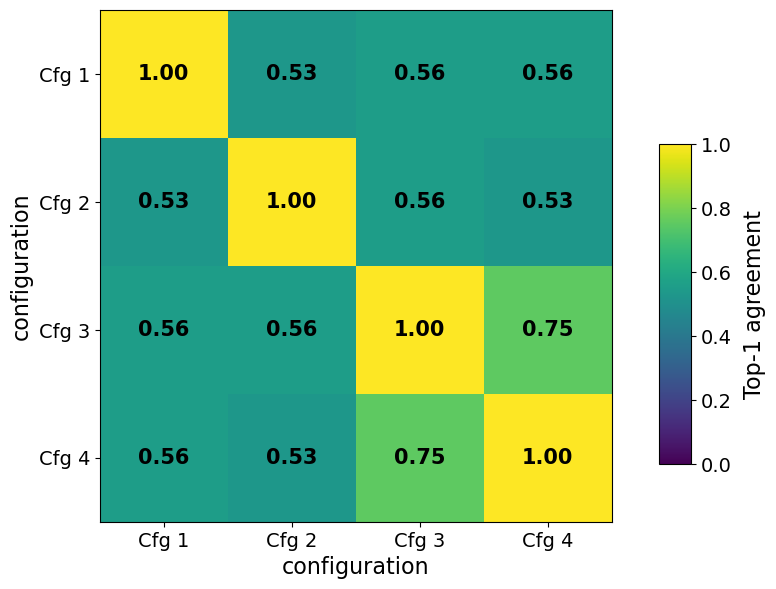

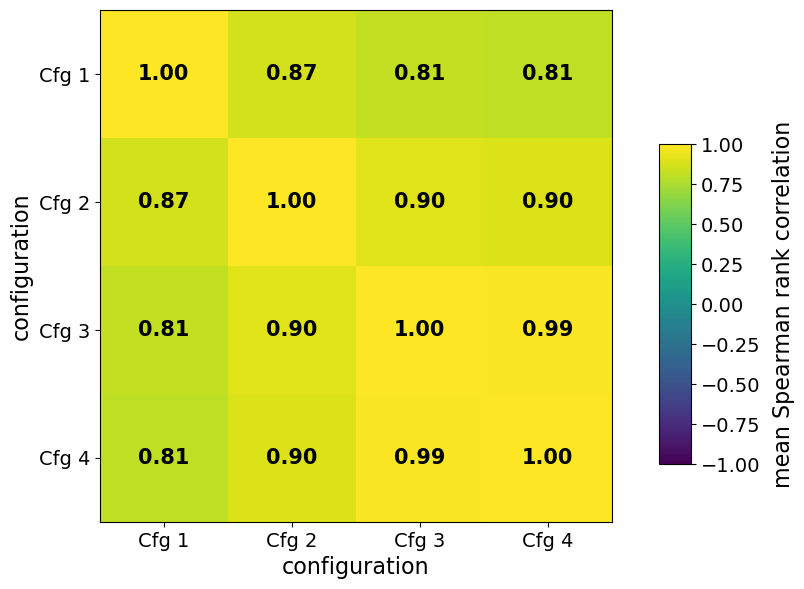

Saved Top-1 agreement grid/table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_config_top1_agreement.csv`

,1,2,3,4
1,1.000,0.528,0.556,0.556
2,0.528,1.000,0.556,0.528
3,0.556,0.556,1.000,0.750
4,0.556,0.528,0.750,1.000


Saved mean per-anatomy-target wire-rank correlation grid/table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_config_mean_per_target_wire_rank_correlation.csv`

config_b,1,2,3,4
config_a,,,,
1,1.000,0.866,0.815,0.810
2,0.866,1.000,0.900,0.896
3,0.815,0.900,1.000,0.989
4,0.810,0.896,0.989,1.000


Saved per-anatomy-target wire-rank correlation detail table: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_clean_analysis/e1_friction_01_config_per_target_wire_rank_correlation_detail.csv`

### Per-target rank-correlation status counts

,count
correlation_status,
defined,420
same_config,144
constant_scores,12


,tree_target_combo,config_a,config_b,spearman_rank_correlation,n_wires_compared,correlation_status
0,Tree_1382__target_0__seedbase_223,1,1,1.000,15,same_config
1,Tree_1382__target_0__seedbase_223,1,2,0.830,15,defined
2,Tree_1382__target_0__seedbase_223,1,3,0.777,15,defined
3,Tree_1382__target_0__seedbase_223,1,4,0.770,15,defined
4,Tree_1382__target_0__seedbase_223,2,1,0.830,15,defined
5,Tree_1382__target_0__seedbase_223,2,2,1.000,15,same_config
6,Tree_1382__target_0__seedbase_223,2,3,0.962,15,defined
7,Tree_1382__target_0__seedbase_223,2,4,0.978,15,defined
8,Tree_1382__target_0__seedbase_223,3,1,0.777,15,defined
9,Tree_1382__target_0__seedbase_223,3,2,0.962,15,defined


In [20]:
import numpy as np
import matplotlib.pyplot as plt

output_dir = PROJECT_ROOT / "results" / "master_thesis" / "e1_clean_analysis"
output_dir.mkdir(parents=True, exist_ok=True)

if "wire_score_ranked_01_df" not in globals():
    wire_score_csv = output_dir / "e1_friction_01_wire_score_k1000.csv"
    if not wire_score_csv.exists():
        display(Markdown("Run section 1.2 first. Missing: `wire_score_ranked_01_df` and saved wire-score CSV."))
        wire_score_ranked_01_df = pd.DataFrame()
    else:
        wire_score_ranked_01_df = pd.read_csv(wire_score_csv)
        wire_score_ranked_01_df = (
            wire_score_ranked_01_df
            .assign(config_id=lambda df: df["config_id"].astype(int))
            .sort_values(["config_id", "tree_target_combo", "wire_score_k1000"], ascending=[True, True, False])
            .reset_index(drop=True)
        )
        wire_score_ranked_01_df["rank"] = wire_score_ranked_01_df.groupby(["config_id", "tree_target_combo"]).cumcount() + 1

if wire_score_ranked_01_df.empty:
    display(Markdown("No wire-score ranking data available."))
else:

    config_order = sorted(wire_score_ranked_01_df["config_id"].dropna().astype(int).unique())
    config_labels = [f"Cfg {config_id}" for config_id in config_order]

    top1_by_config = (
        wire_score_ranked_01_df.loc[wire_score_ranked_01_df["rank"].eq(1)]
        .assign(config_id=lambda df: df["config_id"].astype(int))
        .pivot(index="tree_target_combo", columns="config_id", values="execution_wire")
        .reindex(columns=config_order)
    )

    top1_agreement = pd.DataFrame(index=config_order, columns=config_order, dtype=float)
    for config_a in config_order:
        for config_b in config_order:
            if config_a == config_b:
                top1_agreement.loc[config_a, config_b] = 1.0
                continue
            paired = top1_by_config[[config_a, config_b]].dropna()
            top1_agreement.loc[config_a, config_b] = (paired.iloc[:, 0] == paired.iloc[:, 1]).mean()


    def spearman_without_scipy_warning(x, y):
        paired = pd.concat([x, y], axis=1).dropna()
        if len(paired) < 2:
            return np.nan, int(len(paired)), "too_few_wires"
        x_rank = paired.iloc[:, 0].rank(method="average")
        y_rank = paired.iloc[:, 1].rank(method="average")
        if x_rank.nunique(dropna=True) < 2 or y_rank.nunique(dropna=True) < 2:
            return np.nan, int(len(paired)), "constant_scores"
        return float(x_rank.corr(y_rank, method="pearson")), int(len(paired)), "defined"

    rank_correlation_rows = []
    score_by_config = wire_score_ranked_01_df.assign(config_id=lambda df: df["config_id"].astype(int))
    for tree_target_combo, group in score_by_config.groupby("tree_target_combo", dropna=False):
        score_grid = (
            group
            .pivot(index="execution_wire", columns="config_id", values="wire_score_k1000")
            .reindex(columns=config_order)
        )
        for config_a in config_order:
            for config_b in config_order:
                if config_a == config_b:
                    paired = score_grid[[config_a]].dropna()
                    correlation = 1.0
                    n_wires_compared = int(len(paired))
                    undefined_reason = "same_config"
                else:
                    correlation, n_wires_compared, undefined_reason = spearman_without_scipy_warning(
                        score_grid[config_a],
                        score_grid[config_b],
                    )
                rank_correlation_rows.append(
                    {
                        "tree_target_combo": tree_target_combo,
                        "config_a": config_a,
                        "config_b": config_b,
                        "spearman_rank_correlation": correlation,
                        "n_wires_compared": n_wires_compared,
                        "correlation_status": undefined_reason,
                    }
                )

    rank_correlation_by_anatomy_target_01_df = pd.DataFrame(rank_correlation_rows)
    mean_wire_rank_correlation = (
        rank_correlation_by_anatomy_target_01_df
        .groupby(["config_a", "config_b"], dropna=False)["spearman_rank_correlation"]
        .mean()
        .unstack("config_b")
        .reindex(index=config_order, columns=config_order)
    )

    def plot_config_grid(matrix, title, colorbar_label, figure_stem, *, vmin=0.0, vmax=1.0):
        matrix = matrix.reindex(index=config_order, columns=config_order)
        fig, ax = plt.subplots(figsize=(9.2, 6.4))
        fig.subplots_adjust(left=0.16, right=0.76, bottom=0.16, top=0.96)
        im = ax.imshow(matrix.to_numpy(dtype=float), cmap="viridis", vmin=vmin, vmax=vmax)
        ax.set_xticks(range(len(config_order)))
        ax.set_xticklabels(config_labels, fontsize=14)
        ax.set_yticks(range(len(config_order)))
        ax.set_yticklabels(config_labels, fontsize=14)
        ax.set_xlabel("configuration", fontsize=16)
        ax.set_ylabel("configuration", fontsize=16)
        ax.tick_params(axis="both", labelsize=14)

        for row_idx, config_a in enumerate(config_order):
            for col_idx, config_b in enumerate(config_order):
                value = float(matrix.loc[config_a, config_b])
                if np.isnan(value):
                    label = "n/a"
                    text_color = "black"
                else:
                    label = f"{value:.2f}"
                    text_color = "white" if value < (vmin + vmax) / 2 else "black"
                ax.text(
                    col_idx,
                    row_idx,
                    label,
                    ha="center",
                    va="center",
                    color=text_color,
                    fontweight="bold",
                    fontsize=15,
                )

        cax = fig.add_axes([0.79, 0.25, 0.035, 0.50])
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label(colorbar_label, labelpad=8, fontsize=16)
        cbar.ax.tick_params(labelsize=14)
        fig.savefig(output_dir / f"{figure_stem}.png", dpi=200)
        fig.savefig(output_dir / f"{figure_stem}.pdf")
        plt.show()

    plot_config_grid(
        top1_agreement,
        "E1 friction 0.1: Top-1 wire agreement between configurations",
        "Top-1 agreement",
        "e1_friction_01_config_top1_agreement_grid",
        vmin=0.0,
        vmax=1.0,
    )

    plot_config_grid(
        mean_wire_rank_correlation,
        "E1 friction 0.1: mean per-anatomy-target wire-rank correlation",
        "mean Spearman rank correlation",
        "e1_friction_01_config_mean_per_target_wire_rank_correlation_grid",
        vmin=-1.0,
        vmax=1.0,
    )

    top1_agreement_csv = output_dir / "e1_friction_01_config_top1_agreement.csv"
    rank_correlation_csv = output_dir / "e1_friction_01_config_mean_per_target_wire_rank_correlation.csv"
    rank_correlation_detail_csv = output_dir / "e1_friction_01_config_per_target_wire_rank_correlation_detail.csv"
    top1_agreement.to_csv(top1_agreement_csv)
    mean_wire_rank_correlation.to_csv(rank_correlation_csv)
    rank_correlation_by_anatomy_target_01_df.to_csv(rank_correlation_detail_csv, index=False)

    display(Markdown(f"Saved Top-1 agreement grid/table: `{top1_agreement_csv}`"))
    display(top1_agreement.round(3))
    display(Markdown(f"Saved mean per-anatomy-target wire-rank correlation grid/table: `{rank_correlation_csv}`"))
    display(mean_wire_rank_correlation.round(3))
    display(Markdown(f"Saved per-anatomy-target wire-rank correlation detail table: `{rank_correlation_detail_csv}`"))
    display(Markdown("### Per-target rank-correlation status counts"))
    display(rank_correlation_by_anatomy_target_01_df["correlation_status"].value_counts().to_frame("count"))
    display(rank_correlation_by_anatomy_target_01_df.head(20).round(3))










